In [1]:
# Построение избытка по Маркориану 501

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.image as img
import pandas as pd
import os
from pathlib import Path
from scipy.optimize import curve_fit

### Для просмотра файлов в папке

In [2]:

folder_path = Path('/home/aivanova/mrk501_data')  # первый телескоп

# Список файлов в папке
file_names = [str(p) for p in folder_path.iterdir()]  

# Выводим названия файлов
for file_name in file_names:
    # print(file_name)
    break

### Считываем файлы в таблицу

In [ ]:
from pathlib import Path

folder_path_2223 = Path('/home/aivanova/mrk501_data/2022-23/')
folder_path_2324 = Path('/home/aivanova/mrk501_data/2023-24/')

file_paths_2223 = list(folder_path_2223.glob('*.csv'))
file_paths_2324 = list(folder_path_2324.glob('*.csv'))

# Проверяем
print(f"file_paths_2223: {len(file_paths_2223)} файлов")
print(f"file_paths_2324: {len(file_paths_2324)} файлов")


file_paths_2223: 31 файлов
file_paths_2324: 33 файлов

Первые 3 файла в 2223:
  220323.02_out_hillas_14_7.0fix.csv
  240323.01_out_hillas_14_7.0fix.csv
  130423.01_out_hillas_14_7.0fix.csv


In [ ]:
dataframes_2223 = [pd.read_csv(file) for file in file_paths_2223] 
dataframes_2324 = [pd.read_csv(file) for file in file_paths_2324] 
hillas_2223 = pd.concat(dataframes_2223, ignore_index=True) 
hillas_2324 = pd.concat(dataframes_2324, ignore_index=True) 

In [ ]:
combined_hillas_mrk501 = pd.concat([hillas_2223, hillas_2324], ignore_index=True)
combined_hillas_mrk501

In [35]:
combined_hillas_mrk501.to_csv('/home/aivanova/mrk501_data/combined_hillas_Mrk501_all.csv', index=False)

In [3]:
# открываем файл
hillas_mrk501 = pd.read_csv('/home/aivanova/mrk501_data/combined_hillas_Mrk501_all.csv')
hillas_mrk501

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_ra,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c
0,1,1,19:08:04:735:640:150,1679512084735640150,0.26,0.03,93.25193,56.837,94.66100,57.891,...,253.47,39.76,0.74,-1.10,0.0,0.0,0.0,0.14,-2.0,-1.26
1,1,3,19:08:04:802:339:860,1679512084802339860,0.20,0.03,93.25193,56.837,94.66100,57.891,...,253.47,39.76,0.74,-1.10,0.0,0.0,0.0,0.55,-2.0,-1.26
2,1,4,19:08:04:802:956:610,1679512084802956610,0.20,0.03,93.25193,56.837,94.66100,57.891,...,253.47,39.76,0.74,-1.10,0.0,0.0,0.0,0.00,-2.0,-1.26
3,1,7,19:08:04:841:064:550,1679512084841064550,0.16,0.03,93.25193,56.837,94.66100,57.891,...,253.47,39.76,0.74,-1.10,0.0,0.0,0.0,0.00,-2.0,-1.26
4,1,8,19:08:04:844:696:160,1679512084844696160,0.16,0.03,93.25193,56.837,94.66100,57.891,...,253.47,39.76,0.74,-1.10,0.0,0.0,0.0,0.00,-2.0,-1.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17474313,54,1349656,22:36:17:063:631:110,1707518177063631110,0.44,0.03,108.03611,65.899,106.10578,64.901,...,253.47,39.76,-0.82,1.03,1.0,0.0,0.0,0.00,-1.0,-1.25
17474314,54,1349663,22:36:17:090:865:610,1707518177090865610,0.41,0.03,108.03611,65.899,106.10578,64.901,...,253.47,39.76,-0.82,1.03,1.0,0.0,0.0,0.50,-1.0,-1.25
17474315,54,1349670,22:36:17:135:592:840,1707518177135592840,0.36,0.03,108.03611,65.899,106.10578,64.901,...,253.47,39.76,-0.82,1.03,1.0,0.0,0.0,0.16,-1.0,-1.25
17474316,54,1349671,22:36:17:136:888:800,1707518177136888800,0.36,0.03,108.03611,65.899,106.10578,64.901,...,253.47,39.76,-0.82,1.03,1.0,0.0,0.0,0.00,-1.0,-1.25


### Оцениваем время до катов на гаммость

In [82]:
def filter_hillas_data_simple(df):
    filtered_df = df[
        # # (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        # (df['CR_portion'] > 5) &
        # (df['size'] > 120) &
        (df['tracking'] == 1) &
        (df['weather_mark'] > 8) &
        (df['good'] == 1) &
        # # (df['edge'] == 0)
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5)
        #(df['size'] > 120) &
        #(df['width'] > 0.024) &
        #(df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        #(df['length'] < 0.145 * np.log10(df['size']))
    
    ]
    return filtered_df

hillas_filtered = filter_hillas_data_simple(hillas_mrk501)

def calculate_time(hillas_df):
    df_sorted = hillas_df.sort_values('unix_time_ns')
    
    df_sorted['next_por'] = df_sorted['por'].shift(-1)
    
    end_of_por_mask = (df_sorted['por'] != df_sorted['next_por']) | df_sorted['next_por'].isna()
    
    total_por_count = end_of_por_mask.sum()
    
    total_time_minutes = total_por_count * 2
    total_time_hours = total_time_minutes / 60
    time = int(total_time_minutes*60)
    return(time)
time = calculate_time(hillas_filtered)
time/3600

94.36666666666666

(array([1.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        3.140817e+06, 7.351335e+06, 4.043084e+06, 1.997455e+06,
        4.311160e+05, 5.105100e+05]),
 array([  0.237087 ,  17.9702583,  35.7034296,  53.4366009,  71.1697722,
         88.9029435, 106.6361148, 124.3692861, 142.1024574, 159.8356287,
        177.5688   ]),
 <BarContainer object of 10 artists>)

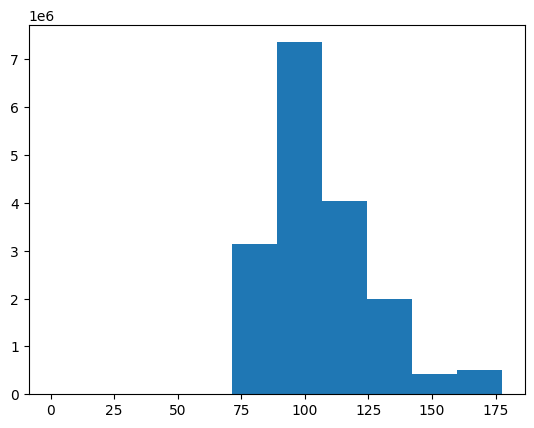

In [ ]:
### Parameter distributions
plt.hist(hillas_mrk501.tel_az)

In [21]:
hillas_mrk501.columns

Index(['por', 'event_numb', 'time', 'unix_time_ns', 'delta_time', 'error_deg',
       'tel_az', 'tel_el', 'source_az', 'source_el', 'CR400phe', 'CR_portion',
       'median_background', 'MAD_background', 'numb_pix', 'num_islands',
       'size', 'Xc', 'Yc', 'con_selected_island', 'con2', 'length', 'width',
       'dist0', 'dist1', 'dist2', 'a_axis', 'skewness_w', 'skewness_l',
       'kurtosis_w', 'kurtosis_l', 'alpha0', 'alpha1', 'alpha2', 'tel_ra',
       'tel_dec', 'source_ra', 'source_dec', 'source_x', 'source_y',
       'tracking', 'good', 'star', 'edge', 'weather_mark', 'alpha_c'],
      dtype='str')

(array([6.235670e+05, 1.306287e+06, 1.983440e+06, 2.286327e+06,
        2.648306e+06, 2.890148e+06, 2.761897e+06, 1.993487e+06,
        9.808580e+05, 1.000000e+00]),
 array([43.898 , 47.8382, 51.7784, 55.7186, 59.6588, 63.599 , 67.5392,
        71.4794, 75.4196, 79.3598, 83.3   ]),
 <BarContainer object of 10 artists>)

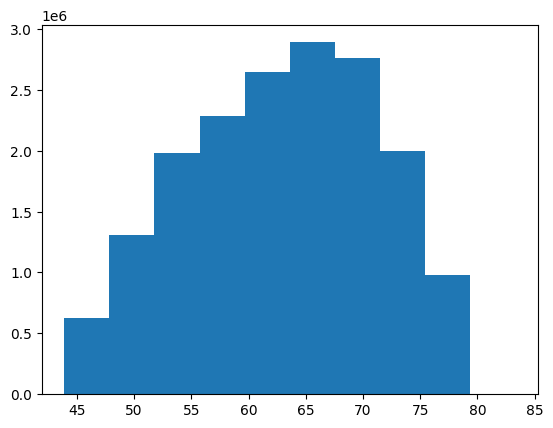

In [22]:
plt.hist(hillas_mrk501.tel_el)

(array([  762.,  2094.,  3769.,  5763.,  7732., 11566., 16167., 19383.,
        19679., 11492.]),
 array([ 0.23970549,  7.33456366, 14.42942182, 21.52427999, 28.61913816,
        35.71399633, 42.8088545 , 49.90371267, 56.99857083, 64.093429  ,
        71.18828717]),
 <BarContainer object of 10 artists>)

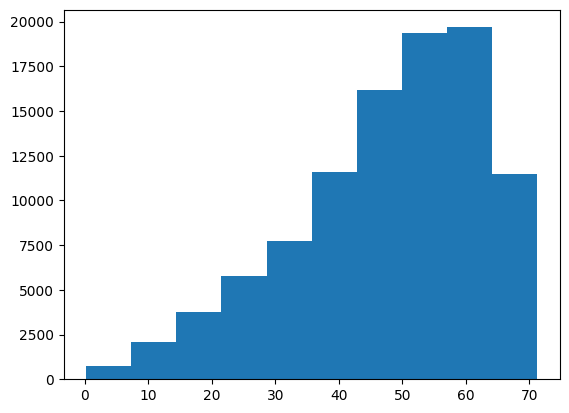

In [28]:
plt.hist(sim_hill_iact03.tel_tet * 180 / math.pi)

(array([ 9348.,  9499.,  9462.,  9812., 10434., 10690., 10989.,  9700.,
         9294.,  9179.]),
 array([ 90.00021046, 125.99926332, 161.99831618, 197.99736904,
        233.9964219 , 269.99547476, 305.99452762, 341.99358048,
        377.99263334, 413.9916862 , 449.99073906]),
 <BarContainer object of 10 artists>)

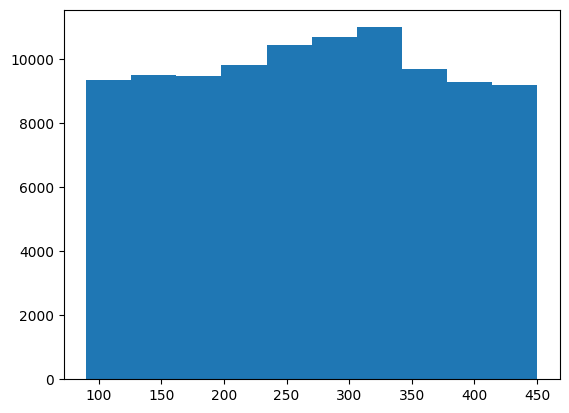

In [24]:
plt.hist(sim_hill_iact03.tel_fi * 180 / math.pi)

### Parameter distributions

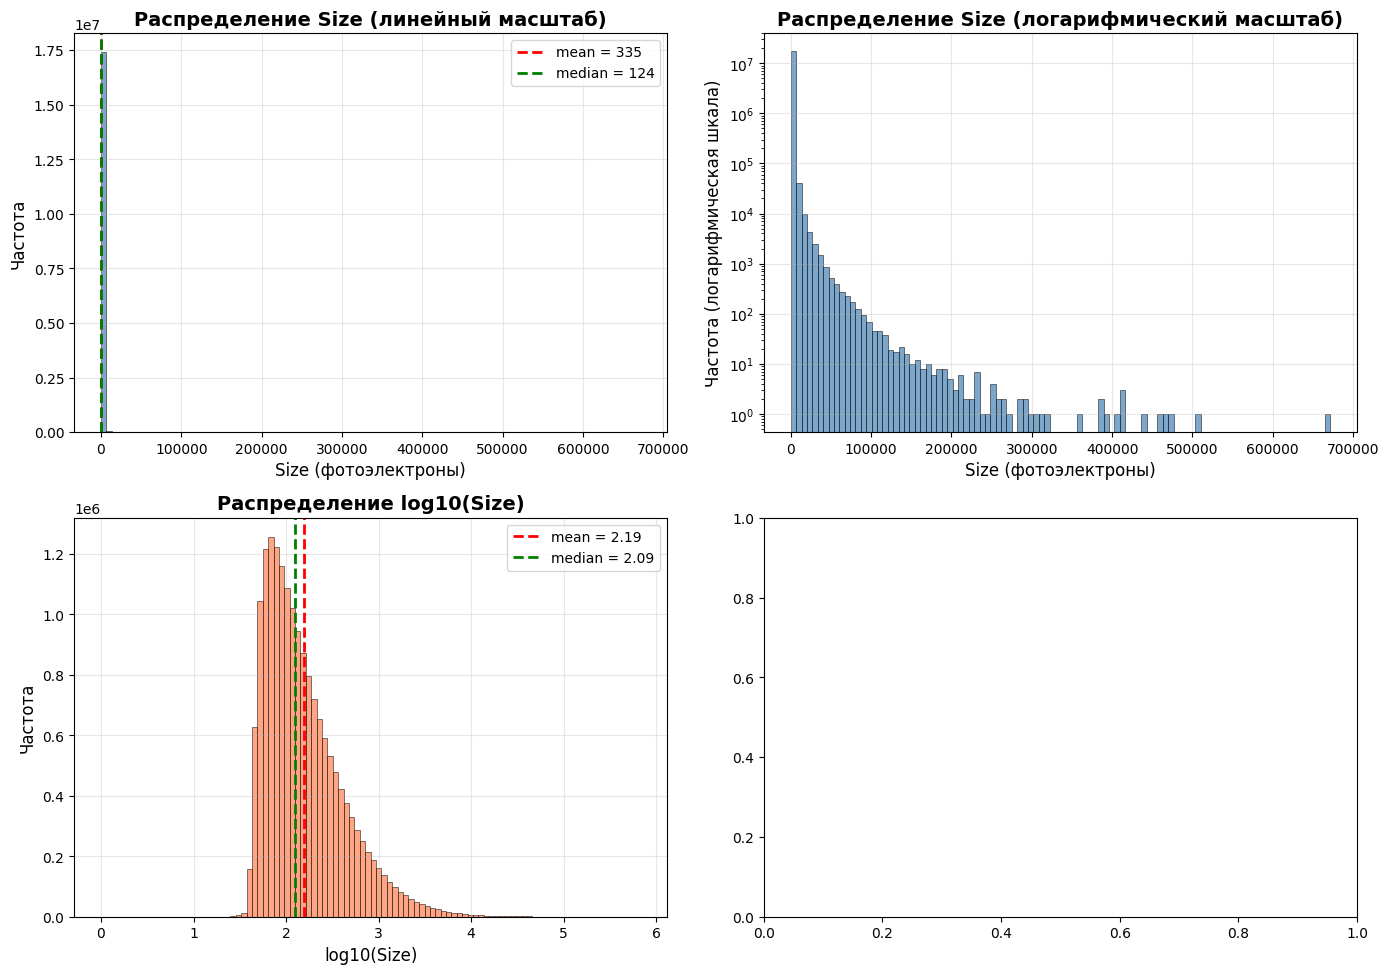

In [7]:

# Данные
f = hillas_mrk501

# Вычисляем log10(size) для всех событий
df = f.copy()  # чтобы не изменять исходные данные
df['log10_size'] = np.log10(df['size'])

# ============================================
# 1. ОТДЕЛЬНЫЕ ГРАФИКИ ДЛЯ SIZE И LOG10_SIZE
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- График 1: Size (линейный масштаб) ---
axes[0, 0].hist(df['size'], bins=100, alpha=0.7, color='steelblue', 
                edgecolor='black', linewidth=0.5)
axes[0, 0].set_xlabel('Size (фотоэлектроны)', fontsize=12)
axes[0, 0].set_ylabel('Частота', fontsize=12)
axes[0, 0].set_title('Распределение Size (линейный масштаб)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Статистика
mean_size = df['size'].mean()
median_size = df['size'].median()
std_size = df['size'].std()
axes[0, 0].axvline(mean_size, color='red', linestyle='--', linewidth=2, 
                   label=f'mean = {mean_size:.0f}')
axes[0, 0].axvline(median_size, color='green', linestyle='--', linewidth=2, 
                   label=f'median = {median_size:.0f}')
axes[0, 0].legend(fontsize=10)

# --- График 2: Size (логарифмический масштаб по Y) ---
axes[0, 1].hist(df['size'], bins=100, alpha=0.7, color='steelblue', 
                edgecolor='black', linewidth=0.5, log=True)
axes[0, 1].set_xlabel('Size (фотоэлектроны)', fontsize=12)
axes[0, 1].set_ylabel('Частота (логарифмическая шкала)', fontsize=12)
axes[0, 1].set_title('Распределение Size (логарифмический масштаб)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# --- График 3: log10(Size) ---
axes[1, 0].hist(df['log10_size'], bins=100, alpha=0.7, color='coral', 
                edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('log10(Size)', fontsize=12)
axes[1, 0].set_ylabel('Частота', fontsize=12)
axes[1, 0].set_title('Распределение log10(Size)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Статистика для log10_size
mean_log = df['log10_size'].mean()
median_log = df['log10_size'].median()
std_log = df['log10_size'].std()
axes[1, 0].axvline(mean_log, color='red', linestyle='--', linewidth=2, 
                   label=f'mean = {mean_log:.2f}')
axes[1, 0].axvline(median_log, color='green', linestyle='--', linewidth=2, 
                   label=f'median = {median_log:.2f}')
axes[1, 0].legend(fontsize=10)

plt.tight_layout()
plt.savefig('Mrk_501_researches/size_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


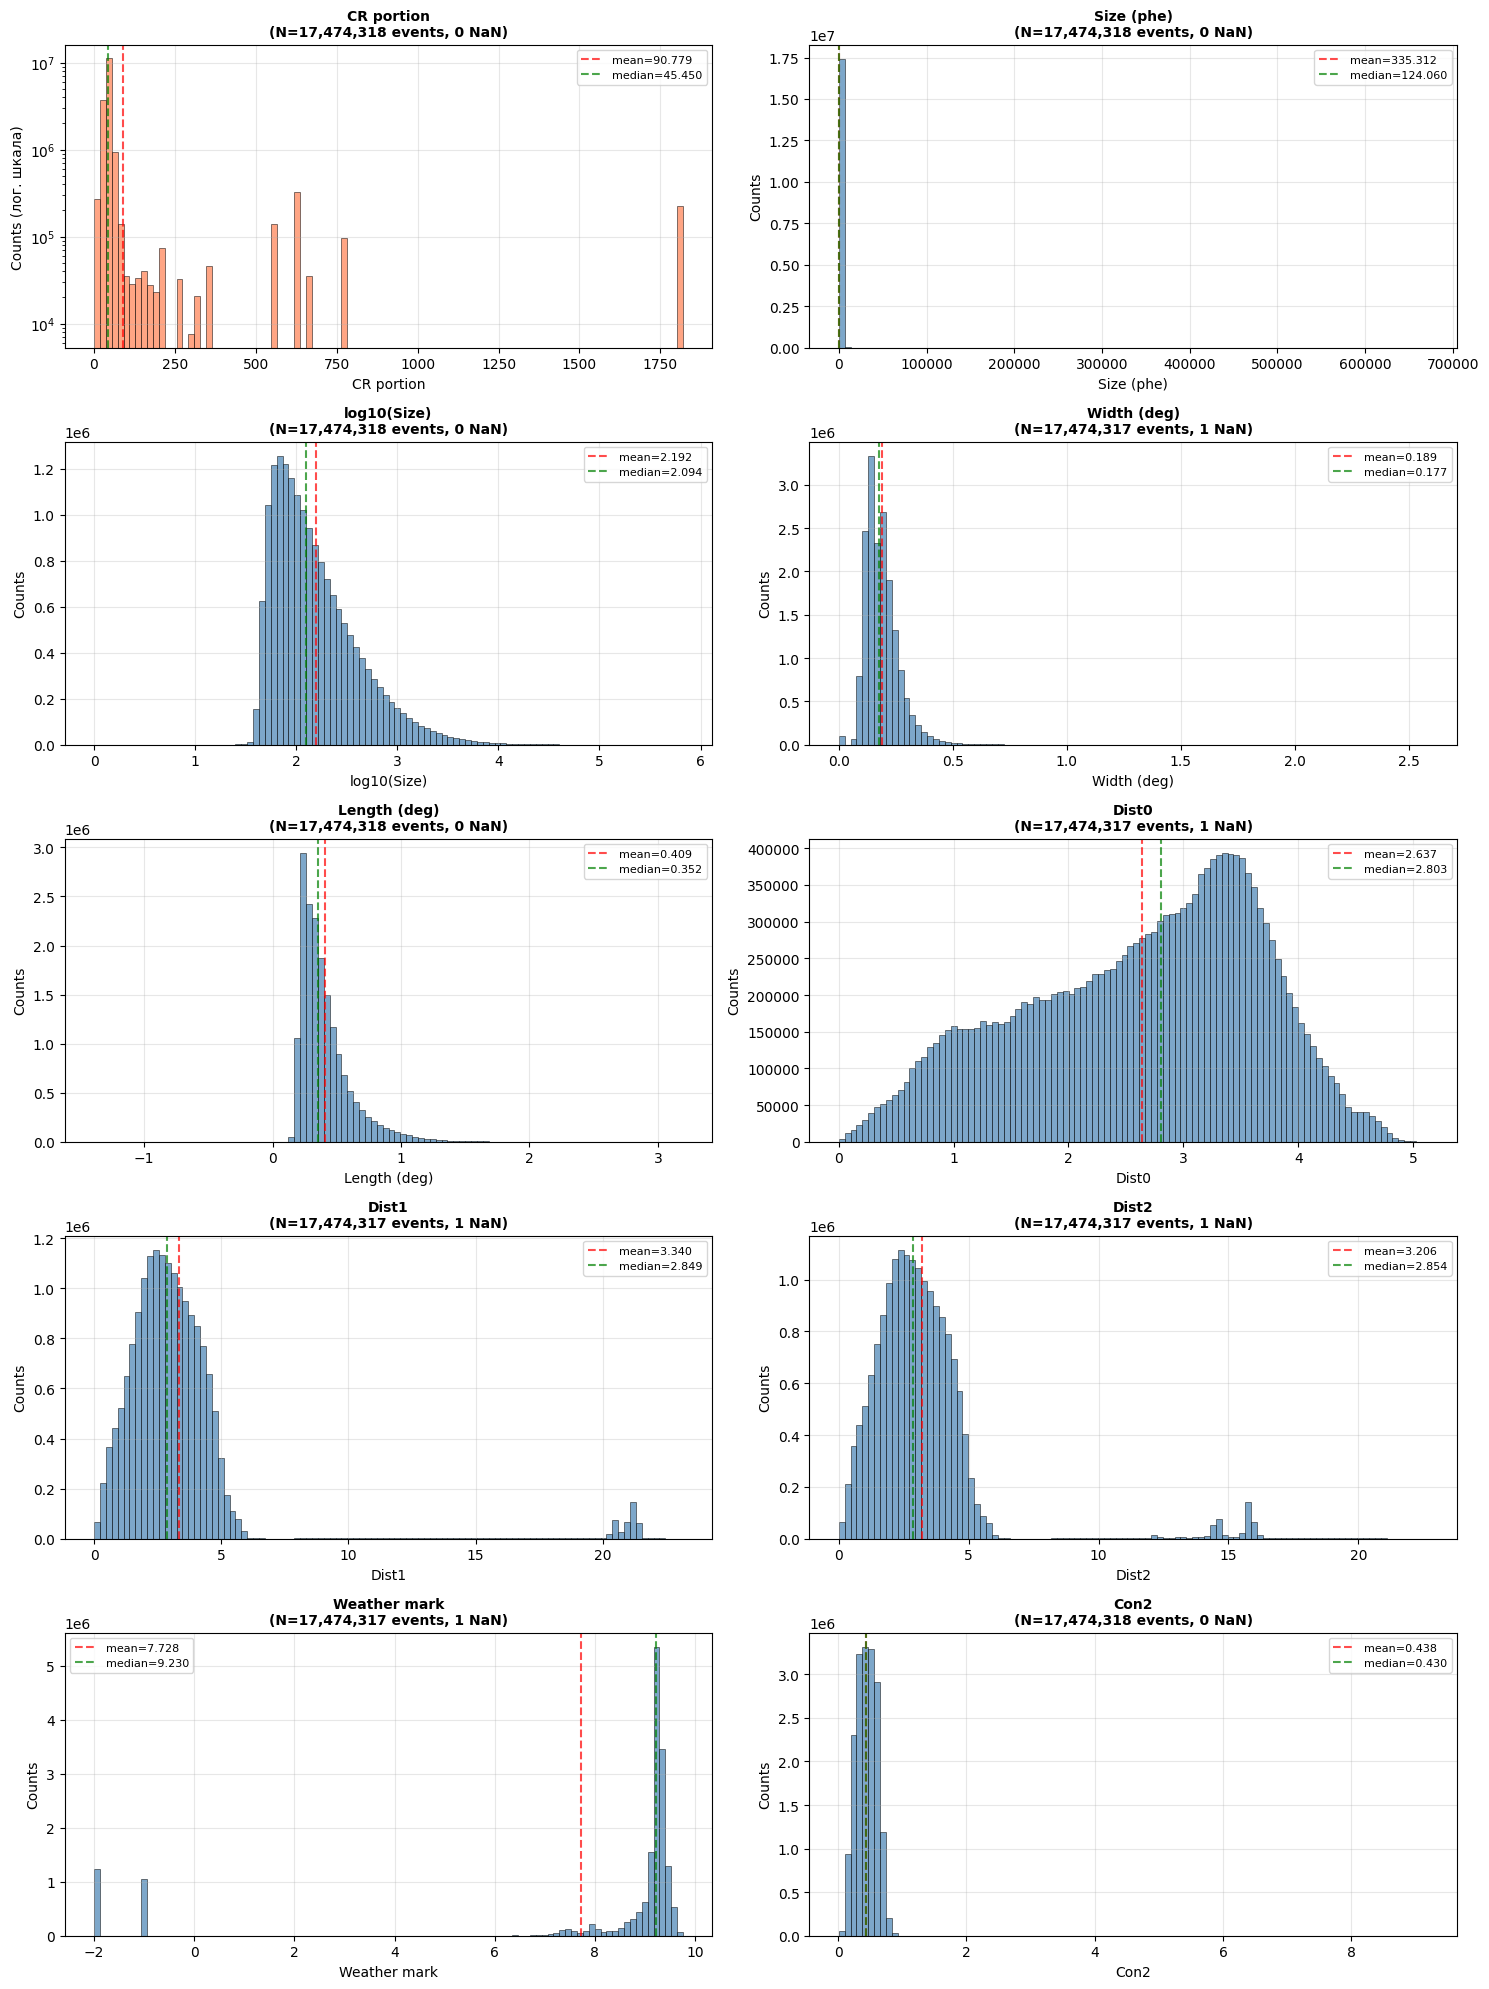

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = hillas_mrk501

# Вычисляем log10(size) для всех событий
df['log10_size'] = np.log10(df['size'])

# ============================================
# 1. Гистограммы с абсолютным количеством (Counts) по оси Y
# ============================================

# Параметры для анализа
params_to_plot = {
    'CR_portion': 'CR portion',
    'size': 'Size (phe)', 
    'log10_size': 'log10(Size)',
    'width': 'Width (deg)',
    'length': 'Length (deg)',
    'dist0': 'Dist0',
    'dist1': 'Dist1', 
    'dist2': 'Dist2',
    'weather_mark': 'Weather mark',
    'con2': 'Con2',
}

# Настройка стиля
plt.style.use('default')
fig, axes = plt.subplots((len(params_to_plot) + 1) // 2, 2, 
                          figsize=(15, 4 * ((len(params_to_plot) + 1) // 2)))
axes = axes.flatten()

for idx, (param, label) in enumerate(params_to_plot.items()):
    if param in df.columns:
        data = df[param].dropna()
        n_total = len(data)
        n_nan = len(df[param]) - n_total
        
        # Для бинарных параметров - bar plot
        if param in ['tracking', 'good', 'star', 'edge']:
            counts = data.value_counts().sort_index()
            axes[idx].bar(counts.index.astype(str), counts.values)
            axes[idx].set_xlabel(label)
            axes[idx].set_ylabel('Counts', fontsize=10)  # <- Counts вместо Frequency
        else:
            # Особый случай для CR_portion - логарифмическая шкала
            if param == 'CR_portion':
                axes[idx].hist(data, bins=100, alpha=0.7, color='coral', 
                               edgecolor='black', linewidth=0.5, log=True)
                axes[idx].set_ylabel('Counts (лог. шкала)', fontsize=10)  # <- Counts
            else:
                # Гистограмма с Counts по оси Y (не density!)
                axes[idx].hist(data, bins=100, alpha=0.7, color='steelblue', 
                               edgecolor='black', linewidth=0.5, density=False)
                axes[idx].set_ylabel('Counts', fontsize=10)  # <- Counts вместо Frequency
            
            axes[idx].set_xlabel(label, fontsize=10)
            
            # Добавляем базовую статистику
            mean_val = data.mean()
            median_val = data.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.7, 
                              linewidth=1.5, label=f'mean={mean_val:.3f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', alpha=0.7, 
                              linewidth=1.5, label=f'median={median_val:.3f}')
            axes[idx].legend(fontsize=8)
            
            # Заголовок с количеством событий
            axes[idx].set_title(f'{label}\n(N={n_total:,} events, {n_nan} NaN)', 
                                fontsize=10, fontweight='bold')
        
        axes[idx].grid(True, alpha=0.3)

# Убираем лишние subplot'ы
for idx in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('Mrk_501_researches/all_param_distributions_counts.png', dpi=300, bbox_inches='tight')
plt.show()

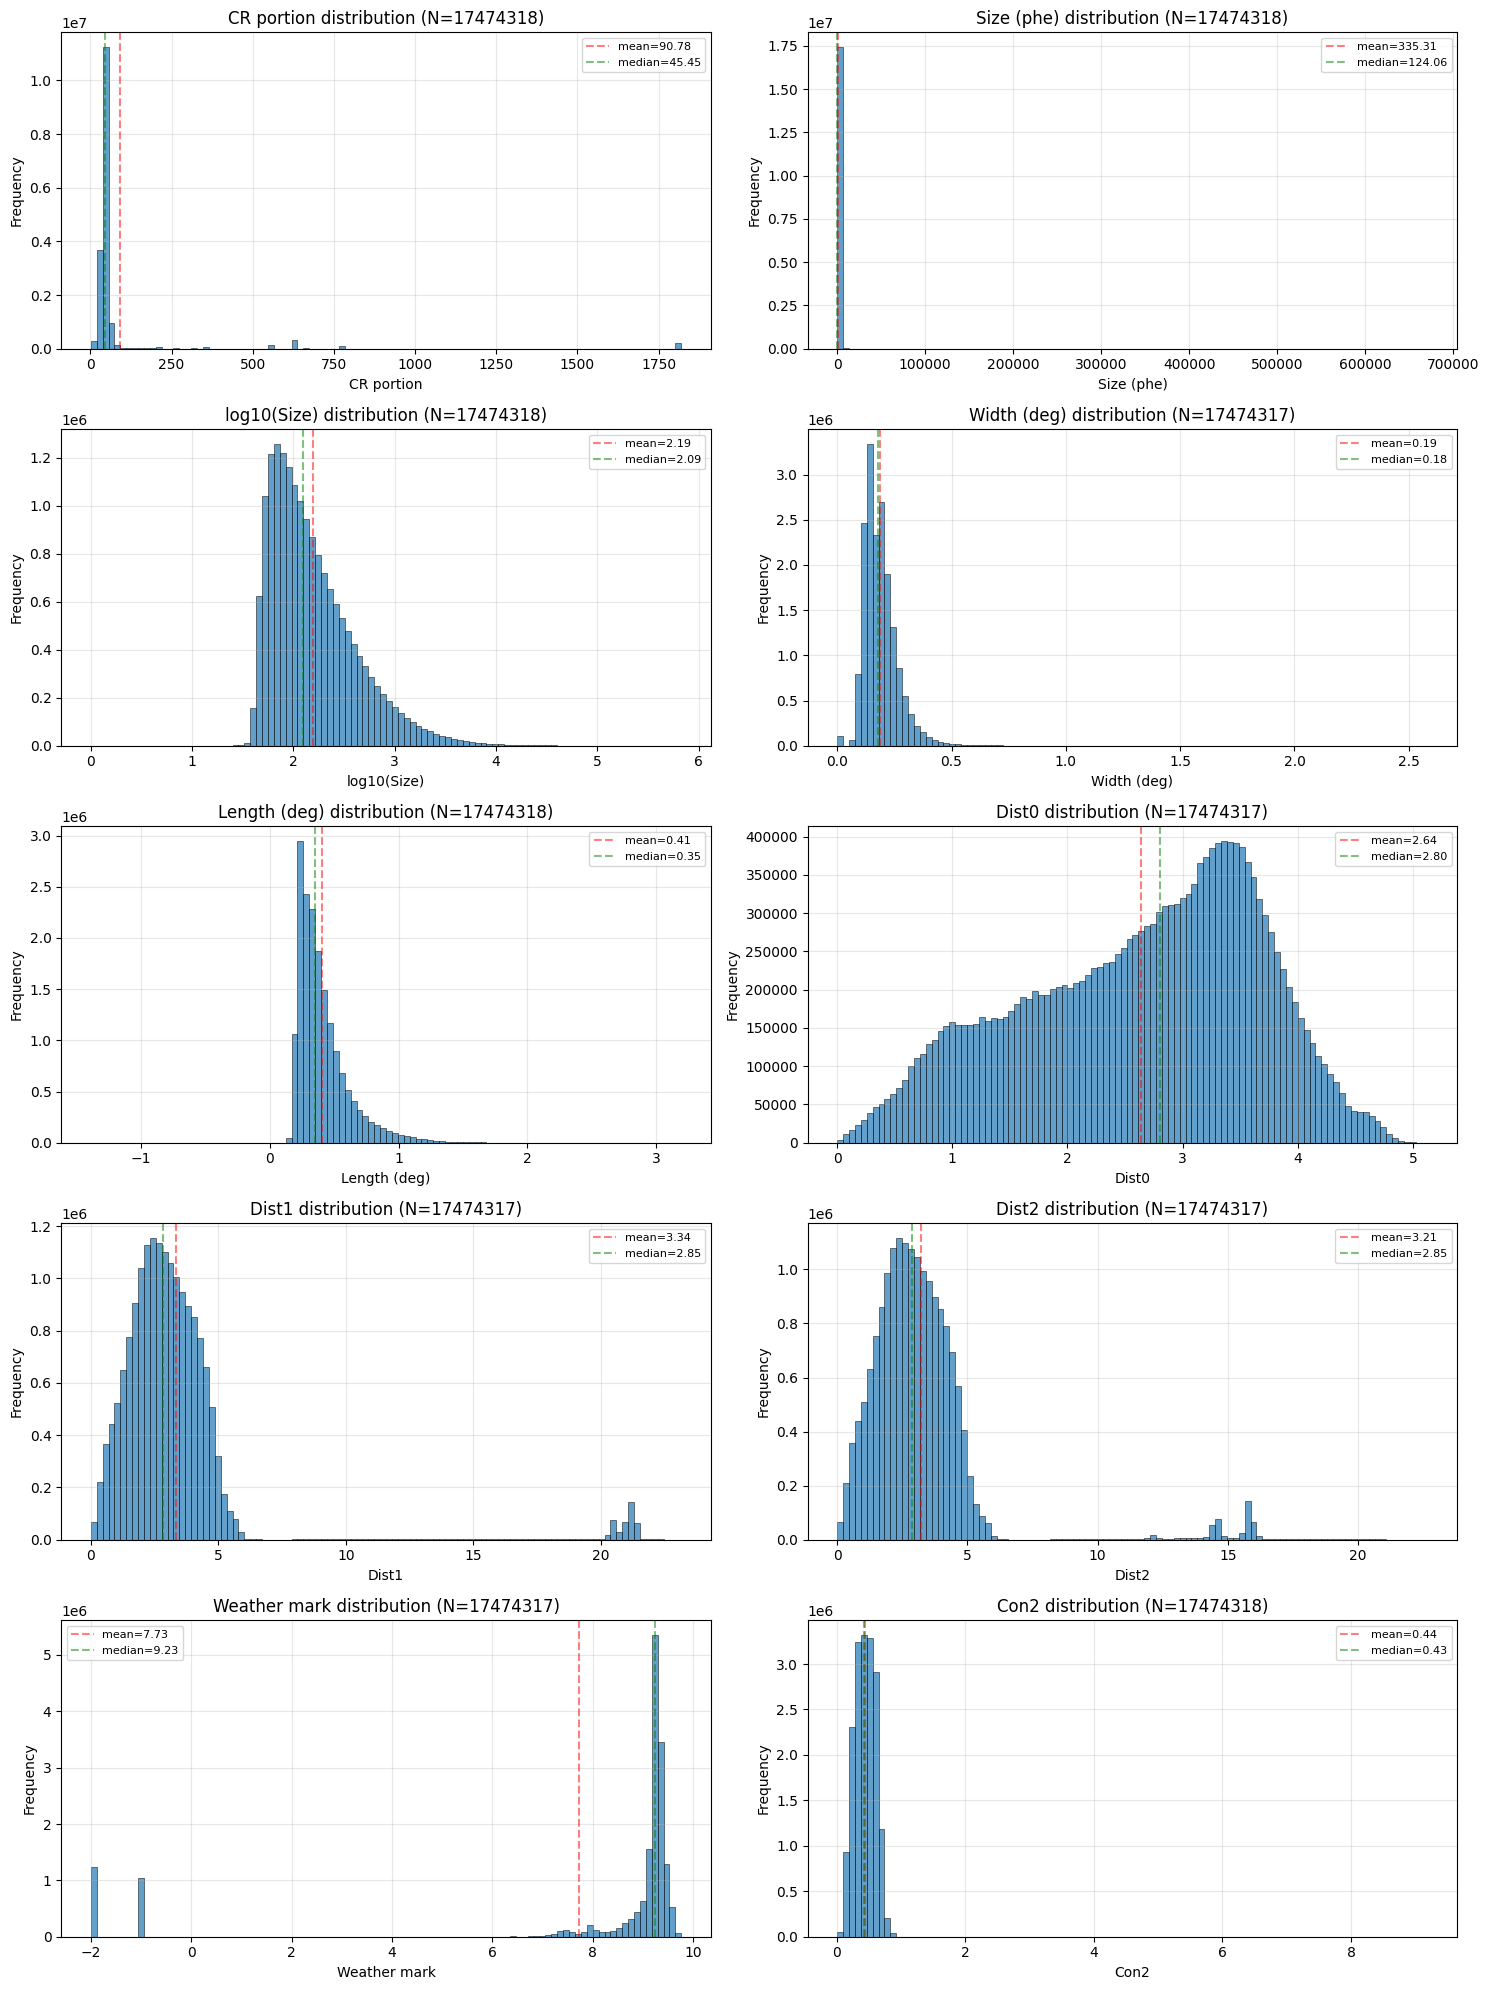

In [104]:
df = hillas_mrk501

# Вычисляем log10(size) для всех событий
df['log10_size'] = np.log10(df['size'])

# Параметры для анализа (все, что могут быть полезны для катов)
params_to_plot = {
    'CR_portion': 'CR portion',
    'size': 'Size (phe)', 
    'log10_size': 'log10(Size)',
    'width': 'Width (deg)',
    'length': 'Length (deg)',
    'dist0': 'Dist0',
    'dist1': 'Dist1', 
    'dist2': 'Dist2',
    'weather_mark': 'Weather mark',
    'con2': 'Con2',
   # 'median_background': 'Median background',
   # 'MAD_background': 'MAD background'
}

# Настройка стиля
plt.style.use('default')
fig, axes = plt.subplots((len(params_to_plot) + 1) // 2, 2, figsize=(15, 4 * ((len(params_to_plot) + 1) // 2)))
axes = axes.flatten()

for idx, (param, label) in enumerate(params_to_plot.items()):
    if param in df.columns:
        data = df[param].dropna()
        
        # Для бинарных параметров - bar plot, для непрерывных - histogram
        if param in ['tracking', 'good', 'star', 'edge']:
            counts = data.value_counts().sort_index()
            axes[idx].bar(counts.index.astype(str), counts.values)
            axes[idx].set_xlabel(label)
            axes[idx].set_ylabel('Count')
        else:
            axes[idx].hist(data, bins=100, alpha=0.7, edgecolor='black', linewidth=0.5)
            axes[idx].set_xlabel(label)
            axes[idx].set_ylabel('Frequency')
            
            # Добавляем базовую статистику
            mean_val = data.mean()
            median_val = data.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'mean={mean_val:.2f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', alpha=0.5, label=f'median={median_val:.2f}')
            axes[idx].legend(fontsize=8)
        
        axes[idx].set_title(f'{label} distribution (N={len(data)})')
        axes[idx].grid(True, alpha=0.3)

# Убираем лишние subplot'ы
for idx in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('Mrk_501_researches/all_param_distributions_exp.png', dpi=300, bbox_inches='tight')
plt.show()

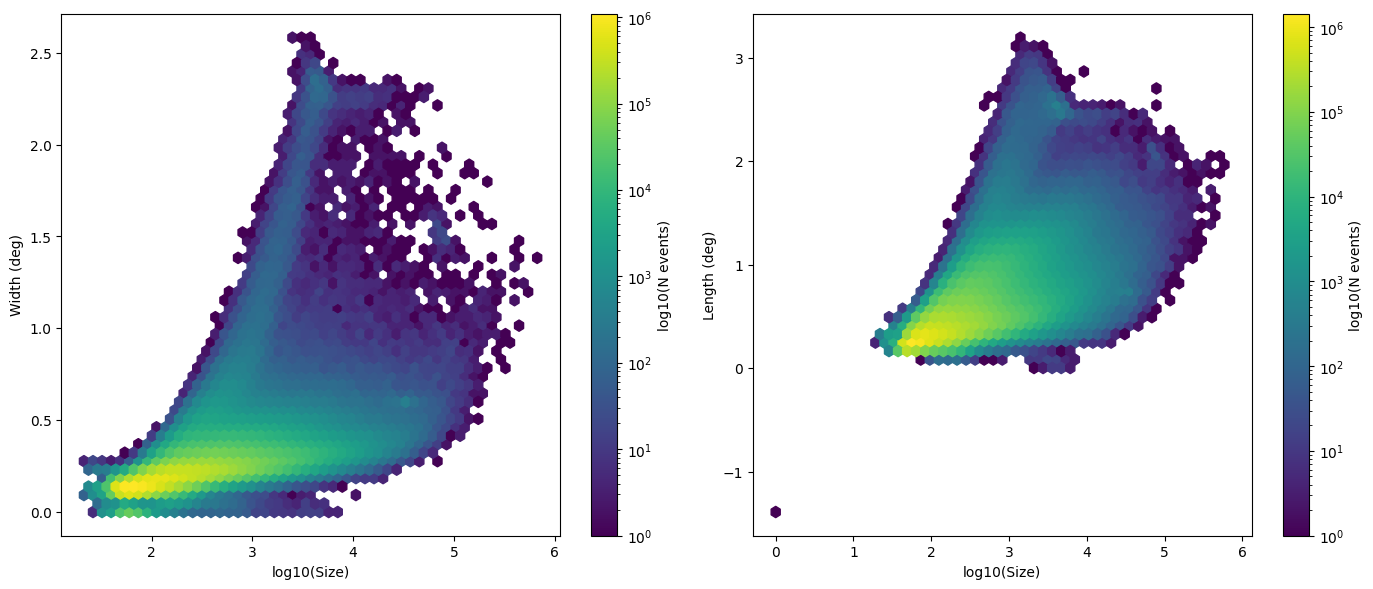

In [74]:
# 2D распределения для определения границ

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hb1 = axes[0].hexbin(df['log10_size'], df['width'], gridsize=50, bins='log', cmap='viridis')
plt.colorbar(hb1, ax=axes[0], label='log10(N events)')

hb2 = axes[1].hexbin(df['log10_size'], df['length'], gridsize=50, bins='log', cmap='viridis')
plt.colorbar(hb2, ax=axes[1], label='log10(N events)')

axes[0].set_xlabel('log10(Size)'); axes[0].set_ylabel('Width (deg)')
axes[1].set_xlabel('log10(Size)'); axes[1].set_ylabel('Length (deg)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_572294/293666643.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


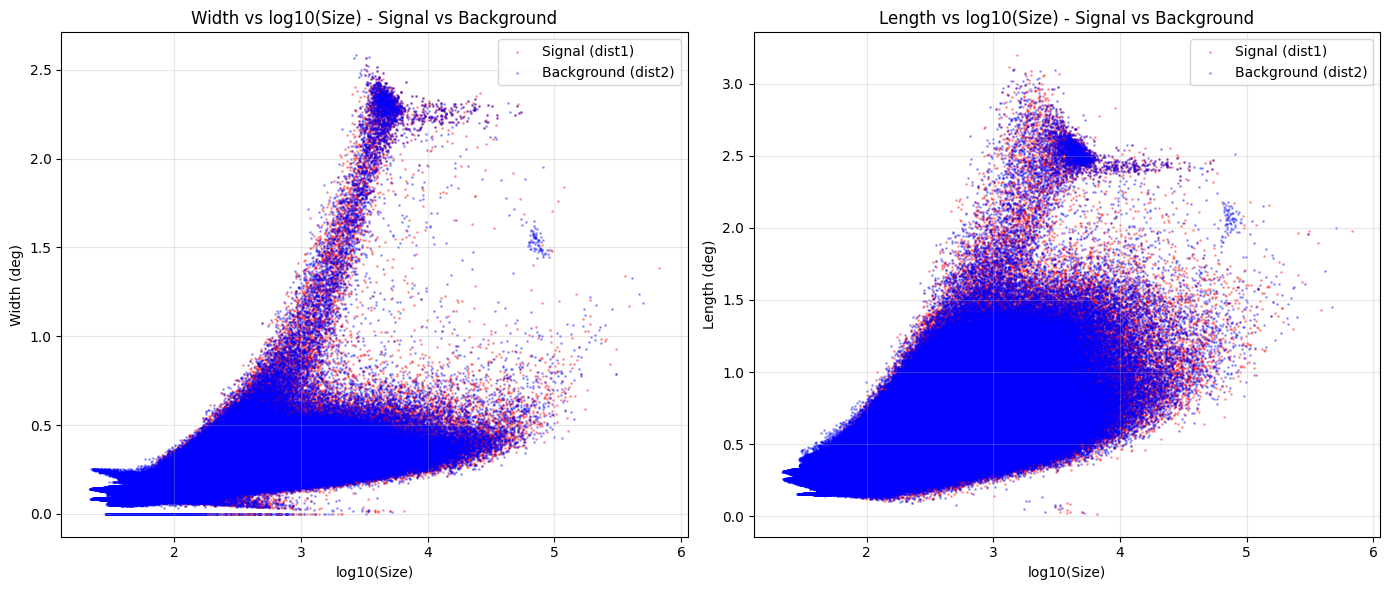

In [78]:
import matplotlib.pyplot as plt
import numpy as np

df['log10_size'] = np.log10(df['size'])
# Определяем кольцо (как в вашем коде)
dist_min = 0.3
dist_max = 1.5

# Маски для сигнала и фона в ОГРАНИЧЕННОМ промежутке
signal_mask = df['dist1'].between(dist_min, dist_max)   # сигнал+фон в кольце
background_mask = df['dist2'].between(dist_min, dist_max) 

# # Создаем маски для сигнала и фона
# signal_mask = df['dist1'].notna()
# background_mask = df['dist2'].notna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Width vs log10(size) - сигнал красным, фон синим
axes[0].scatter(df.loc[signal_mask, 'log10_size'], 
                df.loc[signal_mask, 'width'], 
                s=1, alpha=0.3, color='red', label='Signal (dist1)')

axes[0].scatter(df.loc[background_mask, 'log10_size'], 
                df.loc[background_mask, 'width'], 
                s=1, alpha=0.3, color='blue', label='Background (dist2)')

axes[0].set_xlabel('log10(Size)')
axes[0].set_ylabel('Width (deg)')
axes[0].set_title('Width vs log10(Size) - Signal vs Background')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Length vs log10(size) - сигнал красным, фон синим
axes[1].scatter(df.loc[signal_mask, 'log10_size'], 
                df.loc[signal_mask, 'length'], 
                s=1, alpha=0.3, color='red', label='Signal (dist1)')

axes[1].scatter(df.loc[background_mask, 'log10_size'], 
                df.loc[background_mask, 'length'], 
                s=1, alpha=0.3, color='blue', label='Background (dist2)')

axes[1].set_xlabel('log10(Size)')
axes[1].set_ylabel('Length (deg)')
axes[1].set_title('Length vs log10(Size) - Signal vs Background')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
# Процентили для непрерывных параметров
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
stats_df = pd.DataFrame()

for param in ['CR_portion', 'size', 'width', 'length', 'dist1', 'dist2', 'alpha0', 'alpha_c']:
    if param in df.columns:
        data = df[param].dropna()
        stats = data.describe(percentiles=[p/100 for p in percentiles if p != 50])
        stats_df[param] = stats

print("\n=== Статистика для определения катов ===\n")
print(stats_df)

# Корреляции с log10(size)
corr_params = ['width', 'length', 'dist1', 'dist2', 'alpha0', 'CR_portion']
corr_with_size = df[['log10_size'] + corr_params].corr()['log10_size'].sort_values(ascending=False)
corr_with_size


=== Статистика для определения катов ===

         CR_portion          size         width        length         dist1  \
count  1.747432e+07  1.747432e+07  1.747432e+07  1.747432e+07  1.747432e+07   
mean   9.077881e+01  3.353120e+02  1.893218e-01  4.089278e-01  3.339554e+00   
std    2.278393e+02  1.446360e+03  8.225712e-02  2.047872e-01  3.167453e+00   
min    1.270000e+00  1.000000e+00  0.000000e+00 -1.390000e+00  6.740000e-04   
1%     1.667000e+01  4.281000e+01  7.781500e-02  1.854420e-01  3.654142e-01   
5%     2.773000e+01  4.949000e+01  1.008410e-01  2.098480e-01  8.142910e-01   
10%    3.122000e+01  5.535000e+01  1.150990e-01  2.271800e-01  1.208648e+00   
25%    3.856000e+01  7.362000e+01  1.365930e-01  2.661200e-01  1.949871e+00   
75%    5.190000e+01  2.626400e+02  2.234830e-01  4.816928e-01  3.857724e+00   
90%    5.844000e+01  6.016100e+02  2.790600e-01  6.657980e-01  4.647341e+00   
95%    3.163300e+02  1.052840e+03  3.226700e-01  8.183560e-01  5.186403e+00   
99%    1.

log10_size    1.000000
width         0.686887
length        0.682191
alpha0        0.016270
dist2         0.011903
dist1        -0.002335
CR_portion   -0.093727
Name: log10_size, dtype: float64

### Cчитываем моделирование для 3 телескопа

In [85]:
file_simulation = '/home/aivanova/mrk501_data/taiga61_hillas_iact03_14.0_7.0fix_cb0.csv'
sim_hill_iact03 = pd.read_csv(file_simulation)

In [12]:
sim_hill_iact03.columns

Index(['clean_number', 'event_number', 'axis_scatter', 'numb_pix', 'energy',
       'no_cleaning_size', 'size', 'Xc', 'Yc', 'con2', 'dist2max', 'length',
       'width', 'dist0', 'dist1', 'dist2', 'azwidth', 'miss', 'alpha0',
       'alpha1', 'alpha2', 'psi_axis', 'psi_axis_uncert',
       'transverse_cog_uncert', 'x_max_coord', 'y_max_coord', 'skewness_l',
       'kurtosis_l', 'skewness_w', 'kurtosis_w', 'mean_max_cluster_amp',
       'std_max_cluster_amp', 'edge', 'source_x', 'source_y', 'x_ground',
       'y_ground', 'tel_tet', 'tel_fi', 'source_tet', 'source_fi', 'Xmax',
       'num_islands', 'con_selected_island'],
      dtype='str')

In [ ]:
print(sim_hill_iact03.tel_tet* 180 / math.pi)

0        16.806915
1        16.806915
2        23.333993
3        23.333993
4        23.333993
           ...    
98402    61.672604
98403    61.672604
98404    61.672604
98405    61.672604
98406    23.424978
Name: tel_tet, Length: 98407, dtype: float64


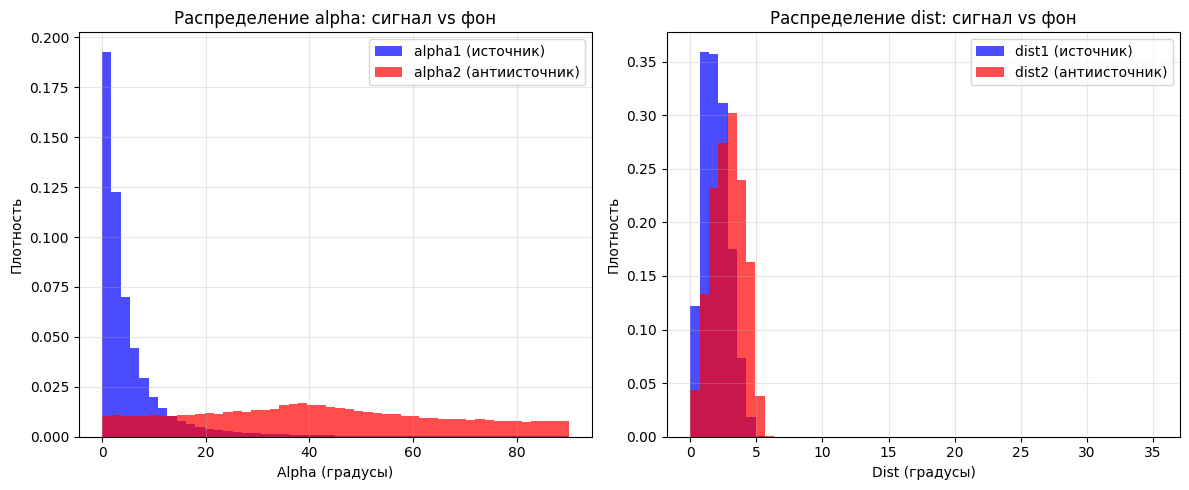

In [87]:

# Загрузка данных
df = sim_hill_iact03  # ваш датафрейм

# Параметры для анализа
signal_params = ['alpha1', 'dist1']      # относительно источника
bg_params = ['alpha2', 'dist2']          # относительно антиисточника

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Сравнение распределений alpha
axes[0].hist(df['alpha1'], bins=50, density=True, alpha=0.7, 
             label='alpha1 (источник)', color='blue')
axes[0].hist(df['alpha2'], bins=50, density=True, alpha=0.7, 
             label='alpha2 (антиисточник)', color='red')
axes[0].set_xlabel('Alpha (градусы)')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение alpha: сигнал vs фон')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Сравнение распределений dist
axes[1].hist(df['dist1'], bins=50, density=True, alpha=0.7, 
             label='dist1 (источник)', color='blue')
axes[1].hist(df['dist2'], bins=50, density=True, alpha=0.7, 
             label='dist2 (антиисточник)', color='red')
axes[1].set_xlabel('Dist (градусы)')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение dist: сигнал vs фон')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.savefig('Mrk_501_researches/alpha_sim_distributions.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [26]:
def find_optimal_dist_cut(df, dist_col='dist1', bg_col='dist2', n_bins=50):
    """
    Находит оптимальный кат по dist1, максимизирующий отношение сигнал/фон
    """
    # Создаем бины
    max_val = max(df[dist_col].max(), df[bg_col].max())
    bin_edges = np.linspace(0, max_val, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Гистограммы
    hist_signal, _ = np.histogram(df[dist_col], bins=bin_edges)
    hist_bg, _ = np.histogram(df[bg_col], bins=bin_edges)
    
    # Кумулятивные суммы (события с dist < cut)
    cum_signal = np.cumsum(hist_signal)
    cum_bg = np.cumsum(hist_bg)
    
    # Отношение сигнал/фон и Significance (Li & Ma)
    ratio = cum_signal / (cum_bg + 1e-10)
    significance = cum_signal / np.sqrt(cum_signal + cum_bg + 1e-10)
    
    # Поиск оптимальной точки
    optimal_ratio_idx = np.argmax(ratio)
    optimal_sig_idx = np.argmax(significance)
    
    cut_ratio = bin_edges[optimal_ratio_idx]
    cut_sig = bin_edges[optimal_sig_idx]
    
    # Качество (чистота) выборки
    purity = cum_signal / (cum_signal + cum_bg + 1e-10)
    
    results = {
        'bin_edges': bin_edges,
        'bin_centers': bin_centers,
        'cum_signal': cum_signal,
        'cum_bg': cum_bg,
        'ratio': ratio,
        'significance': significance,
        'purity': purity,
        'optimal_cut_by_ratio': cut_ratio,
        'optimal_cut_by_significance': cut_sig,
        'max_ratio': ratio[optimal_ratio_idx],
        'max_significance': significance[optimal_sig_idx],
        'n_events_total': len(df),
        'n_signal_after_ratio_cut': cum_signal[optimal_ratio_idx],
        'n_bg_after_ratio_cut': cum_bg[optimal_ratio_idx],
    }
    
    return results

# Запускаем поиск
results = find_optimal_dist_cut(sim_hill_iact03)

print("="*70)
print("РЕЗУЛЬТАТЫ ПОИСКА ОПТИМАЛЬНОГО КАТА ПО dist1")
print("="*70)
print(f"\nОптимальный кат по максимуму отношения сигнал/фон:")
print(f"  dist1 < {results['optimal_cut_by_ratio']:.3f}°")
print(f"  Отношение сигнал/фон: {results['max_ratio']:.2f}")
print(f"  Чистота (Purity): {results['purity'][np.argmax(results['ratio'])]:.1%}")
print(f"  Сохраняется событий: {results['n_signal_after_ratio_cut']:.0f} сигнала, {results['n_bg_after_ratio_cut']:.0f} фона")

print(f"\nОптимальный кат по максимуму значимости (Li&Ma):")
print(f"  dist1 < {results['optimal_cut_by_significance']:.3f}°")
print(f"  Signifiance: {results['max_significance']:.1f} sigma")

РЕЗУЛЬТАТЫ ПОИСКА ОПТИМАЛЬНОГО КАТА ПО dist1

Оптимальный кат по максимуму отношения сигнал/фон:
  dist1 < 0.000°
  Отношение сигнал/фон: 2.83
  Чистота (Purity): 73.9%
  Сохраняется событий: 8163 сигнала, 2881 фона

Оптимальный кат по максимуму значимости (Li&Ma):
  dist1 < 2.822°
  Signifiance: 229.7 sigma


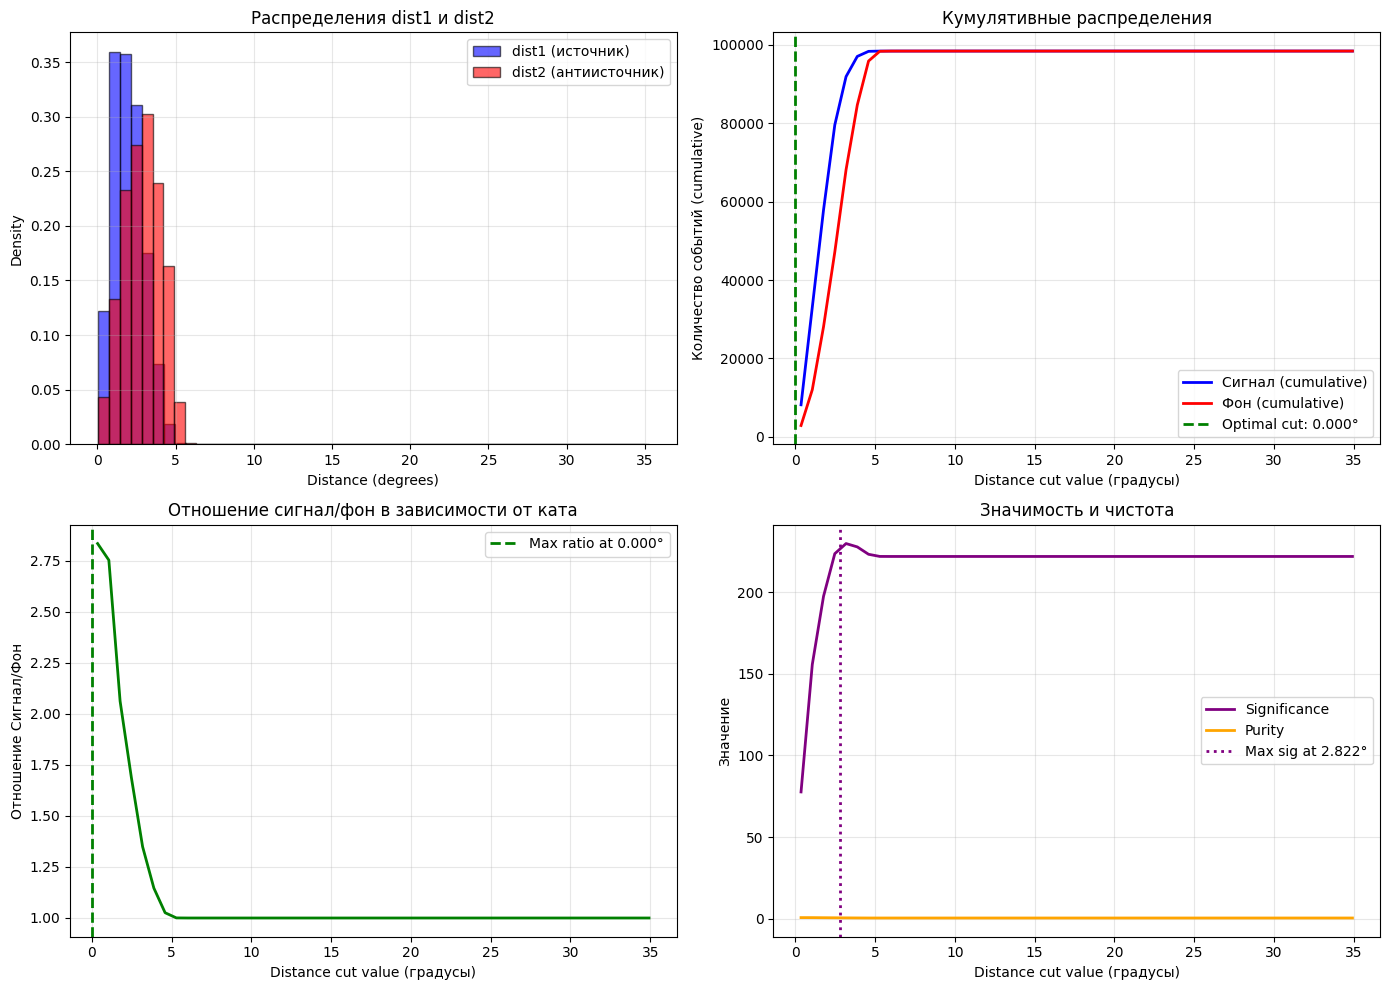

In [27]:
def plot_dist_cut_optimization(df, results):
    """Визуализация для выбора оптимального ката"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    bin_edges = results['bin_edges']
    bin_centers = results['bin_centers']
    
    # График 1: Распределения dist1 и dist2
    axes[0,0].hist(df['dist1'], bins=50, density=True, alpha=0.6, 
                   label='dist1 (источник)', color='blue', edgecolor='black')
    axes[0,0].hist(df['dist2'], bins=50, density=True, alpha=0.6, 
                   label='dist2 (антиисточник)', color='red', edgecolor='black')
    axes[0,0].set_xlabel('Distance (degrees)')
    axes[0,0].set_ylabel('Density')
    axes[0,0].set_title('Распределения dist1 и dist2')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # График 2: Кумулятивные суммы
    axes[0,1].plot(bin_centers, results['cum_signal'], 'b-', linewidth=2, label='Сигнал (cumulative)')
    axes[0,1].plot(bin_centers, results['cum_bg'], 'r-', linewidth=2, label='Фон (cumulative)')
    axes[0,1].axvline(results['optimal_cut_by_ratio'], color='green', linestyle='--', 
                      linewidth=2, label=f"Optimal cut: {results['optimal_cut_by_ratio']:.3f}°")
    axes[0,1].set_xlabel('Distance cut value (градусы)')
    axes[0,1].set_ylabel('Количество событий (cumulative)')
    axes[0,1].set_title('Кумулятивные распределения')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # График 3: Отношение сигнал/фон
    axes[1,0].plot(bin_centers, results['ratio'], 'g-', linewidth=2)
    axes[1,0].axvline(results['optimal_cut_by_ratio'], color='green', linestyle='--', 
                      linewidth=2, label=f"Max ratio at {results['optimal_cut_by_ratio']:.3f}°")
    axes[1,0].set_xlabel('Distance cut value (градусы)')
    axes[1,0].set_ylabel('Отношение Сигнал/Фон')
    axes[1,0].set_title('Отношение сигнал/фон в зависимости от ката')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # График 4: Значимость и чистота
    axes[1,1].plot(bin_centers, results['significance'], 'purple', linewidth=2, label='Significance')
    axes[1,1].plot(bin_centers, results['purity'], 'orange', linewidth=2, label='Purity')
    axes[1,1].axvline(results['optimal_cut_by_significance'], color='purple', linestyle=':', 
                      linewidth=2, label=f"Max sig at {results['optimal_cut_by_significance']:.3f}°")
    axes[1,1].set_xlabel('Distance cut value (градусы)')
    axes[1,1].set_ylabel('Значение')
    axes[1,1].set_title('Значимость и чистота')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Визуализация
plot_dist_cut_optimization(sim_hill_iact03, results)

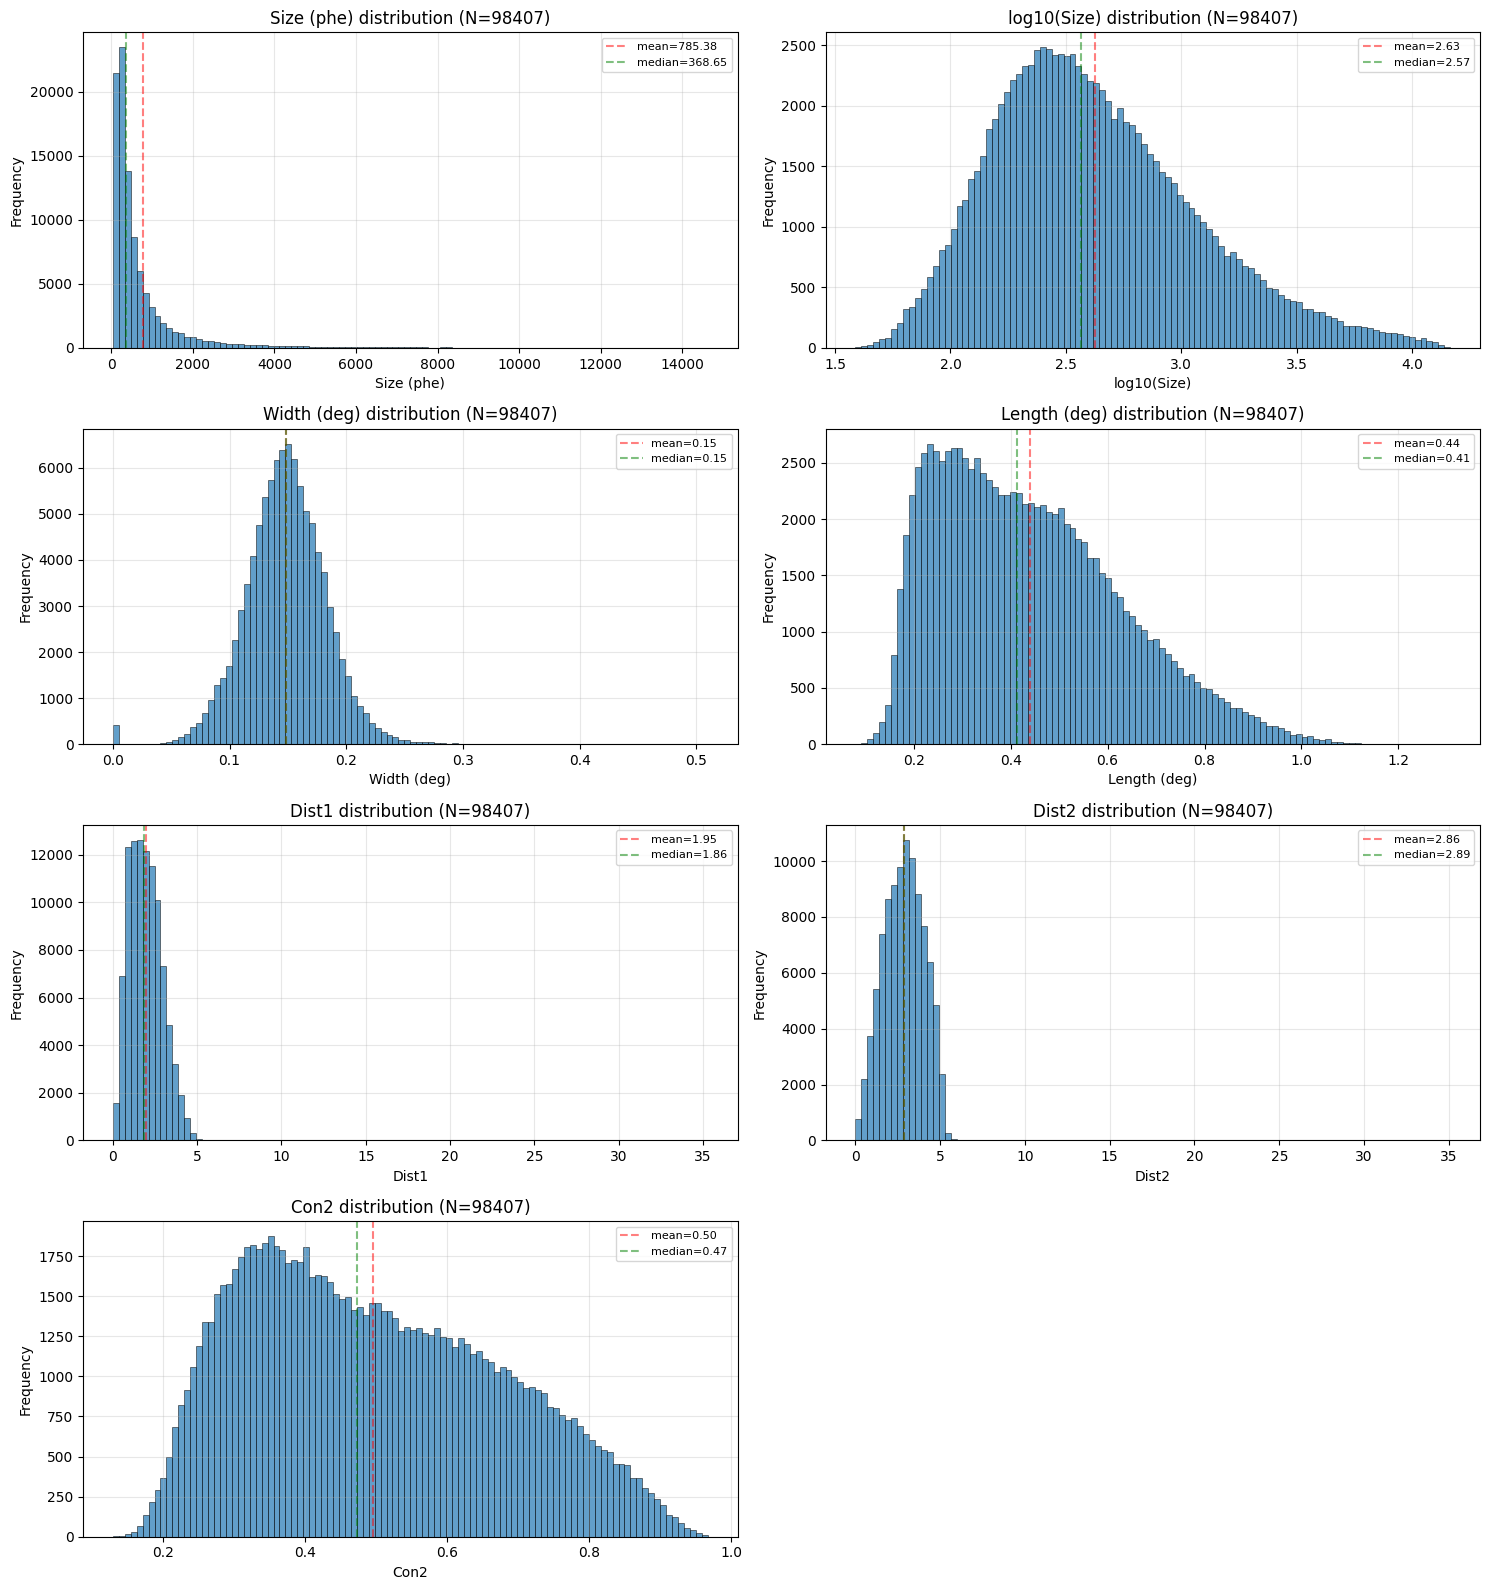

In [24]:
df = sim_hill_iact03

# Вычисляем log10(size) для всех событий
df['log10_size'] = np.log10(df['size'])

# Параметры для анализа (все, что могут быть полезны для катов)
params_to_plot = {
    'size': 'Size (phe)', 
    'log10_size': 'log10(Size)',
    'width': 'Width (deg)',
    'length': 'Length (deg)',
    'dist1': 'Dist1', 
    'dist2': 'Dist2',
    'con2': 'Con2',
}

# Настройка стиля
plt.style.use('default')
fig, axes = plt.subplots((len(params_to_plot) + 1) // 2, 2, figsize=(15, 4 * ((len(params_to_plot) + 1) // 2)))
axes = axes.flatten()

for idx, (param, label) in enumerate(params_to_plot.items()):
    if param in df.columns:
        data = df[param].dropna()
        
        # Для бинарных параметров - bar plot, для непрерывных - histogram
        if param in ['tracking', 'good', 'star', 'edge']:
            counts = data.value_counts().sort_index()
            axes[idx].bar(counts.index.astype(str), counts.values)
            axes[idx].set_xlabel(label)
            axes[idx].set_ylabel('Count')
        else:
            axes[idx].hist(data, bins=100, alpha=0.7, edgecolor='black', linewidth=0.5)
            axes[idx].set_xlabel(label)
            axes[idx].set_ylabel('Frequency')
            
            # Добавляем базовую статистику
            mean_val = data.mean()
            median_val = data.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.5, label=f'mean={mean_val:.2f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', alpha=0.5, label=f'median={median_val:.2f}')
            axes[idx].legend(fontsize=8)
        
        axes[idx].set_title(f'{label} distribution (N={len(data)})')
        axes[idx].grid(True, alpha=0.3)

# Убираем лишние subplot'ы
for idx in range(len(params_to_plot), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('Mrk_501_researches/all_param_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
sim_hill_iact03

,clean_number,event_number,axis_scatter,numb_pix,energy,no_cleaning_size,size,Xc,Yc,con2,...,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island,log10_size


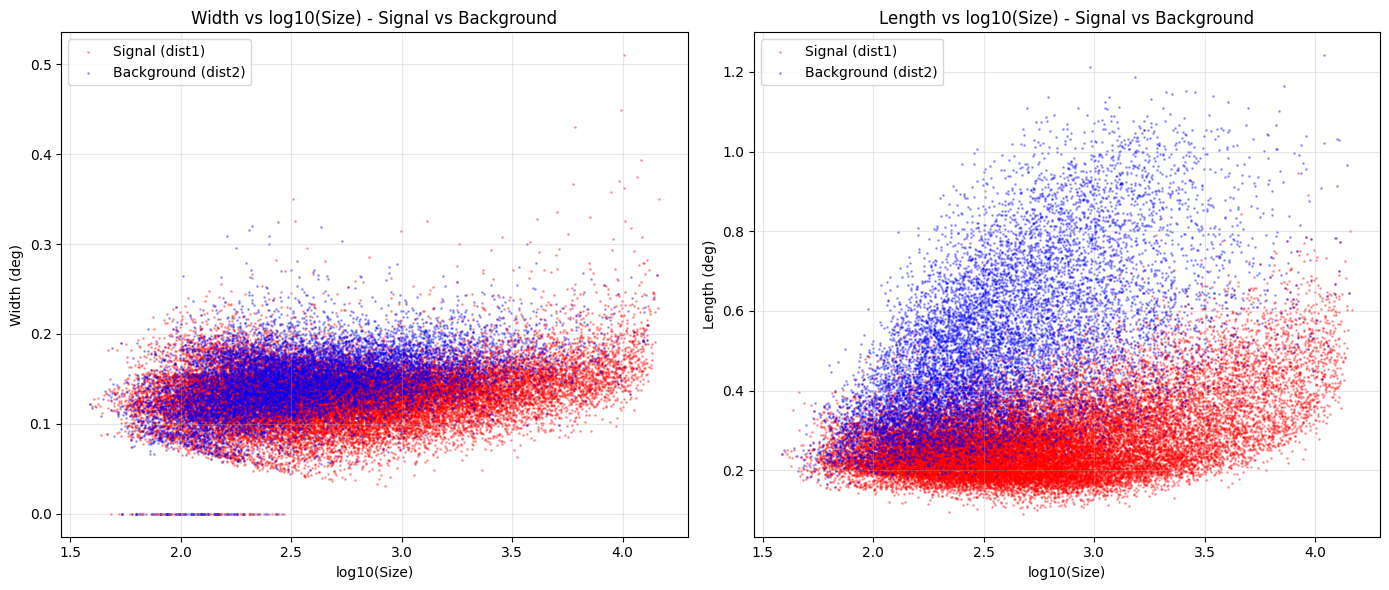

In [88]:
sim_hill_iact03['log10_size'] = np.log10(sim_hill_iact03['size'])

dist_min = 0.3
dist_max = 1.4

#sim_hill_iact03 = sim_hill_iact03[sim_hill_iact03['tel_tet']*180/math.pi >= 45] # po theta cut

# Маски для сигнала и фона в ОГРАНИЧЕННОМ промежутке
signal_mask = sim_hill_iact03['dist1'].between(dist_min, dist_max)   # сигнал+фон в кольце
background_mask = sim_hill_iact03['dist2'].between(dist_min, dist_max) 

# # Создаем маски для сигнала и фона
# signal_mask = sim_hill_iact03['dist1'].notna()
# background_mask = sim_hill_iact03['dist2'].notna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Width vs log10(size) - сигнал красным, фон синим
axes[0].scatter(sim_hill_iact03.loc[signal_mask, 'log10_size'], 
                sim_hill_iact03.loc[signal_mask, 'width'], 
                s=1, alpha=0.3, color='red', label='Signal (dist1)')

axes[0].scatter(sim_hill_iact03.loc[background_mask, 'log10_size'], 
                sim_hill_iact03.loc[background_mask, 'width'], 
                s=1, alpha=0.3, color='blue', label='Background (dist2)')

axes[0].set_xlabel('log10(Size)')
axes[0].set_ylabel('Width (deg)')
axes[0].set_title('Width vs log10(Size) - Signal vs Background')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Length vs log10(size) - сигнал красным, фон синим
axes[1].scatter(sim_hill_iact03.loc[signal_mask, 'log10_size'], 
                sim_hill_iact03.loc[signal_mask, 'length'], 
                s=1, alpha=0.3, color='red', label='Signal (dist1)')

axes[1].scatter(sim_hill_iact03.loc[background_mask, 'log10_size'], 
                sim_hill_iact03.loc[background_mask, 'length'], 
                s=1, alpha=0.3, color='blue', label='Background (dist2)')

axes[1].set_xlabel('log10(Size)')
axes[1].set_ylabel('Length (deg)')
axes[1].set_title('Length vs log10(Size) - Signal vs Background')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
### Поиск катов на ширину и длину

In [89]:
from sklearn.linear_model import RANSACRegressor, LinearRegression
from scipy.optimize import minimize

sim_hill_iact03['log10_size'] = np.log10(sim_hill_iact03['size'])

dist_min = 0.3
dist_max = 1.4

signal_mask = sim_hill_iact03['dist1'].between(dist_min, dist_max)
background_mask = sim_hill_iact03['dist2'].between(dist_min, dist_max)

# Извлекаем данные сигнала (красные точки)
signal_data = sim_hill_iact03[signal_mask].copy()
bg_data = sim_hill_iact03[background_mask].copy()

print(f"Сигнальных событий: {len(signal_data)}")
print(f"Фоновых событий: {len(bg_data)}")

Сигнальных событий: 31630
Фоновых событий: 11270


In [90]:
# ============================================
# 2. Поиск верхней границы для width
# ============================================

def find_upper_boundary(df, x_col, y_col, quantile=0.90, n_bins=20):
    """
    Находит верхнюю границу облака сигнала (квантиль по y в бинах x)
    """
    # Создаем бины по x
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)
    bin_centers = []
    upper_bound = []
    
    for i in range(n_bins):
        mask = (df[x_col] >= x_bins[i]) & (df[x_col] < x_bins[i+1])
        if mask.sum() > 10:
            bin_centers.append((x_bins[i] + x_bins[i+1]) / 2)
            upper_bound.append(df.loc[mask, y_col].quantile(quantile))
    
    return np.array(bin_centers), np.array(upper_bound)

# Для width
bin_centers_w, upper_w = find_upper_boundary(signal_data, 'log10_size', 'width', quantile=0.70)

# Линейная аппроксимация (RANSAC устойчив к выбросам)
ransac_w = RANSACRegressor(LinearRegression(), min_samples=0.5, residual_threshold=0.01)
ransac_w.fit(bin_centers_w.reshape(-1, 1), upper_w)

# Коэффициенты: width_max = a * log10(size) + b
a_w = ransac_w.estimator_.coef_[0]
b_w = ransac_w.estimator_.intercept_

print(f"\n=== Верхняя граница WIDTH ===")
print(f"width_max = {a_w:.4f} * log10(size) + {b_w:.4f}")
print(f"Или в вашем формате: (df['width'] < {a_w:.4f} * np.log10(df['size']) + {b_w:.4f})")

# ============================================
# 3. Поиск нижней границы для width (обычно константа)
# ============================================

# Нижняя граница width - минимальное значение сигнала
min_width_overall = signal_data['width'].min()
min_width_by_bin, lower_w = find_upper_boundary(signal_data, 'log10_size', 'width', quantile=0.10)

# Обычно нижняя граница - константа (аппаратурное ограничение)
width_min_const = signal_data['width'].quantile(0.05)  # 5% квантиль

print(f"\n=== Нижняя граница WIDTH ===")
print(f"width_min = {width_min_const:.4f} (константа)")
print(f"Или в формате: (df['width'] > {width_min_const:.4f})")


=== Верхняя граница WIDTH ===
width_max = 0.0121 * log10(size) + 0.1137
Или в вашем формате: (df['width'] < 0.0121 * np.log10(df['size']) + 0.1137)

=== Нижняя граница WIDTH ===
width_min = 0.0838 (константа)
Или в формате: (df['width'] > 0.0838)


In [91]:
# ============================================
# 4. Поиск верхней границы для length
# ============================================

bin_centers_l, upper_l = find_upper_boundary(signal_data, 'log10_size', 'length', quantile=0.80)

ransac_l = RANSACRegressor(LinearRegression(), min_samples=0.5, residual_threshold=0.015)
ransac_l.fit(bin_centers_l.reshape(-1, 1), upper_l)

a_l = ransac_l.estimator_.coef_[0]
b_l = ransac_l.estimator_.intercept_

print(f"\n=== Верхняя граница LENGTH ===")
print(f"length_max = {a_l:.4f} * log10(size) + {b_l:.4f}")
print(f"Или в формате: (df['length'] < {a_l:.4f} * np.log10(df['size']) + {b_l:.4f})")



=== Верхняя граница LENGTH ===
length_max = 0.0534 * log10(size) + 0.1774
Или в формате: (df['length'] < 0.0534 * np.log10(df['size']) + 0.1774)


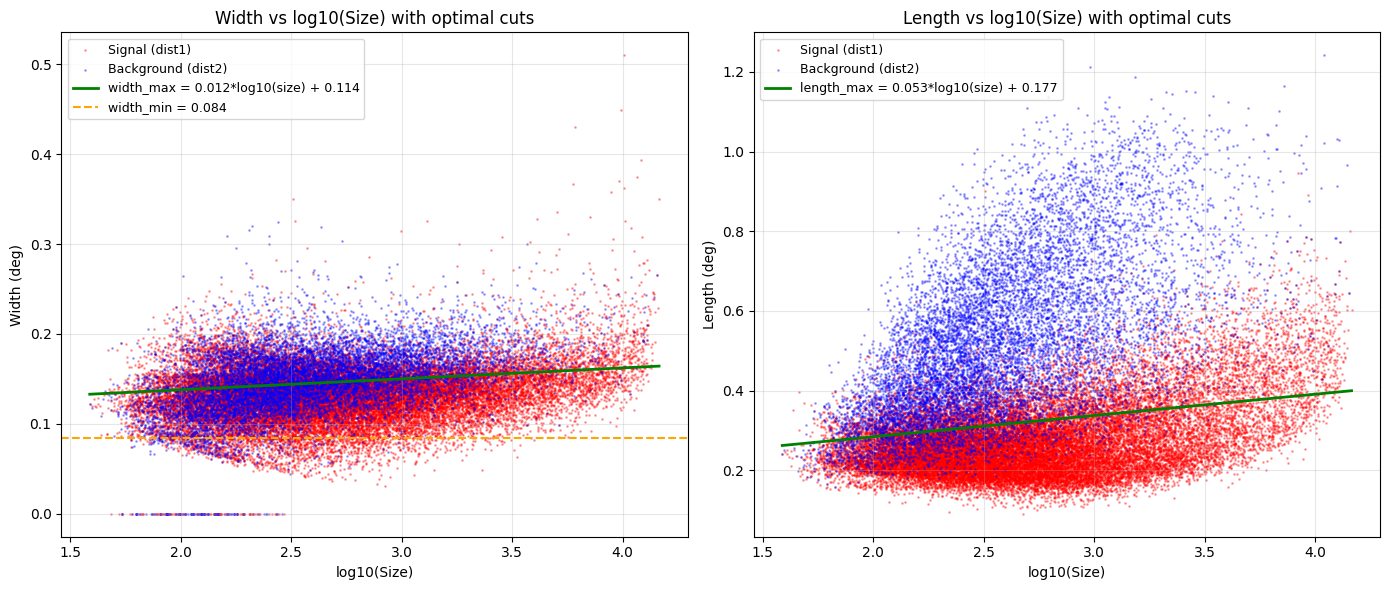

In [103]:
# ============================================
# 5. Визуализация
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График width
axes[0].scatter(signal_data['log10_size'], signal_data['width'], 
                s=1, alpha=0.3, color='red', label='Signal (dist1)')
axes[0].scatter(bg_data['log10_size'], bg_data['width'], 
                s=1, alpha=0.3, color='blue', label='Background (dist2)')

# Верхняя граница
x_line = np.linspace(signal_data['log10_size'].min(), signal_data['log10_size'].max(), 100)
y_upper_w = a_w * x_line + b_w
axes[0].plot(x_line, y_upper_w, 'g-', linewidth=2, label=f'width_max = {a_w:.3f}*log10(size) + {b_w:.3f}')

# Нижняя граница
axes[0].axhline(width_min_const, color='orange', linestyle='--', 
                label=f'width_min = {width_min_const:.3f}')

axes[0].set_xlabel('log10(Size)')
axes[0].set_ylabel('Width (deg)')
axes[0].set_title('Width vs log10(Size) with optimal cuts')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# График length
axes[1].scatter(signal_data['log10_size'], signal_data['length'], 
                s=1, alpha=0.3, color='red', label='Signal (dist1)')
axes[1].scatter(bg_data['log10_size'], bg_data['length'], 
                s=1, alpha=0.3, color='blue', label='Background (dist2)')

# Верхняя граница
y_upper_l = a_l * x_line + b_l
axes[1].plot(x_line, y_upper_l, 'g-', linewidth=2, label=f'length_max = {a_l:.3f}*log10(size) + {b_l:.3f}')

axes[1].set_xlabel('log10(Size)')
axes[1].set_ylabel('Length (deg)')
axes[1].set_title('Length vs log10(Size) with optimal cuts')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.savefig('Mrk_501_researches/wigth_length_1_time.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Сигнальных событий: 31630
Фоновых событий: 11270

ОПТИМИЗАЦИЯ НИЖНЕЙ ГРАНИЦЫ WIDTH (width > w_min)


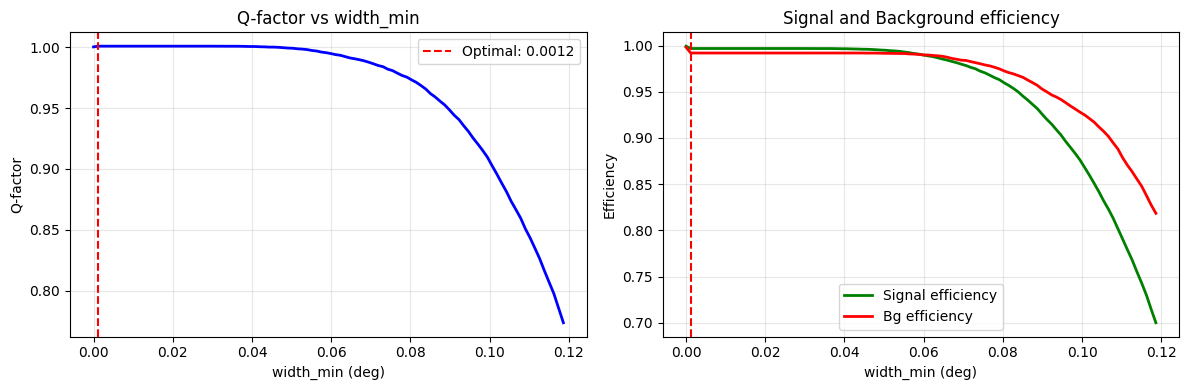


Результат:
  Оптимальный w_min: 0.0012°
  Q-фактор: 1.001
  Эффективность сигнала: 99.7%
  Остаток фона: 99.2%

ОПТИМИЗАЦИЯ ВЕРХНЕЙ ГРАНИЦЫ WIDTH (width < a*log10(size) + b)

Результат:
  width < 0.0388 * log10(size) + 0.0500
  Q-фактор: 1.041
  Эффективность сигнала: 78.2%
  Остаток фона: 56.4%

ОПТИМИЗАЦИЯ ВЕРХНЕЙ ГРАНИЦЫ LENGTH (length < c*log10(size) + d)


/tmp/ipykernel_602923/854547237.py:181: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(evaluate_width_upper, [init_a, init_b],
/tmp/ipykernel_602923/854547237.py:263: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(evaluate_length_upper, [init_c, init_d],



Результат:
  length < 0.0500 * log10(size) + 0.1271
  Q-фактор: 3.034
  Эффективность сигнала: 49.3%
  Остаток фона: 2.6%

СОВМЕСТНАЯ ОПТИМИЗАЦИЯ ВСЕХ КАТОВ


/tmp/ipykernel_602923/854547237.py:343: OptimizeWarning: Initial guess is not within the specified bounds
  result = minimize(evaluate_all_cuts, initial_params,



ОПТИМАЛЬНЫЕ КАТЫ (максимизация Q-фактора):

  (df['width'] > 0.0198) &
  (df['width'] < 0.1453 * np.log10(df['size']) + 0.0500) &
  (df['length'] < 0.1072 * np.log10(df['size']) + -0.0226)

Качество:
  Q-фактор: 3.882
  Эффективность сигнала: 48.0%
  Подавление фона: 98.5%


In [ ]:
from scipy.optimize import minimize, differential_evolution
from itertools import product

# ============================================
# 1. Подготовка данных
# ============================================

sim_hill_iact03['log10_size'] = np.log10(sim_hill_iact03['size'])

dist_min = 0.3
dist_max = 1.4

signal_mask = sim_hill_iact03['dist1'].between(dist_min, dist_max)
background_mask = sim_hill_iact03['dist2'].between(dist_min, dist_max)

signal_data = sim_hill_iact03[signal_mask].copy()
bg_data = sim_hill_iact03[background_mask].copy()

print(f"Сигнальных событий: {len(signal_data)}")
print(f"Фоновых событий: {len(bg_data)}")

# ============================================
# 2. Определение Q-фактора
# ============================================

def compute_q_factor(signal_kept, total_signal, bg_kept, total_bg):
    """
    Вычисление Q-фактора
    
    Q = efficiency_signal / sqrt(efficiency_bg)
    где:
    - efficiency_signal = signal_kept / total_signal
    - efficiency_bg = bg_kept / total_bg
    """
    eps_sig = signal_kept / total_signal if total_signal > 0 else 0
    eps_bg = bg_kept / total_bg if total_bg > 0 else 1e-10
    
    if eps_bg <= 0:
        return 0
    
    q_factor = eps_sig / np.sqrt(eps_bg)
    return q_factor

# ============================================
# 3. Поиск оптимального ката для width (константа)
# ============================================

def optimize_width_constant(signal_data, bg_data, n_trials=100):
    """
    Поиск оптимального постоянного ката для width
    Формат: width > w_min (нижняя граница)
    """
    best_q = 0
    best_w_min = None
    results = []
    
    # Перебираем возможные значения w_min
    test_values = np.linspace(signal_data['width'].min(), 
                              signal_data['width'].quantile(0.3), 
                              n_trials)
    
    for w_min in test_values:
        signal_kept = (signal_data['width'] > w_min).sum()
        bg_kept = (bg_data['width'] > w_min).sum()
        
        q_factor = compute_q_factor(signal_kept, len(signal_data), 
                                    bg_kept, len(bg_data))
        
        results.append({'w_min': w_min, 'q_factor': q_factor, 
                       'signal_eff': signal_kept/len(signal_data),
                       'bg_eff': bg_kept/len(bg_data)})
        
        if q_factor > best_q:
            best_q = q_factor
            best_w_min = w_min
    
    results_df = pd.DataFrame(results)
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(results_df['w_min'], results_df['q_factor'], 'b-', linewidth=2)
    axes[0].axvline(best_w_min, color='red', linestyle='--', 
                    label=f'Optimal: {best_w_min:.4f}')
    axes[0].set_xlabel('width_min (deg)')
    axes[0].set_ylabel('Q-factor')
    axes[0].set_title('Q-factor vs width_min')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(results_df['w_min'], results_df['signal_eff'], 'g-', 
                 label='Signal efficiency', linewidth=2)
    axes[1].plot(results_df['w_min'], results_df['bg_eff'], 'r-', 
                 label='Bg efficiency', linewidth=2)
    axes[1].axvline(best_w_min, color='red', linestyle='--')
    axes[1].set_xlabel('width_min (deg)')
    axes[1].set_ylabel('Efficiency')
    axes[1].set_title('Signal and Background efficiency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return best_w_min, best_q, results_df

# Запуск оптимизации для нижней границы width
print("\n" + "="*70)
print("ОПТИМИЗАЦИЯ НИЖНЕЙ ГРАНИЦЫ WIDTH (width > w_min)")
print("="*70)

best_w_min, best_q_wmin, results_wmin = optimize_width_constant(signal_data, bg_data)

print(f"\nРезультат:")
print(f"  Оптимальный w_min: {best_w_min:.4f}°")
print(f"  Q-фактор: {best_q_wmin:.3f}")
print(f"  Эффективность сигнала: {results_wmin[results_wmin['w_min']==best_w_min]['signal_eff'].values[0]:.1%}")
print(f"  Остаток фона: {results_wmin[results_wmin['w_min']==best_w_min]['bg_eff'].values[0]:.1%}")
# ============================================
# 4. Оптимизация верхней границы width: width < a*log10(size) + b
# ============================================

def evaluate_width_upper(params, signal_data, bg_data):
    """
    Оценка Q-фактора для верхней границы width
    params = [a, b] где граница: width < a*log10(size) + b
    """
    a, b = params
    
    # Применяем кат
    signal_kept = (signal_data['width'] < a * signal_data['log10_size'] + b).sum()
    bg_kept = (bg_data['width'] < a * bg_data['log10_size'] + b).sum()
    
    q_factor = compute_q_factor(signal_kept, len(signal_data), 
                                bg_kept, len(bg_data))
    
    # Штраф за слишком маленькую эффективность сигнала
    signal_eff = signal_kept / len(signal_data)
    if signal_eff < 0.5:  # Не хотим терять больше 50% сигнала
        q_factor = q_factor * (signal_eff / 0.5)
    
    return -q_factor  # минус для минимизации

def optimize_width_upper(signal_data, bg_data):
    """
    Поиск оптимальных параметров для width < a*log10(size) + b
    """
    # Начальные приближения из квантильного метода
    from sklearn.linear_model import RANSACRegressor, LinearRegression
    
    # Оценка начальных параметров через 90% квантиль
    bin_edges = np.linspace(signal_data['log10_size'].min(), 
                            signal_data['log10_size'].max(), 15)
    bin_centers = []
    upper_bounds = []
    
    for i in range(len(bin_edges)-1):
        mask = (signal_data['log10_size'] >= bin_edges[i]) & \
               (signal_data['log10_size'] < bin_edges[i+1])
        if mask.sum() > 20:
            bin_centers.append((bin_edges[i] + bin_edges[i+1])/2)
            upper_bounds.append(signal_data.loc[mask, 'width'].quantile(0.90))
    
    if len(bin_centers) > 2:
        ransac = RANSACRegressor(min_samples=0.5, residual_threshold=0.01)
        ransac.fit(np.array(bin_centers).reshape(-1, 1), upper_bounds)
        init_a = ransac.estimator_.coef_[0]
        init_b = ransac.estimator_.intercept_
    else:
        init_a = 0.06
        init_b = -0.04
    
    # Границы поиска
    bounds = [(0.02, 0.15),   # a (наклон)
              (-0.15, 0.05)]  # b (сдвиг)
    
    # Оптимизация
    result = minimize(evaluate_width_upper, [init_a, init_b], 
                     args=(signal_data, bg_data),
                     method='Nelder-Mead', bounds=bounds)
    
    if result.success:
        opt_a, opt_b = result.x
    else:
        opt_a, opt_b = init_a, init_b
    
    # Оценка результата
    signal_kept = (signal_data['width'] < opt_a * signal_data['log10_size'] + opt_b).sum()
    bg_kept = (bg_data['width'] < opt_a * bg_data['log10_size'] + opt_b).sum()
    final_q = compute_q_factor(signal_kept, len(signal_data), 
                               bg_kept, len(bg_data))
    
    return opt_a, opt_b, final_q, signal_kept/len(signal_data), bg_kept/len(bg_data)

print("\n" + "="*70)
print("ОПТИМИЗАЦИЯ ВЕРХНЕЙ ГРАНИЦЫ WIDTH (width < a*log10(size) + b)")
print("="*70)

opt_a_w, opt_b_w, q_w, sig_eff_w, bg_eff_w = optimize_width_upper(signal_data, bg_data)

print(f"\nРезультат:")
print(f"  width < {opt_a_w:.4f} * log10(size) + {opt_b_w:.4f}")
print(f"  Q-фактор: {q_w:.3f}")
print(f"  Эффективность сигнала: {sig_eff_w:.1%}")
print(f"  Остаток фона: {bg_eff_w:.1%}")
# ============================================
# 5. Оптимизация верхней границы length: length < c*log10(size) + d
# ============================================

def evaluate_length_upper(params, signal_data, bg_data):
    """
    Оценка Q-фактора для верхней границы length
    params = [c, d] где граница: length < c*log10(size) + d
    """
    c, d = params
    
    signal_kept = (signal_data['length'] < c * signal_data['log10_size'] + d).sum()
    bg_kept = (bg_data['length'] < c * bg_data['log10_size'] + d).sum()
    
    q_factor = compute_q_factor(signal_kept, len(signal_data), 
                                bg_kept, len(bg_data))
    
    # Штраф за слишком маленькую эффективность сигнала
    signal_eff = signal_kept / len(signal_data)
    if signal_eff < 0.5:
        q_factor = q_factor * (signal_eff / 0.5)
    
    return -q_factor

def optimize_length_upper(signal_data, bg_data):
    """
    Поиск оптимальных параметров для length < c*log10(size) + d
    """
    # Оценка начальных параметров через 90% квантиль
    bin_edges = np.linspace(signal_data['log10_size'].min(), 
                            signal_data['log10_size'].max(), 15)
    bin_centers = []
    upper_bounds = []
    
    for i in range(len(bin_edges)-1):
        mask = (signal_data['log10_size'] >= bin_edges[i]) & \
               (signal_data['log10_size'] < bin_edges[i+1])
        if mask.sum() > 20:
            bin_centers.append((bin_edges[i] + bin_edges[i+1])/2)
            upper_bounds.append(signal_data.loc[mask, 'length'].quantile(0.90))
    
    if len(bin_centers) > 2:
        ransac = RANSACRegressor(min_samples=0.5, residual_threshold=0.015)
        ransac.fit(np.array(bin_centers).reshape(-1, 1), upper_bounds)
        init_c = ransac.estimator_.coef_[0]
        init_d = ransac.estimator_.intercept_
    else:
        init_c = 0.12
        init_d = 0.02
    
    # Границы поиска
    bounds = [(0.05, 0.25),   # c (наклон)
              (-0.10, 0.15)]  # d (сдвиг)
    
    result = minimize(evaluate_length_upper, [init_c, init_d], 
                     args=(signal_data, bg_data),
                     method='Nelder-Mead', bounds=bounds)
    
    if result.success:
        opt_c, opt_d = result.x
    else:
        opt_c, opt_d = init_c, init_d
    
    signal_kept = (signal_data['length'] < opt_c * signal_data['log10_size'] + opt_d).sum()
    bg_kept = (bg_data['length'] < opt_c * bg_data['log10_size'] + opt_d).sum()
    final_q = compute_q_factor(signal_kept, len(signal_data), 
                               bg_kept, len(bg_data))
    
    return opt_c, opt_d, final_q, signal_kept/len(signal_data), bg_kept/len(bg_data)

print("\n" + "="*70)
print("ОПТИМИЗАЦИЯ ВЕРХНЕЙ ГРАНИЦЫ LENGTH (length < c*log10(size) + d)")
print("="*70)

opt_c_l, opt_d_l, q_l, sig_eff_l, bg_eff_l = optimize_length_upper(signal_data, bg_data)

print(f"\nРезультат:")
print(f"  length < {opt_c_l:.4f} * log10(size) + {opt_d_l:.4f}")
print(f"  Q-фактор: {q_l:.3f}")
print(f"  Эффективность сигнала: {sig_eff_l:.1%}")
print(f"  Остаток фона: {bg_eff_l:.1%}")
# ============================================
# 6. Совместная оптимизация всех катов
# ============================================

def evaluate_all_cuts(params, signal_data, bg_data):
    """
    params = [w_min, a_w, b_w, c_l, d_l]
    """
    w_min, a_w, b_w, c_l, d_l = params
    
    mask_signal = (signal_data['width'] > w_min) & \
                  (signal_data['width'] < a_w * signal_data['log10_size'] + b_w) & \
                  (signal_data['length'] < c_l * signal_data['log10_size'] + d_l)
    
    mask_bg = (bg_data['width'] > w_min) & \
              (bg_data['width'] < a_w * bg_data['log10_size'] + b_w) & \
              (bg_data['length'] < c_l * bg_data['log10_size'] + d_l)
    
    signal_kept = mask_signal.sum()
    bg_kept = mask_bg.sum()
    
    q_factor = compute_q_factor(signal_kept, len(signal_data), 
                                bg_kept, len(bg_data))
    
    # Штрафы
    signal_eff = signal_kept / len(signal_data)
    if signal_eff < 0.5:  # Не хотим терять >50% сигнала
        q_factor = q_factor * (signal_eff / 0.5)
    
    return -q_factor

def optimize_all_cuts(signal_data, bg_data):
    """
    Совместная оптимизация всех параметров
    """
    # Начальные параметры
    w_min_init = best_w_min
    a_w_init = opt_a_w
    b_w_init = opt_b_w
    c_l_init = opt_c_l
    d_l_init = opt_d_l
    
    initial_params = [w_min_init, a_w_init, b_w_init, c_l_init, d_l_init]
    
    # Границы
    bounds = [
        (0.01, 0.08),                    # w_min
        (0.02, 0.15),                    # a_w
        (-0.15, 0.05),                   # b_w
        (0.05, 0.25),                    # c_l
        (-0.10, 0.15)                    # d_l
    ]
    
    result = minimize(evaluate_all_cuts, initial_params, 
                     args=(signal_data, bg_data),
                     method='Nelder-Mead', bounds=bounds,
                     options={'maxiter': 500, 'xatol': 1e-4})
    
    if result.success:
        opt_params = result.x
    else:
        opt_params = initial_params
    
    w_min, a_w, b_w, c_l, d_l = opt_params
    
    # Оценка
    mask_signal = (signal_data['width'] > w_min) & \
                  (signal_data['width'] < a_w * signal_data['log10_size'] + b_w) & \
                  (signal_data['length'] < c_l * signal_data['log10_size'] + d_l)
    
    mask_bg = (bg_data['width'] > w_min) & \
              (bg_data['width'] < a_w * bg_data['log10_size'] + b_w) & \
              (bg_data['length'] < c_l * bg_data['log10_size'] + d_l)
    
    signal_eff = mask_signal.mean()
    bg_removed = 1 - mask_bg.mean()
    q_final = compute_q_factor(mask_signal.sum(), len(signal_data),
                               mask_bg.sum(), len(bg_data))
    
    return opt_params, q_final, signal_eff, bg_removed

print("\n" + "="*70)
print("СОВМЕСТНАЯ ОПТИМИЗАЦИЯ ВСЕХ КАТОВ")
print("="*70)

opt_params, q_final, signal_eff, bg_removed = optimize_all_cuts(signal_data, bg_data)

w_min_opt, a_w_opt, b_w_opt, c_l_opt, d_l_opt = opt_params

print(f"\nОПТИМАЛЬНЫЕ КАТЫ (максимизация Q-фактора):")
print(f"\n  (df['width'] > {w_min_opt:.4f}) &")
print(f"  (df['width'] < {a_w_opt:.4f} * np.log10(df['size']) + {b_w_opt:.4f}) &")
print(f"  (df['length'] < {c_l_opt:.4f} * np.log10(df['size']) + {d_l_opt:.4f})")

print(f"\nКачество:")
print(f"  Q-фактор: {q_final:.3f}")
print(f"  Эффективность сигнала: {signal_eff:.1%}")
print(f"  Подавление фона: {bg_removed:.1%}")

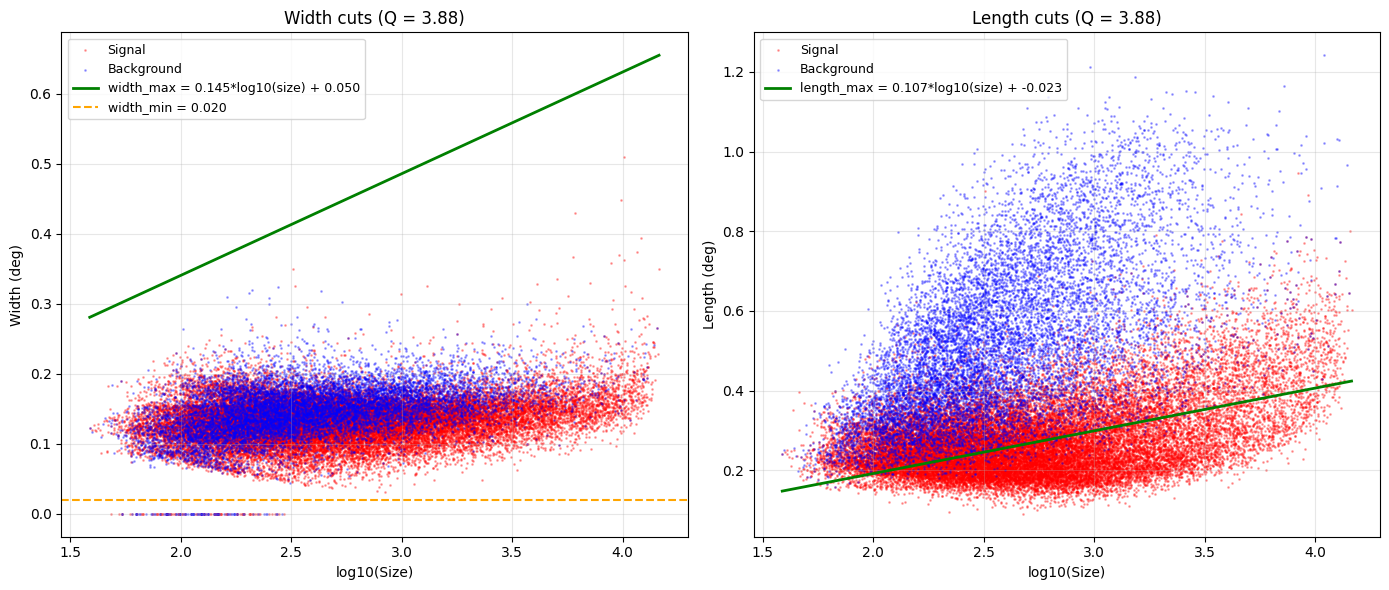


ИТОГОВЫЙ КОД ДЛЯ ВАШЕГО АНАЛИЗА

# Оптимальные каты, найденные максимизацией Q-фактора
# Q-фактор = 3.882
# Эффективность сигнала = 48.0%
# Подавление фона = 98.5%

cuts = (
    (df['width'] > 0.0198) &
    (df['width'] < 0.1453 * np.log10(df['size']) + 0.0500) &
    (df['length'] < 0.1072 * np.log10(df['size']) + -0.0226) &
    (df['num_islands'] == 1) &
    (df['edge'] == 0)
)



In [47]:
# ============================================
# 7. Визуализация оптимальных катов
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График width
x_range = np.linspace(signal_data['log10_size'].min(), 
                      signal_data['log10_size'].max(), 100)

axes[0].scatter(signal_data['log10_size'], signal_data['width'], 
                s=1, alpha=0.3, color='red', label='Signal')
axes[0].scatter(bg_data['log10_size'], bg_data['width'], 
                s=1, alpha=0.3, color='blue', label='Background')

# Верхняя граница
y_upper = a_w_opt * x_range + b_w_opt
axes[0].plot(x_range, y_upper, 'g-', linewidth=2, 
             label=f'width_max = {a_w_opt:.3f}*log10(size) + {b_w_opt:.3f}')

# Нижняя граница
axes[0].axhline(w_min_opt, color='orange', linestyle='--', 
                label=f'width_min = {w_min_opt:.3f}')

axes[0].set_xlabel('log10(Size)')
axes[0].set_ylabel('Width (deg)')
axes[0].set_title(f'Width cuts (Q = {q_final:.2f})')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# График length
axes[1].scatter(signal_data['log10_size'], signal_data['length'], 
                s=1, alpha=0.3, color='red', label='Signal')
axes[1].scatter(bg_data['log10_size'], bg_data['length'], 
                s=1, alpha=0.3, color='blue', label='Background')

# Верхняя граница
y_upper_l = c_l_opt * x_range + d_l_opt
axes[1].plot(x_range, y_upper_l, 'g-', linewidth=2,
             label=f'length_max = {c_l_opt:.3f}*log10(size) + {d_l_opt:.3f}')

axes[1].set_xlabel('log10(Size)')
axes[1].set_ylabel('Length (deg)')
axes[1].set_title(f'Length cuts (Q = {q_final:.2f})')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 8. Итоговый вывод
# ============================================

print("\n" + "="*70)
print("ИТОГОВЫЙ КОД ДЛЯ ВАШЕГО АНАЛИЗА")
print("="*70)

print(f"""
# Оптимальные каты, найденные максимизацией Q-фактора
# Q-фактор = {q_final:.3f}
# Эффективность сигнала = {signal_eff:.1%}
# Подавление фона = {bg_removed:.1%}

cuts = (
    (df['width'] > {w_min_opt:.4f}) &
    (df['width'] < {a_w_opt:.4f} * np.log10(df['size']) + {b_w_opt:.4f}) &
    (df['length'] < {c_l_opt:.4f} * np.log10(df['size']) + {d_l_opt:.4f}) &
    (df['num_islands'] == 1) &
    (df['edge'] == 0)
)
""")

### Применяем каты

In [101]:
def filter_hillas_data(df):
    common_filters = (
        (df['CR_portion'].between(35, 150)) &
        # (df['CR_portion'] > 35) &
        (df['size'] > 155) &
        (df['tracking'] == 1) &
        # (df['weather_mark'] > 8) &
        (df['good'] == 1) &
        (df['edge'] == 0) &
        (df['width'] > 0.084) &
        (df['width'] < 0.012 * np.log10(df['size']) + 0.104) &
        # (df['length'] < 0.107 * np.log10(df['size']) - 0.023) # rude cut
        (df['length'] < 0.053 * np.log10(df['size']) + 0.177)

    )

    # Source selection (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.3, 1.41))
    ].copy()
    source_df['source_type'] = 'source'  # Add identifier column
    
    # Anti-source selection (dist2)
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.3, 1.41))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'  # Add identifier column
    
    return source_df, anti_source_df


source_events, antisource_events = filter_hillas_data(hillas_mrk501)
source_events

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,source_dec,source_x,source_y,tracking,good,star,edge,weather_mark,alpha_c,source_type
216211,2,15820,19:02:50:881:535:280,1679684570881535280,0.12,0.03,93.85972,57.356,95.23537,58.297,...,39.76,0.72,-0.99,1.0,1.0,0.0,0.0,9.28,-1.26,source
220665,3,24044,19:04:20:363:454:210,1679684660363454210,0.14,0.03,94.18428,57.586,95.56466,58.527,...,39.76,0.72,-0.99,1.0,1.0,0.0,0.0,9.21,-1.26,source
226593,3,35063,19:06:11:544:040:800,1679684771544040800,0.46,0.03,94.58300,57.872,95.97838,58.813,...,39.76,0.72,-0.99,1.0,1.0,0.0,0.0,9.27,-1.26,source
231199,4,43826,19:07:43:282:667:510,1679684863282667510,0.28,0.03,94.91273,58.106,96.31899,59.047,...,39.76,0.72,-0.99,1.0,1.0,0.0,0.0,9.27,-1.27,source
234345,5,49544,19:08:46:058:007:990,1679684926058007990,0.06,0.03,95.14388,58.268,96.55639,59.208,...,39.76,0.72,-0.99,1.0,1.0,0.0,0.0,9.23,-1.27,source
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16948885,38,286327,22:05:04:324:140:560,1707516304324140560,0.18,0.03,99.50066,61.130,98.00738,60.173,...,39.76,-0.74,0.99,1.0,1.0,0.0,0.0,8.78,-1.21,source
16956949,41,299088,22:09:01:350:725:120,1707516541350725120,0.15,0.03,97.48483,59.832,98.94496,60.778,...,39.76,0.71,-0.99,1.0,1.0,0.0,0.0,8.84,-1.20,source
16957731,41,300383,22:09:20:290:392:790,1707516560290392790,0.21,0.03,97.55437,59.876,99.02106,60.826,...,39.76,0.71,-1.00,1.0,1.0,0.0,0.0,9.02,-1.20,source
16959903,41,304381,22:10:24:883:293:190,1707516624883293190,0.12,0.03,97.80021,60.047,99.28048,60.991,...,39.76,0.72,-0.99,1.0,1.0,0.0,0.0,8.21,-1.20,source


### Гистограмма по тета

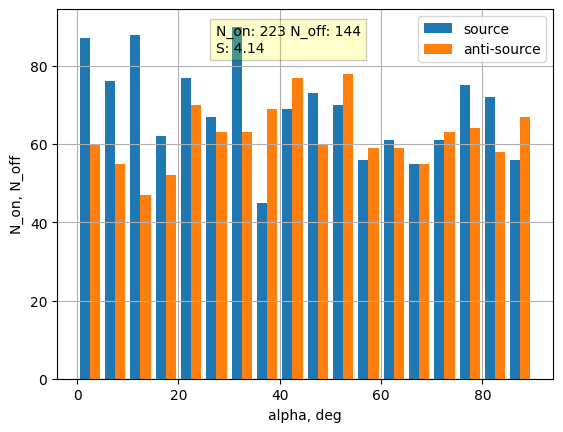

N_on = 223 N_off = 144 S_lima = 4.14
90.0


In [102]:
# # alpha

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=18,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
# plt.title('Crab IACT01 23.11.19') 
N_on = len(source_events.loc[source_events['alpha1']<13])
N_off = len(antisource_events.loc[antisource_events['alpha2']<13])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.savefig('Mrk_501_researches/alpha_IACT03.png', dpi=300, bbox_inches='tight')
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)
print(antisource_events['alpha2'].max())

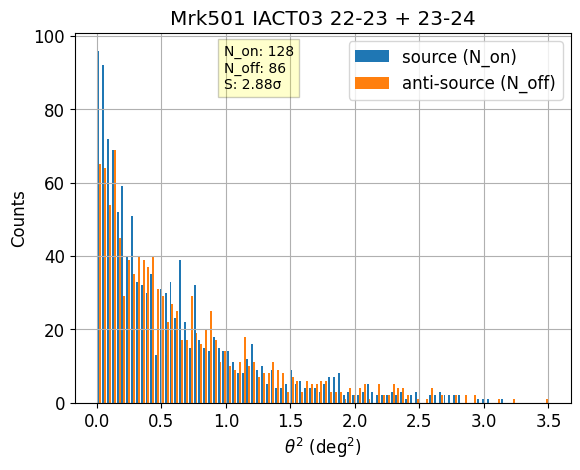

In [178]:
def calculate_ksi(rc, size):
    if rc < 7.5:
        return 1.3
    elif 7.5 < rc < 10:
        return 1.6
    elif rc > 10:
        if size < 700:
            return 2.0
        elif 700 < size < 1000:
            return 1.9
        elif 1000 < size < 1250:
            return 1.75
        elif 1250 < size < 1500:
            return 1.5
    return np.nan

# Создаем явные копии срезов
source_events = source_events.copy()
antisource_events = antisource_events.copy()

# Process source events (N_on)
source_events['rc'] = source_events['dist1'] / 0.1206
source_events['ksi'] = source_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
source_events = source_events[~source_events['ksi'].isna()]  # Remove NaN values
source_events['disp'] = source_events['ksi'] * (1.0 - source_events['width'] / source_events['length'])
source_events['theta2'] = (source_events['disp']**2 + source_events['dist1']**2 - 
                          2 * source_events['disp'] * source_events['dist1'] * np.cos(np.radians(source_events['alpha1'])))

# Process anti-source events (N_off)
antisource_events['rc'] = antisource_events['dist2'] / 0.1206
antisource_events['ksi'] = antisource_events.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
antisource_events = antisource_events[~antisource_events['ksi'].isna()]  # Remove NaN values
antisource_events['disp'] = antisource_events['ksi'] * (1.0 - antisource_events['width'] / antisource_events['length'])
antisource_events['theta2'] = (antisource_events['disp']**2 + antisource_events['dist2']**2 - 
                              2 * antisource_events['disp'] * antisource_events['dist2'] * np.cos(np.radians(antisource_events['alpha2'])))

# Create histogram
plt.hist([source_events['theta2'], antisource_events['theta2']], 
         bins=94, label=['source (N_on)', 'anti-source (N_off)'])
plt.legend(loc='upper right')
plt.xlabel(r'$\theta^2$ (deg$^2$)')
plt.ylabel('Counts')
plt.title('Mrk501 IACT03 22-23 + 23-24')

# Calculate statistics (using θ² < 0.05 cut)
theta_cut = 0.05
N_on = len(source_events[source_events['theta2'] < theta_cut])
N_off = len(antisource_events[antisource_events['theta2'] < theta_cut])

# Calculate significance
S = round(np.sqrt(2 * N_on * np.log(2 * (N_on / (N_on + N_off))) + 2 * N_off * np.log(2 * (N_off / (N_on + N_off)))), 2)

plt.annotate(f"N_on: {N_on}\nN_off: {N_off}\nS: {S}σ", 
             fontsize=10, bbox={'facecolor': 'yellow', 'alpha': 0.2},
             xy=(0.3, 0.85), xycoords='axes fraction')

plt.grid()
plt.savefig('Mrk_501_researches/teta_1_IACT03.png', dpi=300, bbox_inches='tight')
plt.show()

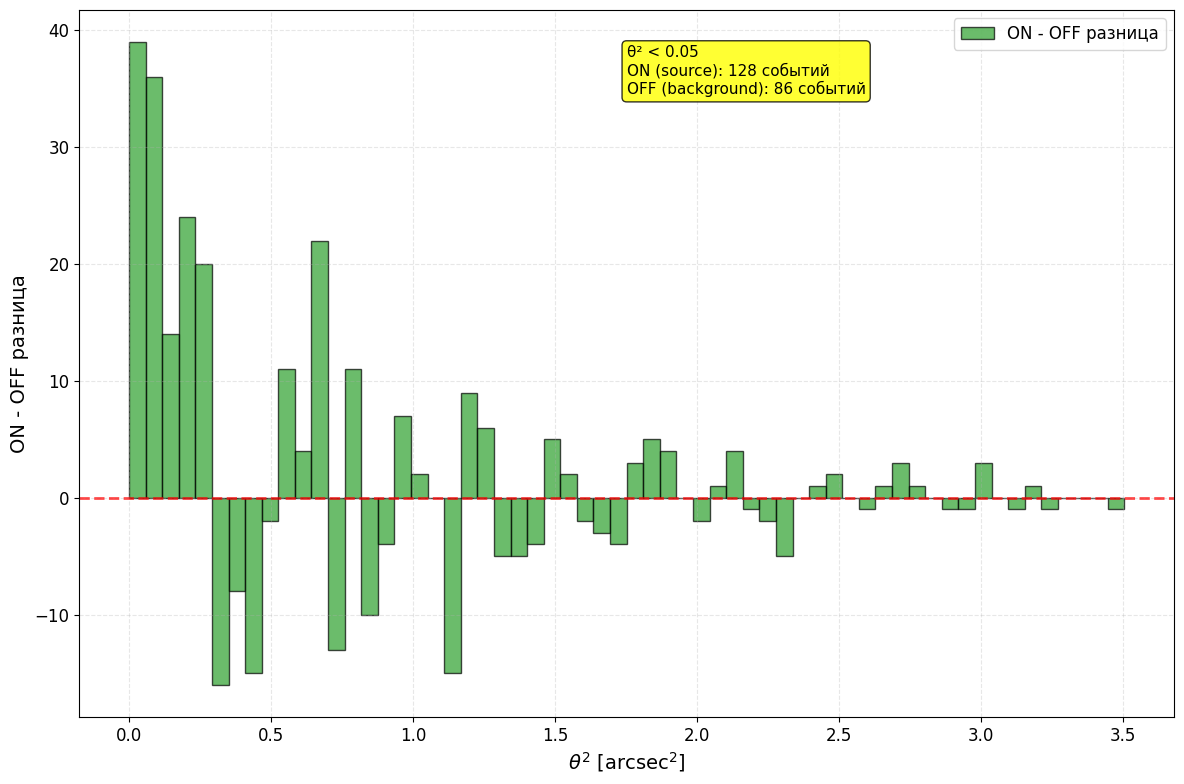

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, log

def plot_on_off_difference(source_df, anti_source_df, bins=40, theta_cut=None):

    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.rcParams['font.size'] = 12

    # Данные источника (ON)
    source_data = source_df['theta2'].dropna()
    
    # Данные фона (OFF) - только одна область
    off_data = anti_source_df['theta2'].dropna()

    # Общие бины для гистограмм
    max_val = max(source_data.max(), off_data.max())
    bin_edges = np.linspace(0, max_val, bins + 1)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    bin_width = np.diff(bin_edges)[0]
    
    # Гистограмма ON-региона (источник)
    on_hist, _ = np.histogram(source_data, bins=bin_edges)
    
    # Гистограмма OFF-региона (фон) - только одна
    off_hist, _ = np.histogram(off_data, bins=bin_edges)
    
    # Разница ON - OFF
    difference_hist = on_hist - off_hist

    # Визуализация разницы ON-OFF
    plt.bar(bin_centers, difference_hist, width=bin_width, 
            color='#2ca02c', alpha=0.7, label='ON - OFF разница',
            edgecolor='k', linewidth=1)

    # Линия нуля
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
    # Расчёт сигнификантности (если задан theta_cut)
    if theta_cut is not None:
        N_on = np.sum(source_data < theta_cut)        # Сигнальные события до theta_cut
        N_off = np.sum(off_data < theta_cut)          # Фоновые события до theta_cut
        
        # Формула Ли-Ма для одного фонового региона (alpha = 1) с полной защитой
        eps = 1e-10
        
        if N_on > 0 and N_off > 0:
            try:
                term1 = N_on * log(N_on / (N_off + eps))
                term2 = N_off * log(N_off / (N_on + N_off + eps))
                argument = 2 * (term1 + term2)
                
                # Защита от отрицательного аргумента под корнем
                if argument < 0:
                    S = 0.0
                else:
                    S = sqrt(argument)
                    S = round(S, 2)
            except (ValueError, ZeroDivisionError):
                S = 0.0
        elif N_on > 0 and N_off == 0:
            # Если фона нет, используем приближение Пуассона
            S = round(N_on / sqrt(N_on), 2)
        else:
            S = 0.0
        
        stats_text = "\n".join([
            f"θ² < {theta_cut}",
            f"ON (source): {N_on} событий",
            f"OFF (background): {N_off} событий"        ])
        
        plt.annotate(stats_text, xy=(0.5, 0.95), xycoords='axes fraction',
                    ha='left', va='top', fontsize=11,
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

    plt.xlabel(r'$\theta^2$ [arcsec$^2$]', fontsize=14)
    plt.ylabel('ON - OFF разница', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    plt.savefig('Mrk_501_researches/teta_1_IACT03.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()
    
    # Возвращаем данные для анализа
    return {
        'bin_centers': bin_centers,
        'bin_edges': bin_edges,
        'on_hist': on_hist,
        'off_hist': off_hist,
        'difference_hist': difference_hist,
        'N_on': N_on if theta_cut else None,
        'N_off': N_off if theta_cut else None,
        'significance': S if theta_cut else None
    }


result = plot_on_off_difference(
    source_df=source_events,           # ON-область (источник)
    anti_source_df=antisource_events,  # OFF-область (фон, одна)
    bins=60,
    theta_cut=0.05 
)

### Гистограмма по alpha

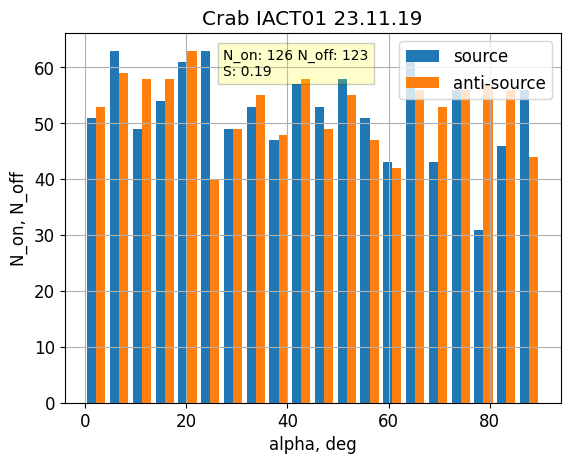

N_on = 126 N_off = 123 S_lima = 0.19
90.0


In [38]:
# # та же самая функция, что выше только с доп катами, как у Паши В
def filter_hillas_data(df):
    common_filters = (
        (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['delta_time'] < 0.5) &
        (df['error_deg'] < 0.1) &
        (df['size'] > 200) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
    )
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ].copy()
    source_df['source_type'] = 'source' 
    
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ].copy()
    anti_source_df['source_type'] = 'anti-source'
    return source_df, anti_source_df

source_events, antisource_events = filter_hillas_data(hillas_mrk501)

plt.hist([source_events['alpha1'],antisource_events['alpha2']], bins=20,
            label=['source', 'anti-source'])#,stacked=True)  
plt.legend(loc='upper right')
plt.xlabel('alpha, deg')
plt.ylabel('N_on, N_off')
plt.title('Crab IACT01 23.11.19') 
N_on = len(source_events.loc[source_events['alpha1']<10])
N_off = len(antisource_events.loc[antisource_events['alpha2']<10])
S = round(np.sqrt(2*N_on*np.log(2*(N_on/(N_on+N_off))) + 2*N_off*np.log(2*(N_off/(N_on+N_off)))),2) #сигма
plt.annotate(f"N_on: {N_on} N_off: {N_off}\nS: {S}", fontsize=10,
            bbox={'facecolor':'yellow','alpha':0.2},
              xy=(3, 21), xytext=(0.32, 0.885), textcoords='axes fraction')
plt.grid()
plt.savefig('Mrk_501_researches/alpha_IACT03.png', dpi=300, bbox_inches='tight')
plt.show()
print('N_on =', N_on, 'N_off =', N_off, 'S_lima =', S)
print(antisource_events['alpha2'].max())

### Пересчитываем параметры для 5 точек фона

In [117]:
# Пересчитываем альфа и дисты
def add_background_alphas_dists_thetas_abs(df):

    # Вектор от CoG до источника
    dx = df['source_x'] - df['Xc']
    dy = df['source_y'] - df['Yc']
    v_angle = np.arctan2(dy, dx)  # угол в радианах

    # Направление главной оси эллипса: от вектора на источник - alpha1
    u_angle = np.arctan(df.a_axis)  # главная ось в радианах
    u_x = np.cos(u_angle)
    u_y = np.sin(u_angle)

    # Расстояние от центра камеры до источника — радиус окружности
    r = np.sqrt(df['source_x']**2 + df['source_y']**2)
    print(r)

    # Угол на источник из центра камеры
    angle0 = np.arctan2(df['source_y'], df['source_x'])

    angles_deg = [180, 60, 120, 240, 300] # антиисточник и 4 новых фоновых
    angles_rad = [angle0 + np.deg2rad(a) for a in angles_deg]

    for i, angle in enumerate(angles_rad, start=1):
        # Координаты точки на окружности
        x = r * np.cos(angle)
        y = r * np.sin(angle)

        dx = x - df['Xc']
        dy = y - df['Yc']
        dist = np.sqrt(dx**2 + dy**2)

        v_angle = np.arctan2(dy, dx)
        delta = np.abs(v_angle - u_angle)
        delta = np.mod(delta, 2 * np.pi)
        alpha = np.minimum(delta, 2 * np.pi - delta)
        alpha_deg = np.rad2deg(alpha)
        alpha_deg = np.where(alpha_deg > 90, 180 - alpha_deg, alpha_deg)

        df[f'bg{i}_dist'] = dist
        df[f'bg{i}_alpha'] = alpha_deg
    return df

hillas_with_5point_background = add_background_alphas_dists_thetas_abs(hillas_mrk501)

hillas_with_5point_background

0           1.325745
1           1.325745
2           1.325745
3           1.325745
4           1.325745
              ...   
17474313    1.316549
17474314    1.316549
17474315    1.316549
17474316    1.316549
17474317    1.316549
Length: 17474318, dtype: float64


,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
0,1,1,19:08:04:735:640:150,1679512084735640150,0.26,0.03,93.25193,56.837,94.66100,57.891,...,5.032897,14.119144,3.198373,33.940290,4.477986,28.689772,4.559054,0.732486,3.310921,7.327422
1,1,3,19:08:04:802:339:860,1679512084802339860,0.20,0.03,93.25193,56.837,94.66100,57.891,...,3.532126,50.700415,4.047673,16.277921,2.980755,29.286658,4.854451,49.383541,5.573550,37.091678
2,1,4,19:08:04:802:956:610,1679512084802956610,0.20,0.03,93.25193,56.837,94.66100,57.891,...,3.208151,12.967503,2.724841,31.653247,2.105852,3.323951,4.374929,3.329317,4.704269,12.944142
3,1,7,19:08:04:841:064:550,1679512084841064550,0.16,0.03,93.25193,56.837,94.66100,57.891,...,4.615120,43.172984,2.428304,31.162663,3.750412,29.299420,4.512665,59.826414,3.492165,72.063991
4,1,8,19:08:04:844:696:160,1679512084844696160,0.16,0.03,93.25193,56.837,94.66100,57.891,...,3.504005,10.013384,2.078308,48.978125,2.185393,12.857326,4.395860,24.371155,4.343616,41.808280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17474313,54,1349656,22:36:17:063:631:110,1707518177063631110,0.44,0.03,108.03611,65.899,106.10578,64.901,...,0.484942,64.273729,2.323751,14.595562,1.145633,35.344863,1.801445,63.606287,2.707868,38.639337
17474314,54,1349663,22:36:17:090:865:610,1707518177090865610,0.41,0.03,108.03611,65.899,106.10578,64.901,...,5.918183,79.853949,4.791882,58.396058,5.840930,67.019308,4.977849,89.592689,3.691158,85.865505
17474315,54,1349670,22:36:17:135:592:840,1707518177135592840,0.36,0.03,108.03611,65.899,106.10578,64.901,...,4.571747,86.444226,3.135057,66.505267,4.273329,76.874981,3.886856,71.116058,2.583582,67.743860
17474316,54,1349671,22:36:17:136:888:800,1707518177136888800,0.36,0.03,108.03611,65.899,106.10578,64.901,...,1.027186,67.741553,1.900024,30.131848,1.606901,12.963613,0.745689,17.685523,1.258576,59.798691


### Накладываем каты

In [18]:
# Sveshnikova's cuts
def filter_hillas_data_split_background(df):
    # Общие фильтры
    common_filters = (
        # (df['CR_portion']/np.cos(np.pi/2-np.pi*df['tel_el']/180) > 5) &
        (df['CR_portion'] > 5) &
        (df['size'] > 200) &
        (df['tracking'] == 1) &
        (df['weather_mark'] > 8) &
        (df['good'] == 1) &
        # (df['edge'] == 0) &
        (df['width'] > 0.024) &
        (df['width'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length'] < 0.145 * np.log10(df['size']))
        # (df['skewness_l'] > 1.15*np.log10(df['size'])-2.85)
    )
    
    # Таблица с источником (dist1)
    source_df = df[
        common_filters &
        (df['dist1'].between(0.36, 1.44))
    ]
    # Отдельные таблицы для каждого фонового региона
    anti_source_df = df[
        common_filters &
        (df['dist2'].between(0.36, 1.44))
    ]
    bg2_df = df[
        common_filters &
        (df['bg2_dist'].between(0.36, 1.44))
    ]
    bg3_df = df[
        common_filters &
        (df['bg3_dist'].between(0.36, 1.44))
    ]
    bg4_df = df[
        common_filters &
        (df['bg4_dist'].between(0.36, 1.44))
    ]
    bg5_df = df[
        common_filters &
        (df['bg5_dist'].between(0.36, 1.44))
    ]
    return source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df

source, anti_source, bg2, bg3, bg4, bg5 = filter_hillas_data_split_background(hillas_with_5point_background)
bg5

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_dist,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha
213240,1,10331,19:01:49:718:028:230,1679684509718028230,0.22,0.03,93.64166,57.198,95.01053,58.138,...,1.976665,31.682219,1.337774,45.188181,1.893665,5.115607,1.559524,69.945802,0.797362,59.181030
229028,4,39733,19:07:01:878:591:730,1679684821878591730,0.12,0.03,94.76555,58.001,96.16520,58.941,...,1.938583,85.752945,2.944296,48.258179,2.798981,72.702458,0.718679,89.310905,1.162362,12.073534
239357,5,58872,19:10:19:873:815:100,1679685019873815100,0.13,0.03,95.48777,58.509,96.91308,59.449,...,2.127334,11.267646,2.901445,58.080919,2.884621,33.654928,0.909620,6.109442,0.961642,87.772396
245973,7,71212,19:12:31:728:851:780,1679685151728851780,0.23,0.03,95.97417,58.846,97.41716,59.786,...,0.835448,19.185735,1.556325,77.254613,1.203290,52.031070,0.960354,75.165804,1.377142,15.109692
247144,7,73401,19:12:54:336:386:100,1679685174336386100,0.34,0.03,96.05940,58.904,97.50401,59.844,...,1.585195,80.331053,1.139037,20.607591,1.476277,33.360022,1.401536,51.763081,1.040343,6.172284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16845289,13,86748,21:12:37:001:416:180,1707513157001416180,0.00,0.03,88.29752,53.034,87.11291,52.065,...,2.576698,48.257106,1.264101,7.787334,2.216319,19.558740,2.247788,76.973697,1.318495,75.535023
16879272,20,139718,21:27:16:357:154:630,1707514036357154630,0.14,0.03,88.71320,53.382,89.92306,54.335,...,3.197134,30.501698,2.256090,10.775198,3.107745,8.233668,2.493414,50.848332,1.284125,56.171686
16879419,20,139963,21:27:20:257:866:630,1707514040257866630,0.24,0.03,88.72391,53.392,89.93618,54.345,...,1.176113,14.815918,1.957039,84.475478,1.781312,57.777656,0.500338,68.176692,0.952506,1.413506
16880265,20,141367,21:27:42:135:933:060,1707514062135933060,0.14,0.03,88.79571,53.447,90.00674,54.401,...,2.416525,12.498482,3.212291,53.659002,3.206859,31.735155,1.195870,12.551274,1.210361,73.514624


### Вычисляем тета

In [40]:
def calculate_theta2_for_all_separate(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df):
    def calculate_ksi(rc, size):
        """Функция для расчета коэффициента ksi"""
        if rc < 7.5:
            return 1.3
        elif rc <= 10:
            return 1.6
        else:
            if size < 700:
                return 2.0
            elif size < 1000:
                return 1.9
            elif size < 1250:
                return 1.75
            elif size < 1500:
                return 1.5
        return np.nan

    # 1. Обработка источника
    source_processed = source_df.copy()
    if 'dist1' in source_processed.columns:
        source_processed['source_rc'] = source_processed['dist1'] / 0.1206
        source_processed['source_ksi'] = source_processed.apply(
            lambda row: calculate_ksi(row['source_rc'], row['size']), axis=1)
        source_processed = source_processed[~source_processed['source_ksi'].isna()]  # Remove NaN values
        source_processed['source_disp'] = source_processed['source_ksi'] * (
            1.0 - source_processed['width'] / source_processed['length'])
        source_processed['source_theta2'] = (
            source_processed['source_disp']**2 + 
            source_processed['dist1']**2 - 
            2 * source_processed['source_disp'] * source_processed['dist1'] * 
            np.cos(np.radians(source_processed['alpha1'])))
        
        source_processed = source_processed.drop(
            columns=['source_rc', 'source_ksi', 'source_disp'], errors='ignore')

    # 2. Обработка антиисточника
    anti_source_processed = anti_source_df.copy()
    if 'dist2' in anti_source_processed.columns:
        anti_source_processed['dist2_rc'] = anti_source_processed['dist2'] / 0.1206
        anti_source_processed['dist2_ksi'] = anti_source_processed.apply(
            lambda row: calculate_ksi(row['dist2_rc'], row['size']), axis=1)
        anti_source_processed = anti_source_processed[~anti_source_processed['dist2_ksi'].isna()]  # Remove NaN value
        anti_source_processed['dist2_disp'] = anti_source_processed['dist2_ksi'] * (
            1.0 - anti_source_processed['width'] / anti_source_processed['length'])
        anti_source_processed['dist2_theta2'] = (
            anti_source_processed['dist2_disp']**2 + 
            anti_source_processed['dist2']**2 - 
            2 * anti_source_processed['dist2_disp'] * anti_source_processed['dist2'] * 
            np.cos(np.radians(anti_source_processed['alpha2']))) # это тета просто так подписано)) 
        
        anti_source_processed = anti_source_processed.drop(
            columns=['dist2_rc', 'dist2_ksi', 'dist2_disp'], errors='ignore')

    # 3-6. Обработка 4 фоновых точек (bg2, bg3, bg4, bg5)
    def process_bg(df, bg_num):
        """Обработка одной фоновой точки"""
        df = df.copy()
        prefix = f'bg{bg_num}_'
        
        df[f'{prefix}rc'] = df[f'{prefix}dist'] / 0.1206
        df[f'{prefix}ksi'] = df.apply(
            lambda row: calculate_ksi(row[f'{prefix}rc'], row['size']), axis=1)
        df = df[~df[f'{prefix}ksi'].isna()]  # Remove NaN values
        df[f'{prefix}disp'] = df[f'{prefix}ksi'] * (1.0 - df['width'] / df['length'])
        # print(df[f'{prefix}disp'])
        df[f'{prefix}theta2'] = (
            df[f'{prefix}disp']**2 + 
            df[f'{prefix}dist']**2 - 
            2 * df[f'{prefix}disp'] * df[f'{prefix}dist'] * 
            np.cos(np.radians(df[f'{prefix}alpha'])))
        
        return df.drop(columns=[f'{prefix}rc', f'{prefix}ksi', f'{prefix}disp'], errors='ignore')

    bg2_processed = process_bg(bg2_df, 2)
    bg3_processed = process_bg(bg3_df, 3)
    bg4_processed = process_bg(bg4_df, 4)
    bg5_processed = process_bg(bg5_df, 5)

    return (
        source_processed,
        anti_source_processed,
        bg2_processed,
        bg3_processed,
        bg4_processed,
        bg5_processed
    )

(source_processed, 
 anti_source_processed,
 bg2_processed,
 bg3_processed, 
 bg4_processed,
 bg5_processed) = calculate_theta2_for_all_separate(source, anti_source, bg2, bg3, bg4, bg5)
bg2_processed

,por,event_numb,time,unix_time_ns,delta_time,error_deg,tel_az,tel_el,source_az,source_el,...,bg1_alpha,bg2_dist,bg2_alpha,bg3_dist,bg3_alpha,bg4_dist,bg4_alpha,bg5_dist,bg5_alpha,bg2_theta2
213240,1,10331,19:01:49:718:028:230,1679684509718028230,0.22,0.03,93.64166,57.198,95.01053,58.138,...,31.682219,1.337774,45.188181,1.893665,5.115607,1.559524,69.945802,0.797362,59.181030,0.947110
213397,1,10615,19:01:52:694:962:570,1679684512694962570,0.19,0.03,93.65297,57.206,95.02147,58.146,...,88.359102,0.737744,74.383737,1.767816,71.951029,3.181997,69.142930,2.746670,46.828493,0.755011
225848,3,33686,19:05:58:057:745:910,1679684758057745910,0.06,0.03,94.53311,57.838,95.92622,58.777,...,31.151091,1.180536,36.876833,2.267415,17.054855,3.575052,51.142607,3.005576,70.170281,0.510421
239344,5,58840,19:10:19:609:112:290,1679685019609112290,0.11,0.03,95.48504,58.507,96.91117,59.448,...,85.370824,1.342805,43.006026,0.311487,75.688186,1.822510,57.224716,2.242240,24.176102,0.855531
242783,6,65206,19:11:27:049:194:180,1679685087049194180,0.45,0.03,95.73626,58.682,97.17107,59.622,...,86.914631,1.430717,62.239665,2.164189,85.420991,3.862243,69.209840,3.504306,50.900535,1.921542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16852087,14,98227,21:15:55:884:551:490,1707513355884551490,0.12,0.03,88.93431,53.546,87.73654,52.579,...,67.635167,0.471177,24.373960,0.997228,45.948928,2.669419,85.461264,2.520583,58.051260,0.100893
16859442,16,109267,21:18:59:522:351:880,1707513539522351880,0.48,0.03,89.53011,54.021,88.31925,53.053,...,89.125776,0.586498,36.416299,1.300745,72.833174,2.964051,66.843157,2.727204,42.163164,0.450521
16867142,17,120712,21:21:54:364:177:140,1707513714364177140,0.14,0.03,90.10214,54.475,88.87753,53.504,...,25.098766,1.103372,16.396089,2.254268,0.244597,2.685703,50.781287,1.829947,74.065947,0.112096
16917168,31,232991,21:48:29:723:863:010,1707515309723863010,0.22,0.03,95.65264,58.581,94.28342,57.619,...,28.500159,0.753387,48.761662,0.553215,88.675016,1.979564,9.574858,2.044558,45.124837,0.331560


### Совмещенное распределение фона

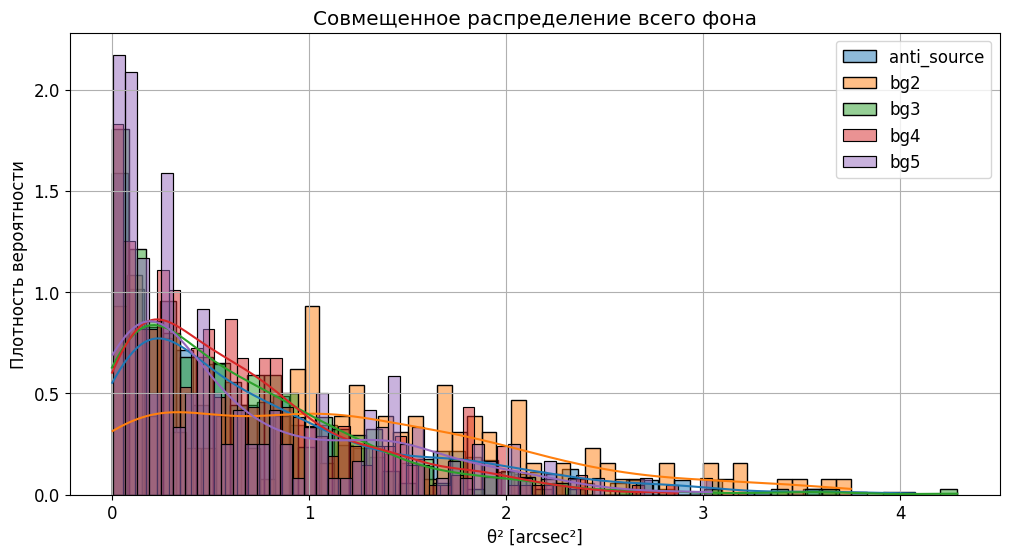

In [41]:
import seaborn as sns

# Собираем все данные в один DataFrame
all_data = pd.DataFrame()

# Добавляем антиисточник (если у него есть theta2)
if 'dist2_theta2' in anti_source_processed.columns:
    all_data['anti_source'] = anti_source_processed['dist2_theta2']

# Добавляем фоновые точки
for i, bg_df in enumerate([bg2_processed, bg3_processed, bg4_processed, bg5_processed], 2):
    col_name = f'bg{i}_theta2'
    if col_name in bg_df.columns:
        all_data[f'bg{i}'] = bg_df[col_name]

# Построение гистограмм
plt.figure(figsize=(12, 6))

# Гистограмма для каждого набора данных
for column in all_data.columns:
    sns.histplot(all_data[column], 
                 bins=50, 
                 alpha=0.5, 
                 label=column,
                 kde=True,
                 stat='density')

plt.title('Совмещенное распределение всего фона')
plt.xlabel('θ² [arcsec²]')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True)
plt.savefig('Mrk 501 researches/distr_bg.png', dpi=300, bbox_inches='tight')
plt.show()

### 5 точек фона и источник

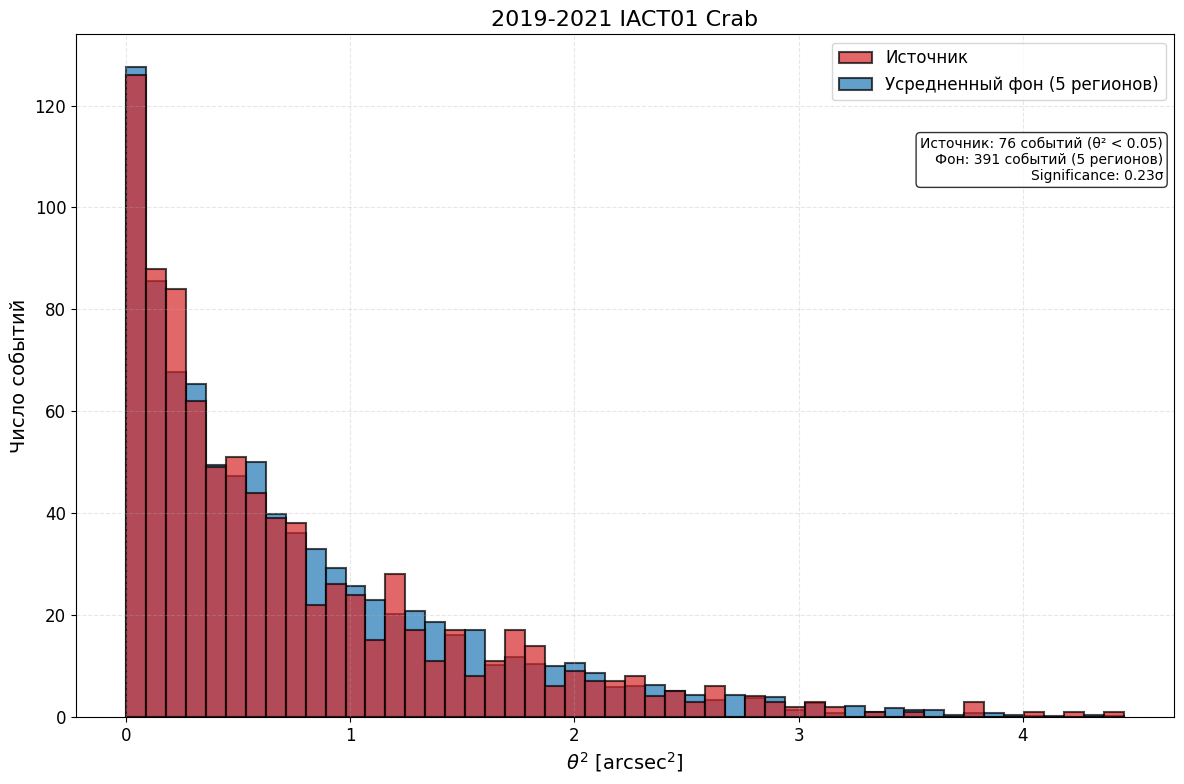

In [42]:
def plot_combined_with_averaged_background(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, bins=40, theta_cut=None):
    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.rcParams['font.size'] = 12

    # Собираем все фоновые данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna(),
        bg5_df['bg5_theta2'].dropna()
    ]

    # Данные источника
    source_data = source_df['source_theta2'].dropna()

    # Параметры гистограмм
    hist_kwargs = {
        'alpha': 0.7,
        'linewidth': 1.5,
        'edgecolor': 'k'
    }

    # Общие бины для всех гистограмм
    bin_edges = np.linspace(0, max(source_data.max(), max(bg.max() for bg in background_dfs)), bins+1)
    
    # Гистограмма источника (для визуализации)
    source_hist, _ = np.histogram(source_data, bins=bin_edges)
    
    # Усредненная гистограмма фона (только для визуализации)
    background_hists = [np.histogram(bg, bins=bin_edges)[0] for bg in background_dfs]
    background_hist_avg = np.mean(background_hists, axis=0)
    # print(background_hist_avg)

    # Визуализация
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    plt.bar(bin_centers, background_hist_avg, width=np.diff(bin_edges), 
            color='#1f77b4', label='Усредненный фон (5 регионов)', **hist_kwargs)
    plt.hist(source_data, bins=bin_edges, color='#d62728', label='Источник', **hist_kwargs)

    ### Исправленный расчет значимости ###
    N_on = np.sum(source_data < theta_cut)
    
    # Суммируем все фоновые события до усреднения!
    N_off_total = sum(np.sum(bg < theta_cut) for bg in background_dfs)
    alpha = 1/5 
    
    # Формула Ли-Ма 
    term1 = N_on * np.log((1 + alpha)/alpha * (N_on/(N_on + N_off_total)))
    term2 = N_off_total * np.log((1 + alpha) * (N_off_total/(N_on + N_off_total)))
    S = np.sqrt(2 * (term1 + term2)) 
    S = round(S, 2)

    # Добавляем статистику
    stats_text = "\n".join([
        f"Источник: {N_on} событий (θ² < {theta_cut})",
        f"Фон: {N_off_total} событий (5 регионов)",
        f"Significance: {S}σ"
    ])

    plt.annotate(stats_text, xy=(0.99, 0.85), xycoords='axes fraction',
                ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.xlabel(r'$\theta^2$ [arcsec$^2$]', fontsize=14)
    plt.ylabel('Число событий', fontsize=14)
    plt.title('2019-2021 IACT01 Crab', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)
    # plt.yscale('log')
    plt.tight_layout()
    plt.savefig('Mrk_501_researches/5point_teta_2022-2024_IACT03.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_combined_with_averaged_background(
    source_processed,
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed,
    bins=50,
    theta_cut=0.05 
)

### Разница N_on and N_off

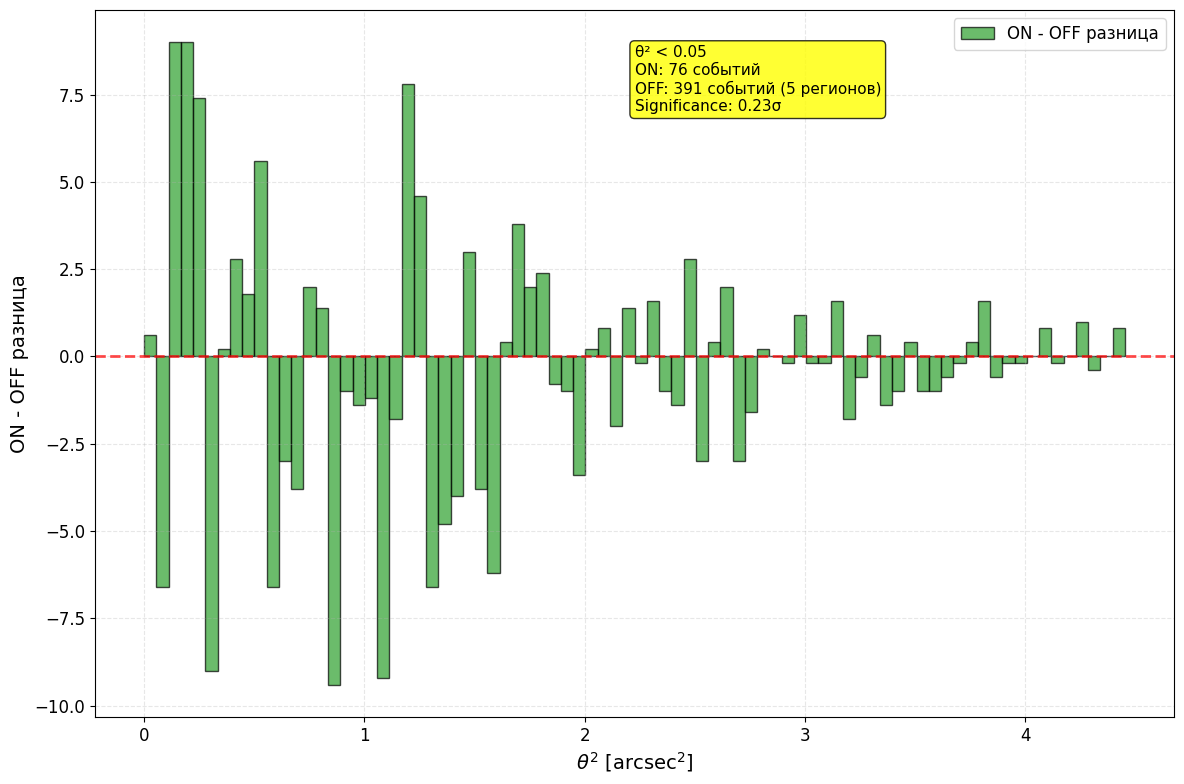

In [43]:
def plot_on_off_difference(source_df, anti_source_df, bg2_df, bg3_df, bg4_df, bg5_df, bins=40, theta_cut=None):
    plt.figure(figsize=(12, 8))
    plt.style.use('default')
    plt.rcParams['font.size'] = 12

    # Собираем все фоновые данные
    background_dfs = [
        anti_source_df['dist2_theta2'].dropna(),
        bg2_df['bg2_theta2'].dropna(),
        bg3_df['bg3_theta2'].dropna(),
        bg4_df['bg4_theta2'].dropna(),
        bg5_df['bg5_theta2'].dropna()
    ]

    # Данные источника
    source_data = source_df['source_theta2'].dropna()

    # Общие бины для всех гистограмм
    bin_edges = np.linspace(0, max(source_data.max(), max(bg.max() for bg in background_dfs)), bins+1)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    bin_width = np.diff(bin_edges)[0]
    
    # Гистограмма ON-региона (источник)
    on_hist, _ = np.histogram(source_data, bins=bin_edges)
    
    # Гистограммы OFF-регионов (фоны)
    off_hists = [np.histogram(bg, bins=bin_edges)[0] for bg in background_dfs]
    off_hist_avg = np.mean(off_hists, axis=0)
    
    # Разница ON - OFF (нормированная)
    # alpha = 1.0 / len(background_dfs)  # Коэффициент нормировки
    difference_hist = on_hist - off_hist_avg

    # Визуализация разницы ON-OFF
    plt.bar(bin_centers, difference_hist, width=bin_width, 
            color='#2ca02c', alpha=0.7, label='ON - OFF разница',
            edgecolor='k', linewidth=1)

    # Линия нуля для reference
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
    # ПРАВИЛЬНЫЙ расчет N_on и N_off (как в исходном коде)
    if theta_cut is not None:
        N_on = np.sum(source_data < theta_cut)  # События источника до theta_cut
        
        # Суммируем все фоновые события до theta_cut (как в исходном коде)
        N_off_total = sum(np.sum(bg < theta_cut) for bg in background_dfs)
        alpha_total = 1/len(background_dfs)
        
        # Формула Ли-Ма
        term1 = N_on * np.log((1 + alpha_total)/alpha_total * (N_on/(N_on + N_off_total)))
        term2 = N_off_total * np.log((1 + alpha_total) * (N_off_total/(N_on + N_off_total)))
        S = np.sqrt(2 * (term1 + term2)) 
        S = round(S, 2)
        
        stats_text = "\n".join([
            f"θ² < {theta_cut}",
            f"ON: {N_on} событий",
            f"OFF: {N_off_total} событий (5 регионов)",
            f"Significance: {S}σ"
        ])
        
        plt.annotate(stats_text, xy=(0.5, 0.95), xycoords='axes fraction',
                    ha='left', va='top', fontsize=11,
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

    plt.xlabel(r'$\theta^2$ [arcsec$^2$]', fontsize=14)
    plt.ylabel('ON - OFF разница', fontsize=14)
    # plt.title('23.11.19 IACT01 Crab', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(fontsize=12)

    plt.ylim()
    
    plt.tight_layout()
    plt.savefig('Mrk_501_researches/5point_teta_2022-2024_IACT03.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Дополнительно: возвращаем данные для анализа
    return {
        'bin_centers': bin_centers,
        'bin_edges': bin_edges,
        'on_hist': on_hist,
        'off_hist_avg': off_hist_avg,
        'difference_hist': difference_hist,
        'N_on': N_on if theta_cut else None,
        'N_off_total': N_off_total if theta_cut else None,
        'significance': S if theta_cut else None
    }

# Вызов функции для построения графика разницы
result = plot_on_off_difference(
    source_processed,
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed,
    bins=80,
    theta_cut=0.05 
)

In [26]:
exp_data = source_processed[source_processed.source_theta2<0.05]

## Эффективная площадь

### Моделирование (один файл)

In [20]:
# с хилласом (триггер телескопа) сейчас 607 
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_hillas_iact01_14_7fix_cb0.csv' # 607
# file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599_old/taiga599_hillas_iact01_14.0_7.0fix_cb0.csv' # Razumov
# file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv' # 599
sim_hill_599 = pd.read_csv(file_simulation)
# изначальное моделирование
# file_sim = '/home/alexandra/Desktop/TAIGA/taiga599_A_sums2' # 599
# # file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599_old/taiga599_A_sums' # 599 Razumov
file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_A_sums2' # 607
sim_all_599 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_599 = sim_all_599.iloc[::5]

# sim_all_599

In [15]:

file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599_old/taiga599_A_sums2' # 599 Razumov

# Читаем файл, пропуская первые 2 строки
sim_all_599 = pd.read_csv(file_sim, delim_whitespace=True, skiprows=2, header=None,
                 names=['A', 'x1', 'xtel', 'ytel', 'dist', 'A1', 'N_b_f', 'col7', 'col8', 'col9', 'E_sim'])

sim_all_599 = sim_all_599.iloc[::5]
sim_all_599

/tmp/ipykernel_4966/1436423744.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sim_all_599 = pd.read_csv(file_sim, delim_whitespace=True, skiprows=2, header=None,


,A,x1,xtel,ytel,dist,A1,N_b_f,col7,col8,col9,E_sim
0,888.892653,-3.51,534.416625,457.058225,439.579895,26.482924,7,-4.741799e-07,4.180695e-09,182.74090,2.151626
5,169.274424,-3.51,-289.263625,396.712574,396.629972,6.517722,0,NaN,NaN,41.08464,2.151626
10,883.008460,-3.51,474.001531,398.761218,381.694694,31.779906,0,NaN,NaN,246.03450,2.151626
15,751.223137,-3.51,547.728187,469.975031,452.394578,25.785505,7,-3.014739e-07,5.640862e-09,205.82020,2.151626
20,396.788584,-3.51,691.912375,610.970261,592.100261,15.355543,1,-4.412019e-07,0.000000e+00,135.36810,2.151626
...,...,...,...,...,...,...,...,...,...,...,...
1999375,995.510228,-3.51,-381.340250,485.737850,483.791812,35.086927,8,-2.305515e-06,7.316976e-09,244.93280,2.170609
1999380,457.484037,-3.51,-539.170250,640.348056,639.210059,12.681667,3,-2.580474e-06,7.638555e-09,98.48650,2.170609
1999385,278.155193,-3.51,-520.226875,621.705688,620.494228,8.030977,2,-2.535573e-06,6.752764e-09,54.57752,2.170609
1999390,247.301242,-3.51,931.244438,847.381508,842.869938,8.477879,3,1.095788e-07,2.690235e-12,82.65693,2.170609


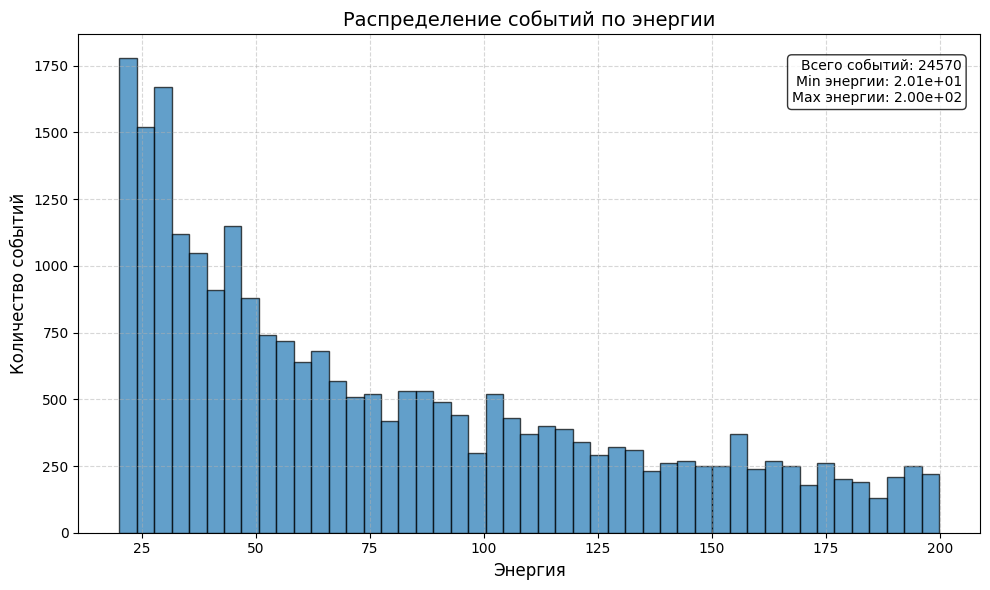

In [21]:
# проверка диапазона по энергии
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_all_599['E_sim'].min()
energy_max = sim_all_599['E_sim'].max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_all_599['E_sim'], bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_all_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

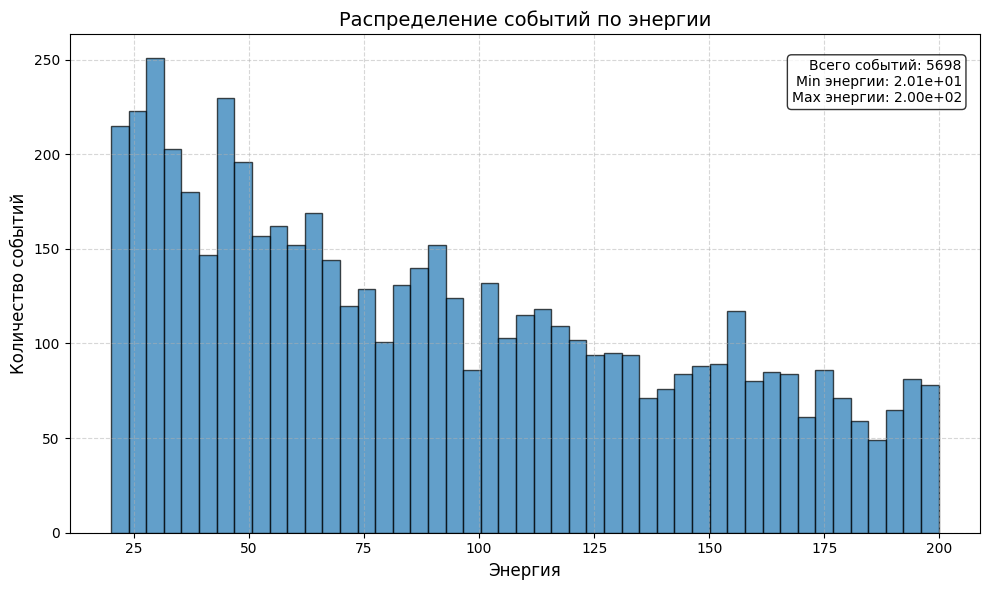

In [22]:
# проверка диапазона по энергии из телескопа
plt.figure(figsize=(10, 6))

# Определяем диапазон и количество бинов
energy_min = sim_hill_599.energy.min()
energy_max = sim_hill_599.energy.max()
bins = np.linspace(energy_min, energy_max, 48) 

plt.hist(sim_hill_599.energy, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Энергия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.title('Распределение событий по энергии', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Добавляем информацию о статистике
stats_text = f"Всего событий: {len(sim_hill_599)}\nMin энергии: {energy_min:.2e}\nMax энергии: {energy_max:.2e}"
plt.annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [23]:
def filter_hillas_data(df):
    common_filters = (
        (df['size'] > 120) &
        # (df['edge'] == 0) &
        (df['width[0]'] > 0.024) &
        (df['width[0]'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length[0]'] < 0.145 * np.log10(df['size']))
        # (df['skewness_l'] > 1.15*np.log10(df['size'])-2.85)
        
    )
    
    source_df = df[
        common_filters &
        (df['dist[1]'].between(0.36, 1.3))
    ]
    
    return source_df

sim_hill_selected_599 = filter_hillas_data(sim_hill_599)
sim_hill_selected_599

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
15,15,7,8,9,21.8716,564.941,-0.281732,1.364420,0.592062,0.339816,...,0.862741,-169.4440,-95.0479,0.611931,5.68603,0.596712,-0.570947,380.734,1,1.0
18,18,10,0,34,110.3450,6887.600,0.370652,0.058827,0.662588,0.486149,...,0.862740,104.6000,-12.1880,0.597300,6.64991,0.582076,0.393503,430.012,1,1.0
44,44,21,9,9,26.1397,595.995,0.456772,-0.202947,0.443302,0.392418,...,0.862748,187.8000,-105.5590,0.609325,6.06260,0.594105,-0.194277,349.541,1,1.0
72,72,36,0,14,83.6234,1751.120,-0.052482,0.208553,0.610043,0.384303,...,0.862684,23.8697,-215.7180,0.697148,5.64082,0.681955,-0.618907,328.903,1,1.0
74,74,36,4,14,83.6234,2780.990,1.636240,0.273651,0.609552,0.355917,...,0.862684,195.9590,23.8640,0.697148,5.64082,0.681955,-0.618907,328.903,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5675,5675,2450,8,33,151.0520,7736.760,1.392090,0.003370,0.670568,0.431882,...,0.862759,131.7170,56.9364,0.613315,6.25797,0.598096,0.000953,400.854,1,1.0
5679,5679,2452,6,8,21.9253,620.102,0.611821,0.369915,0.810878,0.290046,...,0.862686,88.1806,-22.4107,0.654194,6.36969,0.638989,0.111253,338.686,1,1.0
5684,5684,2454,4,23,82.5137,4095.040,0.003274,0.417544,0.508233,0.386488,...,0.862780,-19.2334,-121.7420,0.599333,5.54608,0.584109,-0.710407,410.688,1,1.0
5685,5685,2454,6,24,82.5137,4310.520,1.632930,1.464600,0.668070,0.390866,...,0.862780,1.0878,115.2360,0.599333,5.54608,0.584109,-0.710407,410.688,1,1.0


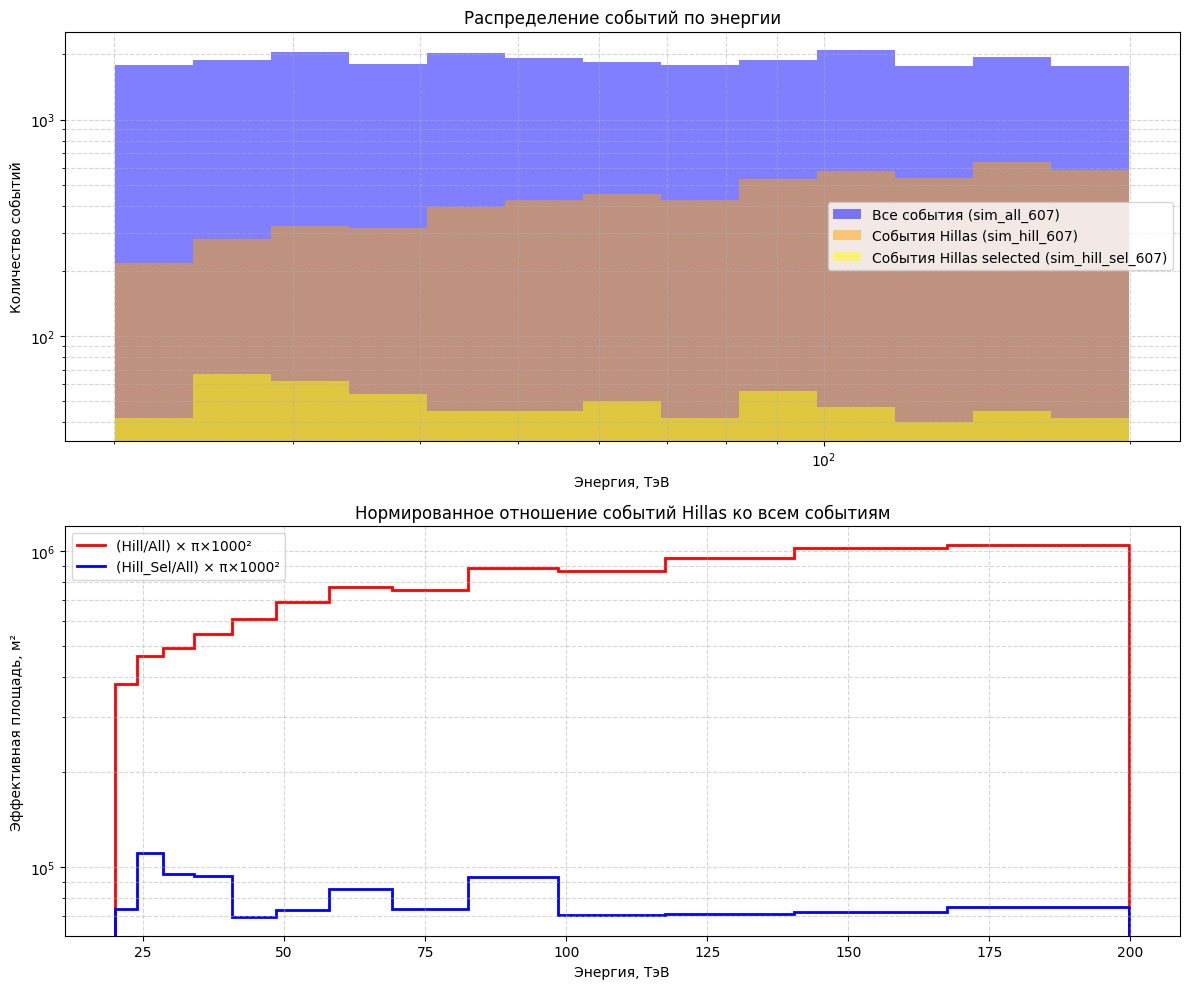

In [24]:
# без косинуса зенитного угла
df_all = sim_all_599 
df_hill = sim_hill_599 
df_hill_sel = sim_hill_selected_599

# Определение диапазона энергий (логарифмические бины)
energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 14)  # логарифмических бинов

# Расчет гистограмм
hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
hist_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges)
hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges)

# Отношение (Hill/All) * площадь круга (R=1000 м)
area_circle = np.pi * 1000**2
# ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
# ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
ratio = hist_hill / hist_all * area_circle
ratio_sel = hist_hill_sel / hist_all * area_circle

# Построение графиков
plt.figure(figsize=(12, 10))

# 1. Распределения по энергии
plt.subplot(2, 1, 1)
plt.stairs(hist_all, bin_edges, label='Все события (sim_all_607)', fill=True, alpha=0.5, color='blue')
plt.stairs(hist_hill, bin_edges, label='События Hillas (sim_hill_607)', fill=True, alpha=0.5, color='orange')
plt.stairs(hist_hill_sel, bin_edges, label='События Hillas selected (sim_hill_sel_607)', fill=True, alpha=0.5, color='yellow')
plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Количество событий')
plt.title('Распределение событий по энергии')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# 2. Отношение 
plt.subplot(2, 1, 2)
plt.stairs(ratio, bin_edges, label='(Hill/All) × π×1000²', color='red', linewidth=2)
plt.stairs(ratio_sel, bin_edges, label='(Hill_Sel/All) × π×1000²', color='blue', linewidth=2)
# plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Эффективная площадь, м²')
plt.title('Нормированное отношение событий Hillas ко всем событиям')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayeff_sq_all_607.png', dpi=300, bbox_inches='tight')
plt.show()

### с поправкой на косинус на зенитный угол

In [33]:
# df_all = sim_all_599 
# df_hill = sim_hill_599 
# df_hill_sel = sim_hill_selected_599

# # Определение диапазона энергий (логарифмические бины)
# energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
# energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
# bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)  # 20 логарифмических бинов

# # Расчет гистограмм
# hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
# hist_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges)
# hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges)

# # Расчет среднего косинуса угла по бинам энергии
# cos_tel_tet_hill, _ = np.histogram(df_hill['energy'], bins=bin_edges, weights=np.cos(df_hill.tel_tet))
# cos_tel_tet_hill_avg = cos_tel_tet_hill / np.where(hist_hill == 0, 1, hist_hill)

# cos_tel_tet_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bin_edges, weights=np.cos(df_hill_sel.tel_tet))
# cos_tel_tet_hill_sel_avg = cos_tel_tet_hill_sel / np.where(hist_hill_sel == 0, 1, hist_hill_sel)

# # Отношение (Hill/All) * площадь круга (R=1000 м) * косинус угла
# area_circle = np.pi * 1000**2
# ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle * cos_tel_tet_hill_avg
# ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle * cos_tel_tet_hill_sel_avg

# # Построение графиков
# plt.figure(figsize=(12, 10))

# # 1. Распределения по энергии
# plt.subplot(2, 1, 1)
# plt.stairs(hist_all, bin_edges, label='Все события (sim_all_607)', fill=True, alpha=0.5, color='blue')
# plt.stairs(hist_hill, bin_edges, label='События Hillas (sim_hill_607)', fill=True, alpha=0.5, color='orange')
# plt.stairs(hist_hill_sel, bin_edges, label='События Hillas selected (sim_hill_sel_607)', fill=True, alpha=0.5, color='yellow')
# plt.xscale('log')
# plt.yscale('log')  
# plt.xlabel('Энергия, ТэВ')
# plt.ylabel('Количество событий')
# plt.title('Распределение событий по энергии')
# plt.legend()
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# # 2. Отношение 
# plt.subplot(2, 1, 2)
# plt.stairs(ratio, bin_edges, label='(Hill/All) × π×1000² × cos(θ)', color='red', linewidth=2)
# plt.stairs(ratio_sel, bin_edges, label='(Hill_Sel/All) × π×1000² × cos(θ)', color='blue', linewidth=2)
# # plt.xscale('log')
# plt.yscale('log')  
# plt.xlabel('Энергия, ТэВ')
# plt.ylabel('Эффективная площадь, м²')
# plt.title('Нормированное отношение событий Hillas ко всем событиям')
# plt.legend()
# plt.grid(True, which='both', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.savefig('eff_sq_all_607.png', dpi=300, bbox_inches='tight')
# plt.show()

### Реконструкция по энергии

### Cчитываем данные моделирования

### Отбираем данные (каты Хилласа)

In [34]:
# объединим моделирование 599 и 607
#607
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_hillas_iact01_14_7fix_cb0.csv' # 607
sim_hill_607 = pd.read_csv(file_simulation)
file_sim = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_607/taiga607_A_sums2' # 607
sim_all_607 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_607 = sim_all_607.iloc[::5]
#599
file_simulation = '/media/alexandra/DATA/IACT01_2020-2021/Simulation_599/taiga599_hillas_iact01_14_7fix_cb0.csv' # 599
sim_hill_599 = pd.read_csv(file_simulation)
file_sim = '/home/alexandra/Desktop/TAIGA/taiga599_A_sums2' # 599
sim_all_599 = pd.read_csv(
    file_sim,
    comment='#',          # Игнорировать строки, начинающиеся с #
    sep=r'\s+',           # Разделитель — любой количество пробелов
    header=None,          # Нет заголовка в файле
    skiprows=2,           # Пропустить первые 2 строки (заголовки)
    engine='python',
    names=['A', 'xtet', 'ytet', 'dist', 'AI', 'N_b_f', 'col7', 'col8', 'col9', 'col10', 'E_sim']
)
sim_all_599 = sim_all_599.iloc[::5]

df_all = pd.concat([sim_all_599, sim_all_607], ignore_index=True)
df_hill = pd.concat([sim_hill_599, sim_hill_607], ignore_index=True)

def filter_data(df):
    common_filters = (
        (df['size'] > 120) &
        # (df['edge'] == 0) &
        (df['width[0]'] > 0.024) &
        (df['width[0]'] < 0.068 * np.log10(df['size']) - 0.047) &
        (df['length[0]'] < 0.145 * np.log10(df['size']))
        # (df['skewness_l'] > 1.15*np.log10(df['size'])-2.85)
    )
    
    source_df = df[
        common_filters &
        (df['dist[1]'].between(0.36, 1.3))
    ]
    return source_df

df_hill_sel = filter_data(df_hill)

df_hill_sel

,clean_number,event_number,axis_scatter,numb_pix,energy,size,Xc[0],Yc[0],con2,length[0],...,source_y,x_ground,y_ground,tel_tet,tel_fi,source_tet,source_fi,Xmax,num_islands,con_selected_island
0,0,2,5,4,11.64790,191.260,0.043715,0.323091,0.772252,0.259698,...,0.862666,0.964031,215.5410,0.699570,2.41686,0.684378,2.440250,305.978,1,1.0
5,5,31,5,10,19.41840,856.251,0.930775,0.295348,0.542173,0.308242,...,0.862707,-61.919300,12.8512,0.662259,2.84144,0.647056,2.865930,391.042,1,1.0
10,10,51,8,6,5.82574,242.744,0.071497,0.255769,0.677644,0.317929,...,0.862785,-103.186000,123.7240,0.602435,3.08244,0.587212,3.109010,435.000,1,1.0
22,22,98,5,7,20.65240,557.898,-0.003442,1.479900,0.581513,0.329450,...,0.862786,120.277000,138.6370,0.587970,3.09875,0.572742,3.125900,343.661,1,1.0
23,23,98,6,8,20.65240,423.841,-0.270941,0.885689,0.612154,0.310477,...,0.862786,1.972700,188.5640,0.587970,3.09875,0.572742,3.125900,343.661,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14323,5675,2450,8,33,151.05200,7736.760,1.392090,0.003370,0.670568,0.431882,...,0.862759,131.717000,56.9364,0.613315,6.25797,0.598096,0.000953,400.854,1,1.0
14327,5679,2452,6,8,21.92530,620.102,0.611821,0.369915,0.810878,0.290046,...,0.862686,88.180600,-22.4107,0.654194,6.36969,0.638989,0.111253,338.686,1,1.0
14332,5684,2454,4,23,82.51370,4095.040,0.003274,0.417544,0.508233,0.386488,...,0.862780,-19.233400,-121.7420,0.599333,5.54608,0.584109,-0.710407,410.688,1,1.0
14333,5685,2454,6,24,82.51370,4310.520,1.632930,1.464600,0.668070,0.390866,...,0.862780,1.087800,115.2360,0.599333,5.54608,0.584109,-0.710407,410.688,1,1.0


### Check disp

In [35]:
# Calculate disp according Sveshnikova ksi
df_hill_sel['rc'] = df_hill_sel['dist[1]'] / 0.1206
df_hill_sel['ksi'] = df_hill_sel.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
df_hill_sel = df_hill_sel[~df_hill_sel['ksi'].isna()]  # Remove NaN values
df_hill_sel['disp'] = df_hill_sel['ksi'] * (1.0 - df_hill_sel['width[0]'] / df_hill_sel['length[0]'])
# df_hill_sel[df_hill_sel['alpha[1]']]

/tmp/ipykernel_6283/1329723288.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['rc'] = df_hill_sel['dist[1]'] / 0.1206
/tmp/ipykernel_6283/1329723288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['ksi'] = df_hill_sel.apply(lambda row: calculate_ksi(row['rc'], row['size']), axis=1)
/tmp/ipykernel_6283/1329723288.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

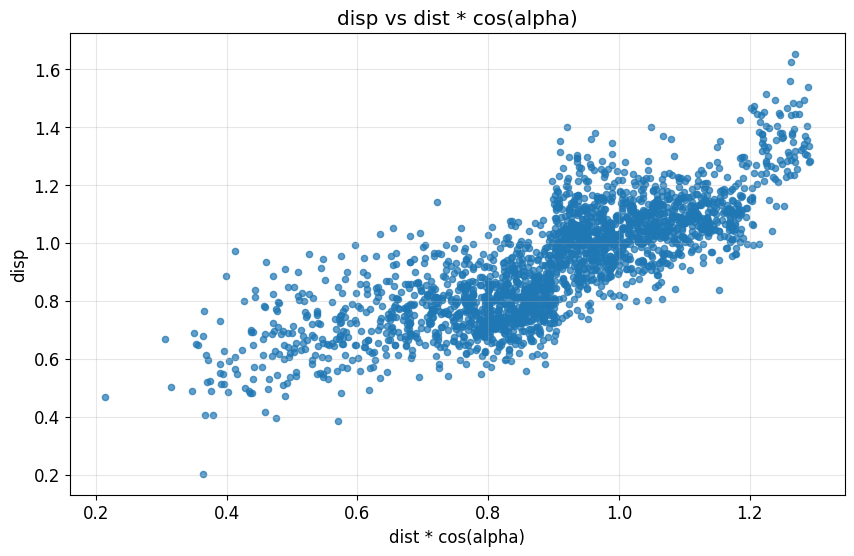

In [37]:
x_values = df_hill_sel['dist[1]'] * np.cos(np.radians(df_hill_sel['alpha[1]']))
y_values = df_hill_sel['disp']

# Построение графика
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.7, s=20)
plt.xlabel('dist * cos(alpha)')
plt.ylabel('disp')
plt.title('disp vs dist * cos(alpha)')
plt.grid(True, alpha=0.3)
plt.show()

### Восстанавливаем энергию по моделированию: получаем коэфф a и b

/tmp/ipykernel_6283/4126968467.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['dist_group'] = pd.cut(df_hill_sel['dist[1]'], bins=bins)
/tmp/ipykernel_6283/4126968467.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['reconstructed_energy'] = df_hill_sel.apply(reconstruct_energy, axis=1)


2312
Средняя ошибка реконструкции: 20.53%


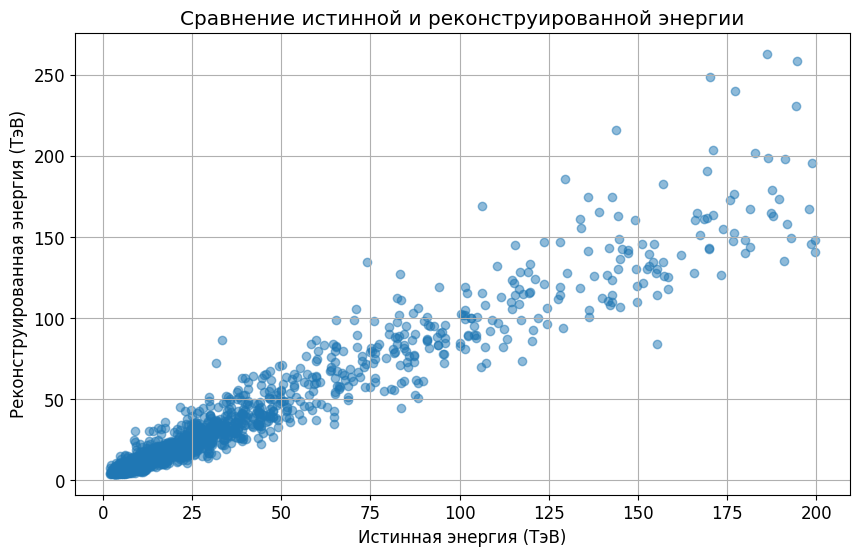

,event_number,energy,size,dist[0],dist_group,reconstructed_energy
0,2,11.64790,191.260,0.326035,"(0.72, 1.08]",5.779584
5,31,19.41840,856.251,0.976510,"(0.36, 0.72]",23.509787
10,51,5.82574,242.744,0.265574,"(0.72, 1.08]",7.115570
22,98,20.65240,557.898,1.479900,"(0.72, 1.08]",14.706020
23,98,20.65240,423.841,0.926204,"(1.08, 1.44]",15.848446
25,100,6.11845,135.324,0.890539,"(0.36, 0.72]",4.622935
27,118,9.75402,179.701,1.912580,"(1.08, 1.44]",8.491672
35,166,5.13466,199.920,0.568618,"(0.72, 1.08]",6.007232
37,170,9.58613,268.075,1.247690,"(0.36, 0.72]",8.445732
42,192,22.38020,616.074,1.846130,"(1.08, 1.44]",20.802043


In [38]:
# Разбиваем с шагом 0.36°
step = 0.36
min_val, max_val = 0.36, 1.44  

bins = np.arange(min_val, max_val + step, step)

df_hill_sel['dist_group'] = pd.cut(df_hill_sel['dist[1]'], bins=bins)

# Функция для фитирования
def energy_fit(x, a, b):
    return a + b * np.log10(x)

# Вычисление коэффициентов для каждой группы
coefficients = {}
for group in df_hill_sel['dist_group'].unique():
    group_data = df_hill_sel[df_hill_sel['dist_group'] == group]
    # print(group_data)
    popt, _ = curve_fit(energy_fit, group_data['size'], np.log10(group_data['energy']))
    coefficients[group] = {'a': popt[0], 'b': popt[1]}

# Восстановление энергии
def reconstruct_energy(row):
    coeff = coefficients[row['dist_group']]
    return 10**(coeff['a'] + coeff['b'] * np.log10(row['size']))

df_hill_sel['reconstructed_energy'] = df_hill_sel.apply(reconstruct_energy, axis=1)

# Проверка точности реконструкции 
valid_events = df_hill_sel.dropna(subset=['reconstructed_energy', 'energy'])
reconstruction_error = np.abs(valid_events['reconstructed_energy'] - valid_events['energy']) / valid_events['energy']
print(len(reconstruction_error))
print(f"Средняя ошибка реконструкции: {np.mean(reconstruction_error)*100:.2f}%")

plt.figure(figsize=(10, 6))
plt.scatter(valid_events['energy'], valid_events['reconstructed_energy'], alpha=0.5)
plt.xlabel('Истинная энергия (ТэВ)')
plt.ylabel('Реконструированная энергия (ТэВ)')
plt.title('Сравнение истинной и реконструированной энергии')
plt.grid(True)
plt.show()

df_hill_sel[['event_number', 'energy', 'size', 'dist[0]', 'dist_group', 'reconstructed_energy']].head(10)

### Восстанавливаем энергию в экспериментальных данных: для сигнала

/tmp/ipykernel_6283/2308681255.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_data['dist_group'] = pd.cut(exp_data['dist1'], bins=bins)
/tmp/ipykernel_6283/2308681255.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_data['reconstructed_energy'] = exp_data.apply(reconstruct_exp_energy, axis=1)


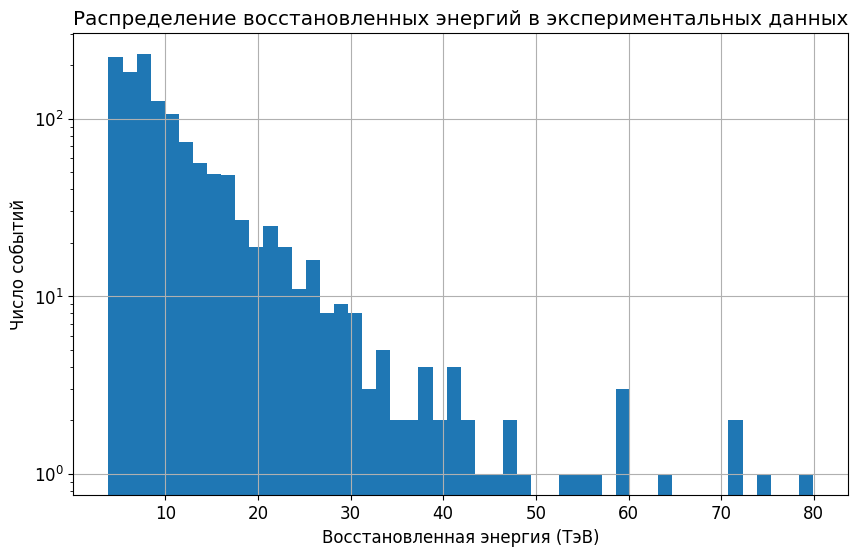

In [39]:
# Разбиваем экспериментальные данные на те же группы dist
exp_data['dist_group'] = pd.cut(exp_data['dist1'], bins=bins)

# Восстановление энергии с использованием ранее найденных коэффициентов
def reconstruct_exp_energy(row):
    coeff = coefficients[row['dist_group']]
    return 10**(coeff['a'] + coeff['b'] * np.log10(row['size']))

exp_data['reconstructed_energy'] = exp_data.apply(reconstruct_exp_energy, axis=1)

# Фильтрация и анализ результатов
valid_exp_events = exp_data.dropna(subset=['reconstructed_energy'])
# print(f"Успешно восстановлено энергий: {len(valid_exp_events)}/{len(exp_data)}")

# Визуализация распределения восстановленных энергий
plt.figure(figsize=(10, 6))
plt.hist(valid_exp_events['reconstructed_energy'], bins=50, log=True)
plt.xlabel('Восстановленная энергия (ТэВ)')
plt.ylabel('Число событий')
plt.title('Распределение восстановленных энергий в экспериментальных данных')
plt.grid(True)
plt.show()

### Для фона:

In [40]:
exp_data = source_processed[source_processed.source_theta2<0.05]
anti_source_processed = anti_source_processed[anti_source_processed.dist2_theta2<0.05]
bg2_processed = bg2_processed[bg2_processed.bg2_theta2<0.05]
bg3_processed = bg3_processed[bg3_processed.bg3_theta2<0.05]
bg4_processed = bg4_processed[bg4_processed.bg4_theta2<0.05]
bg5_processed = bg5_processed[bg5_processed.bg5_theta2<0.05]

/tmp/ipykernel_6283/106766022.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dist_group'] = pd.cut(df[dist_column], bins=bins)
/tmp/ipykernel_6283/106766022.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reconstructed_energy'] = df.apply(_reconstruct, axis=1)
/tmp/ipykernel_6283/106766022.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pa

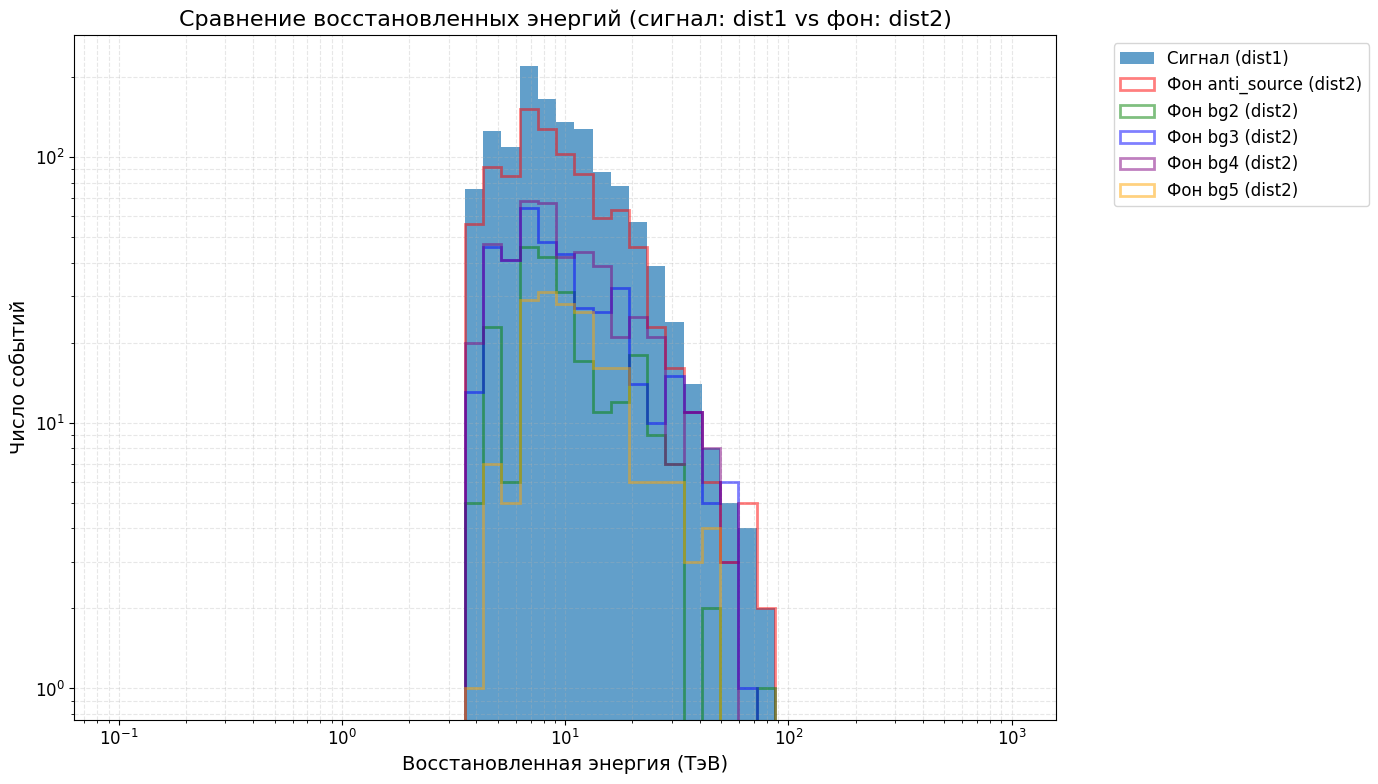

In [42]:
# Функция для восстановления энергии с указанием столбца расстояния
def reconstruct_energy(df, coefficients, dist_column='dist1', size_column='size'):
    # Разбиваем на группы расстояний
    df['dist_group'] = pd.cut(df[dist_column], bins=bins)
    
    # Восстановление энергии
    def _reconstruct(row):
        if pd.isna(row['dist_group']):
            return np.nan
        coeff = coefficients.get(row['dist_group'])
        if coeff is None:
            return np.nan
        return 10**(coeff['a'] + coeff['b'] * np.log10(row[size_column]))
    
    df['reconstructed_energy'] = df.apply(_reconstruct, axis=1)
    return df

# Восстановление энергии для сигнала (используем dist1)
exp_data = reconstruct_energy(exp_data, coefficients, dist_column='dist1') # signal

# Восстановление энергии для всех фоновых таблиц (используем dist2)
background_dfs = {
    'anti_source': anti_source_processed,
    'bg2': bg2_processed,
    'bg3': bg3_processed,
    'bg4': bg4_processed,
    'bg5': bg5_processed
}

for name, bg_df in background_dfs.items():
    background_dfs[name] = reconstruct_energy(bg_df, coefficients, dist_column='dist2')

# Визуализация распределения восстановленных энергий
plt.figure(figsize=(14, 8))

# Сигнал (dist1)
plt.hist(exp_data['reconstructed_energy'].dropna(), 
         bins=np.logspace(np.log10(0.1), np.log10(1000), 50),
         log=True, alpha=0.7, label='Сигнал (dist1)')

# Фон (dist2)
colors = ['red', 'green', 'blue', 'purple', 'orange']
for (name, bg_df), color in zip(background_dfs.items(), colors):
    plt.hist(bg_df['reconstructed_energy'].dropna(), 
             bins=np.logspace(np.log10(0.1), np.log10(1000), 50),
             log=True, alpha=0.5, histtype='step', linewidth=2,
             label=f'Фон {name} (dist2)', color=color)

plt.xscale('log')
plt.xlabel('Восстановленная энергия (ТэВ)', fontsize=14)
plt.ylabel('Число событий', fontsize=14)
plt.title('Сравнение восстановленных энергий (сигнал: dist1 vs фон: dist2)', fontsize=16)
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Обновляем фоновые таблицы
anti_source_processed = background_dfs['anti_source']
bg2_processed = background_dfs['bg2']
bg3_processed = background_dfs['bg3']
bg4_processed = background_dfs['bg4']
bg5_processed = background_dfs['bg5']

/tmp/ipykernel_6283/2535480100.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['dist_group'] = pd.cut(df_hill_sel['dist[1]'], bins=bins)
/tmp/ipykernel_6283/2535480100.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hill_sel['reconstructed_energy'] = df_hill_sel.apply(reconstruct_energy, axis=1)


2312
Средняя ошибка реконструкции: 20.53%


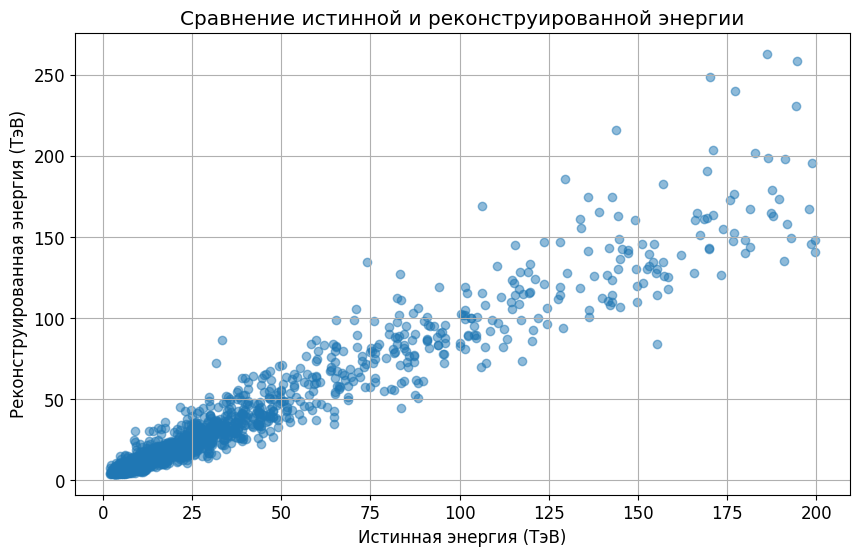

/tmp/ipykernel_6283/2535480100.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dist_group'] = pd.cut(df[dist_column], bins=bins)
/tmp/ipykernel_6283/2535480100.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reconstructed_energy'] = df.apply(_reconstruct, axis=1)


Обработан anti_source с использованием столбца bg1_dist
Обработан bg2 с использованием столбца bg2_dist
Обработан bg3 с использованием столбца bg3_dist
Обработан bg4 с использованием столбца bg4_dist
Обработан bg5 с использованием столбца bg5_dist


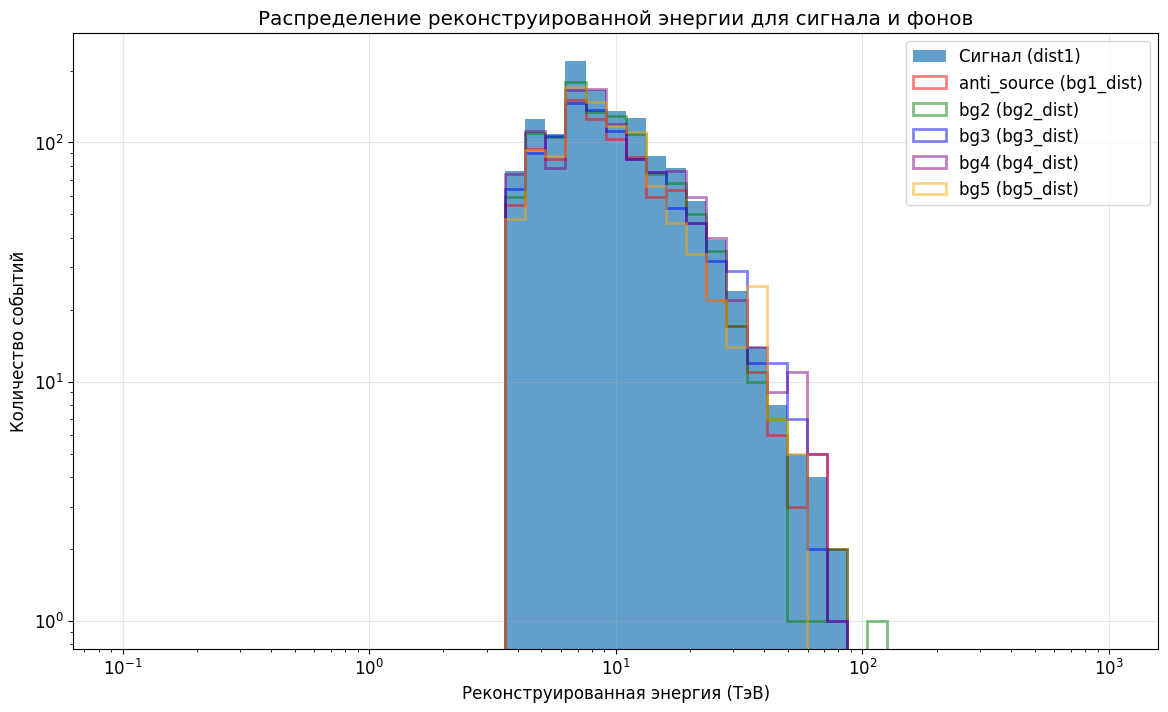

In [59]:
# new reconstruct energy with bg points
# Разбиваем с шагом 0.36°
step = 0.36
min_val, max_val = 0.36, 1.44  

bins = np.arange(min_val, max_val + step, step)

df_hill_sel['dist_group'] = pd.cut(df_hill_sel['dist[1]'], bins=bins)

# Функция для фитирования
def energy_fit(x, a, b):
    return a + b * np.log10(x)

# Вычисление коэффициентов для каждой группы
coefficients = {}
for group in df_hill_sel['dist_group'].unique():
    group_data = df_hill_sel[df_hill_sel['dist_group'] == group]
    # print(group_data)
    popt, _ = curve_fit(energy_fit, group_data['size'], np.log10(group_data['energy']))
    coefficients[group] = {'a': popt[0], 'b': popt[1]}

# Восстановление энергии
def reconstruct_energy(row):
    coeff = coefficients[row['dist_group']]
    return 10**(coeff['a'] + coeff['b'] * np.log10(row['size']))

df_hill_sel['reconstructed_energy'] = df_hill_sel.apply(reconstruct_energy, axis=1)

# Проверка точности реконструкции 
valid_events = df_hill_sel.dropna(subset=['reconstructed_energy', 'energy'])
reconstruction_error = np.abs(valid_events['reconstructed_energy'] - valid_events['energy']) / valid_events['energy']
print(len(reconstruction_error))
print(f"Средняя ошибка реконструкции: {np.mean(reconstruction_error)*100:.2f}%")

plt.figure(figsize=(10, 6))
plt.scatter(valid_events['energy'], valid_events['reconstructed_energy'], alpha=0.5)
plt.xlabel('Истинная энергия (ТэВ)')
plt.ylabel('Реконструированная энергия (ТэВ)')
plt.title('Сравнение истинной и реконструированной энергии')
plt.grid(True)
plt.show()

df_hill_sel[['event_number', 'energy', 'size', 'dist[0]', 'dist_group', 'reconstructed_energy']].head(10)
exp_data = source_processed[source_processed.source_theta2<0.05]
anti_source_processed = anti_source_processed[anti_source_processed.dist2_theta2<0.05]
bg2_processed = bg2_processed[bg2_processed.bg2_theta2<0.05]
bg3_processed = bg3_processed[bg3_processed.bg3_theta2<0.05]
bg4_processed = bg4_processed[bg4_processed.bg4_theta2<0.05]
bg5_processed = bg5_processed[bg5_processed.bg5_theta2<0.05]

# Функция для восстановления энергии с указанием столбца расстояния
def reconstruct_energy(df, coefficients, dist_column='dist1', size_column='size'):
    # Разбиваем на группы расстояний
    df['dist_group'] = pd.cut(df[dist_column], bins=bins)
    
    # Восстановление энергии
    def _reconstruct(row):
        if pd.isna(row['dist_group']):
            return np.nan
        coeff = coefficients.get(row['dist_group'])
        if coeff is None:
            return np.nan
        return 10**(coeff['a'] + coeff['b'] * np.log10(row[size_column]))
    
    df['reconstructed_energy'] = df.apply(_reconstruct, axis=1)
    return df

# Восстановление энергии для сигнала (используем dist1)
exp_data = reconstruct_energy(exp_data, coefficients, dist_column='dist1') # signal

# Словарь с соответствием: имя датасета -> столбец расстояния
background_config = {
    'anti_source': 'bg1_dist',    # для анти-источника используем bg1_dist
    'bg2': 'bg2_dist',             # для bg2 используем bg2_dist
    'bg3': 'bg3_dist',             # для bg3 используем bg3_dist
    'bg4': 'bg4_dist',             # для bg4 используем bg4_dist
    'bg5': 'bg5_dist'              # для bg5 используем bg5_dist
}

# Восстановление энергии для всех фоновых таблиц с правильными столбцами расстояния
background_dfs = {
    'anti_source': anti_source_processed,
    'bg2': bg2_processed,
    'bg3': bg3_processed,
    'bg4': bg4_processed,
    'bg5': bg5_processed
}

# Применяем реконструкцию для каждого фонового датасета со своим столбцом расстояния
for name, bg_df in background_dfs.items():
    dist_col = background_config[name]  # получаем правильный столбец для этого фона
    background_dfs[name] = reconstruct_energy(bg_df, coefficients, dist_column=dist_col)
    print(f"Обработан {name} с использованием столбца {dist_col}")

# Визуализация распределения восстановленных энергий
plt.figure(figsize=(14, 8))

# Сигнал (dist1)
plt.hist(exp_data['reconstructed_energy'].dropna(), 
         bins=np.logspace(np.log10(0.1), np.log10(1000), 50),
         log=True, alpha=0.7, label='Сигнал (dist1)')

# Фон с правильными столбцами расстояния
colors = ['red', 'green', 'blue', 'purple', 'orange']
labels = ['anti_source (bg1_dist)', 'bg2 (bg2_dist)', 'bg3 (bg3_dist)', 
          'bg4 (bg4_dist)', 'bg5 (bg5_dist)']

for (name, bg_df), color, label in zip(background_dfs.items(), colors, labels):
    plt.hist(bg_df['reconstructed_energy'].dropna(), 
             bins=np.logspace(np.log10(0.1), np.log10(1000), 50),
             log=True, alpha=0.5, histtype='step', linewidth=2,
             label=label, color=color)

plt.xlabel('Реконструированная энергия (ТэВ)')
plt.ylabel('Количество событий')
plt.title('Распределение реконструированной энергии для сигнала и фонов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.show()

### Строим спектр: без анфолдинга пока

In [60]:
bins = article_bins

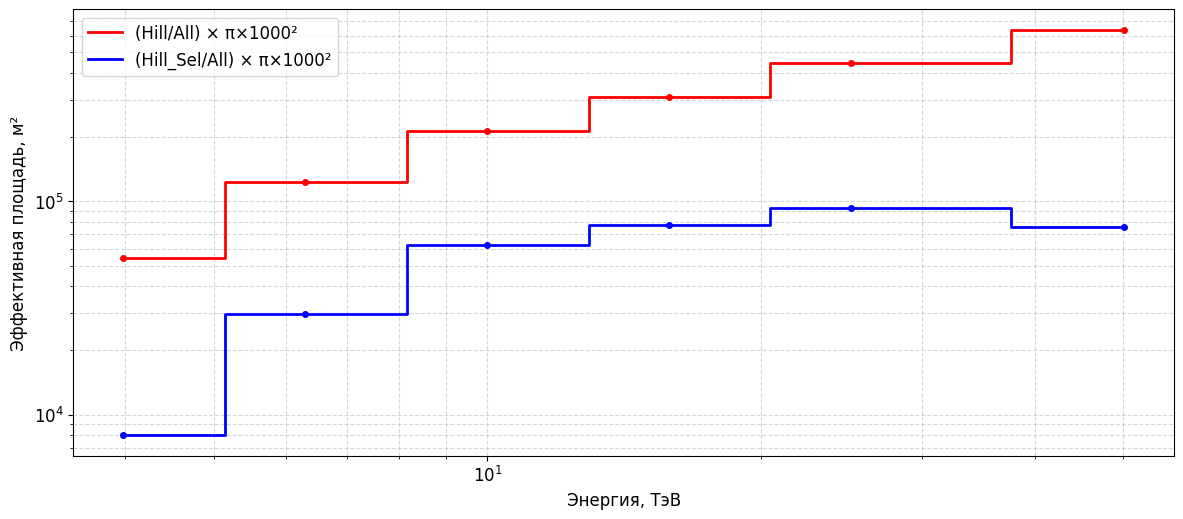

In [61]:
# energy_min = 1
# energy_max = 200
# bins = np.logspace(np.log10(energy_min), np.log10(energy_max),11)

# Расчет гистограмм (как у вас)
hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=bins)
hist_hill, _ = np.histogram(df_hill['energy'], bins=bins)
hist_hill_sel, _ = np.histogram(df_hill_sel['energy'], bins=bins)

# Отношение (Hill/All) * площадь круга (R=1000 м)
area_circle = np.pi * 1000**2
ratio = (hist_hill / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
ratio_sel = (hist_hill_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle

bin_centers = np.sqrt(bins[:-1] * bins[1:])  # Среднее геометрическое

plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 2)

# Вариант 1: where='mid' (ступенька центрирована)
plt.step(bin_centers, ratio, where='mid', 
         label='(Hill/All) × π×1000²', color='red', linewidth=2)
plt.step(bin_centers, ratio_sel, where='mid', 
         label='(Hill_Sel/All) × π×1000²', color='blue', linewidth=2)

# Вариант 2: where='post' (ступенька начинается в точке)
# plt.step(bin_centers, ratio, where='post', ...)

# Можно добавить точки для наглядности
plt.plot(bin_centers, ratio, 'ro', markersize=4)  # Красные точки
plt.plot(bin_centers, ratio_sel, 'bo', markersize=4)  # Синие точки

plt.xscale('log')
plt.yscale('log')  
plt.xlabel('Энергия, ТэВ')
plt.ylabel('Эффективная площадь, м²')
# plt.title('Нормированное отношение событий Hillas ко всем событиям')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayeff_sq_all_step.png', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
energy_bins = bins
energy_bins

array([ 3.16000009,  5.00829983,  7.93760014, 12.5802002 , 19.9382992 ,
       31.6000004 , 79.3700027 ])

In [63]:
eff_area = ratio_sel
eff_area

array([ 7995.86911533, 29717.76834477, 62622.23888307, 77837.31351023,
       93095.457978  , 75691.87779398])

ON: [185 396 346 200 110  38]
OFF (avg): [140.  318.  282.4 168.8  80.6  37.4]
Signal counts: [185 396 346 200 110  38]
Background counts (avg): [140.  318.  282.4 168.8  80.6  37.4]
Time [hours]: 285.1333333333333


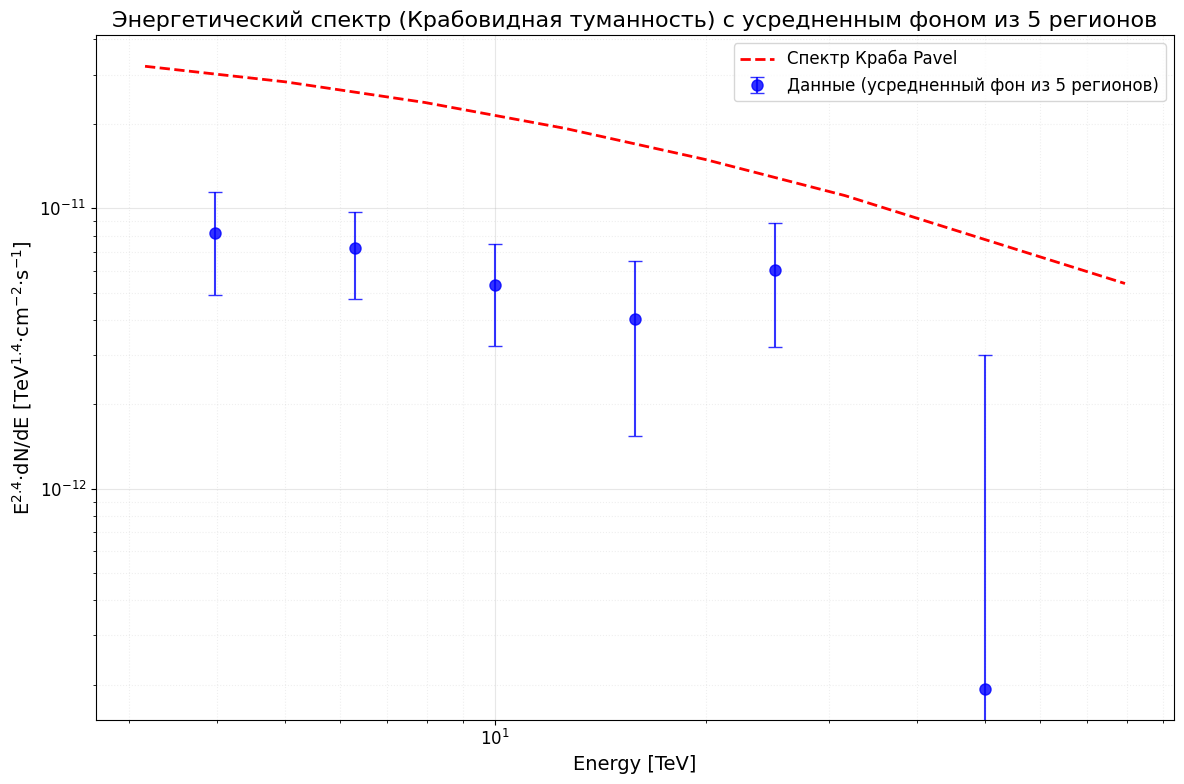

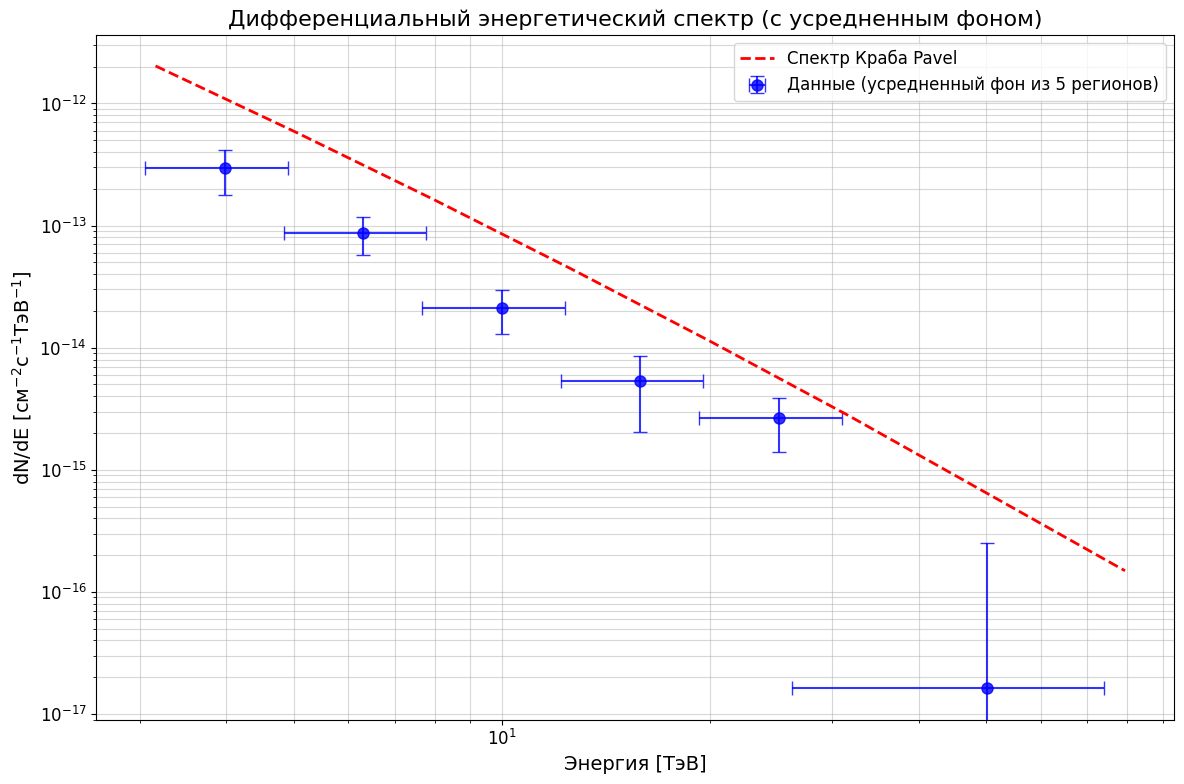


Анализ завершен!
Использовано фоновых регионов: 5
Время наблюдения: 285.1 часов = 1026480 секунд


In [64]:
# Функция для расчета спектра в формате E²·⁴·dN/dE с усредненным фоном
def calculate_spectrum_E24_dNdE_avg_background(source_data, background_dfs, energy_bins, eff_area, observation_time):
    # Число событий источника в бинах
    counts_on, bin_edges = np.histogram(source_data['reconstructed_energy'], bins=energy_bins)

    # Рассчитываем гистограммы для каждого фонового региона
    background_hists = []
    for bg_df in background_dfs:
        counts, _ = np.histogram(bg_df['reconstructed_energy'], bins=energy_bins)
        background_hists.append(counts)
    
    # Усредняем фон по регионам в каждом бине
    avg_background = np.mean(background_hists, axis=0)
    
    # Чистые сигнальные события (вычитание усредненного фона)
    signal_counts = counts_on - avg_background

    # Ширина бинов в лог шкале
    dE = np.diff(energy_bins)
    
    print('ON:', counts_on)
    print('OFF (avg):', avg_background)
    
    # Дифференциальный поток (dN/dE) в см⁻²с⁻¹ТэВ⁻¹
    flux = signal_counts / (eff_area * 10**4 * observation_time * dE)
    
    # Преобразование в E²·⁴·dN/dE
    # E должно быть в ТэВ, умножение на E²·⁴
    E_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])  # центры бинов в ТэВ
    E24_dNdE = flux * (E_centers**2.4)
    
    # Ошибки (учитываем статистику источника и разброс фона)
    flux_errors = np.sqrt(counts_on + avg_background) / (eff_area * 10**4 * observation_time * dE)
    E24_dNdE_errors = flux_errors * (E_centers**2.4)
    
    return E24_dNdE, E24_dNdE_errors, flux, flux_errors, avg_background, counts_on

# Функция для расчета эффективной площади
def calculate_effective_area(df_selected, df_all, energy_bins, R=1000):
    # Гистограммы для выбранных и всех событий
    hist_all, bin_edges = np.histogram(df_all['E_sim'], bins=energy_bins)
    hist_sel, _ = np.histogram(df_selected['energy'], bins=energy_bins)
    
    area_circle = np.pi * R**2
    effective_area = (hist_sel / np.where(hist_all == 0, 1e-10, hist_all)) * area_circle
    
    return effective_area

# Список фоновых данных
background_dfs = [
    anti_source_processed,
    bg2_processed,
    bg3_processed,
    bg4_processed,
    bg5_processed
]

# Расчет спектра в формате E²·⁴·dN/dE с усредненным фоном
E24_dNdE, E24_dNdE_errors, flux, flux_errors, avg_bg_counts, sg_counts = calculate_spectrum_E24_dNdE_avg_background(
    exp_data,
    background_dfs,
    energy_bins,
    ratio_sel,
    observation_time = time
)

print('Signal counts:', sg_counts)
print('Background counts (avg):', avg_bg_counts)
print('Time [hours]:', time/3600)

# Центры бинов для отображения
bin_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
bin_widths = energy_bins[1:] - energy_bins[:-1]
E = energy_bins

# График 2: E²·⁴·dN/dE с усредненным фоном
plt.figure(figsize=(12, 8))

# Данные эксперимента
plt.errorbar(bin_centers, E24_dNdE, 
            # xerr=bin_widths/2,
            yerr=E24_dNdE_errors,
            fmt='o', markersize=8, capsize=5, 
            label='Данные (усредненный фон из 5 регионов)',
            color='blue', alpha=0.8)

# 2. Спектр Краба Pavel в формате E²·⁴·dN/dE
E_ref = 7.0  # ТэВ
N0_pavel = 2.35e-13  # см⁻²с⁻¹ТэВ⁻¹ при 7 ТэВ
# Спектральная форма: E^(-2.79 - 0.1·ln(E/7))
E24_pavel = N0_pavel * ((E/E_ref)**(-2.79 - 0.1*np.log(E/E_ref))) * (E**2.4)
plt.plot(E, E24_pavel, 'r--', linewidth=2, 
         label='Спектр Краба Pavel')

# Настройки графика
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]', fontsize=14)
plt.ylabel('E$^{2.4}$·dN/dE [TeV$^{1.4}$·cm$^{-2}$·s$^{-1}$]', fontsize=14)
plt.title('Энергетический спектр (Крабовидная туманность) c усредненным фоном из 5 регионов', fontsize=16)
plt.legend(fontsize=12, loc='upper right')
plt.grid(which='both', alpha=0.5, linestyle='--')

# Установка пределов осей как на изображении
# plt.xlim(0.8, 200)
# plt.ylim(1e-17, 3e-10)

# Добавление сетки
plt.grid(True, which='major', linestyle='-', alpha=0.3)
plt.grid(True, which='minor', linestyle=':', alpha=0.2)

plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayspectr_Crab_E24_dNdE_avg_background.png', dpi=300, bbox_inches='tight')
plt.show()

# Дополнительный график: сравнение в обычных единицах
plt.figure(figsize=(12, 8))
plt.errorbar(bin_centers, flux, 
            xerr=bin_widths/2,
            yerr=flux_errors,
            fmt='o', markersize=8, capsize=5, 
            label='Данные (усредненный фон из 5 регионов)',
            color='blue', alpha=0.8)

plt.plot(energy_bins, 2.35e-13 * ((energy_bins/7)**(-2.79 - 0.1*np.log(energy_bins/7))), 'r--', 
         label='Спектр Краба Pavel', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Энергия [ТэВ]', fontsize=14)
plt.ylabel('dN/dE [см$^{-2}$с$^{-1}$ТэВ$^{-1}$]', fontsize=14)
plt.title('Дифференциальный энергетический спектр (с усредненным фоном)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', alpha=0.5)
plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayspectr_Crab_standard_avg_background.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nАнализ завершен!")
print(f"Использовано фоновых регионов: {len(background_dfs)}")
print(f"Время наблюдения: {time/3600:.1f} часов = {time:.0f} секунд")

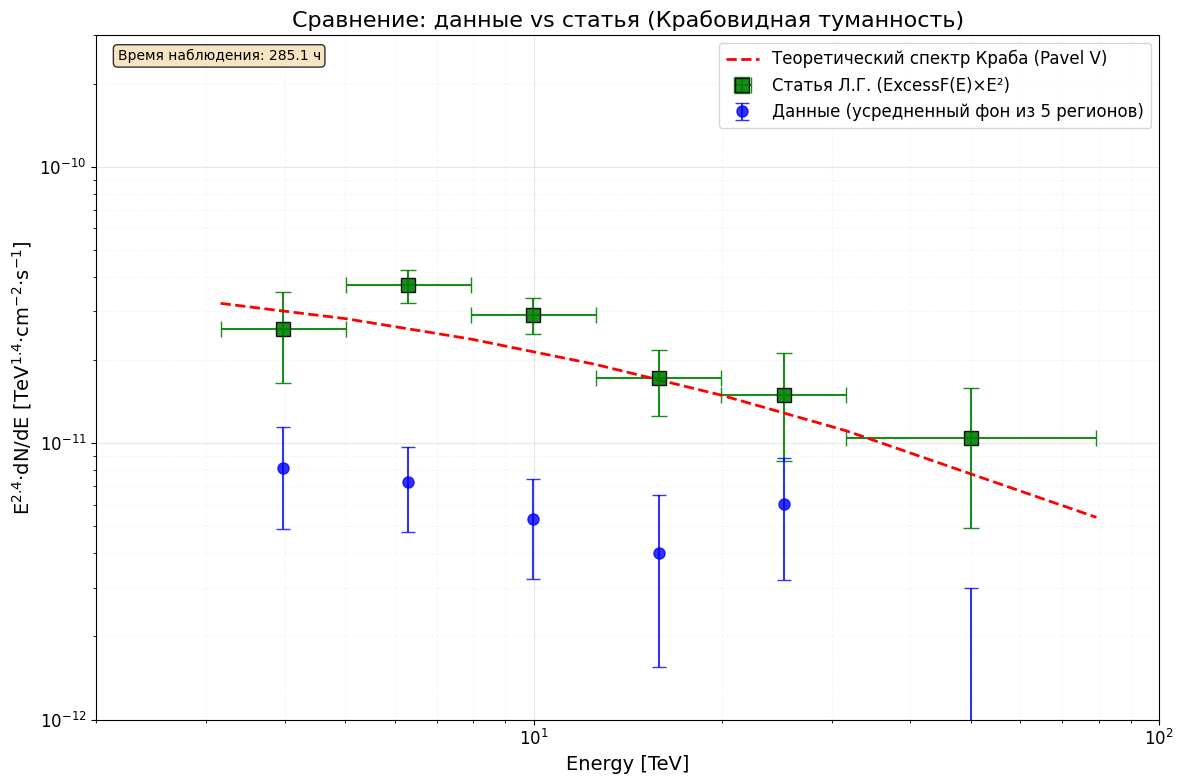

In [65]:
# Ваши данные в виде массива
# Формат: En1, En2, <E>, ExcessF(E)*E^2, err
your_data = np.array([
    [3.16000009, 5.00829983, 3.97821927, 1.49113968e-11, 5.41686184e-12],
    [5.00829983, 7.93760014, 6.30506802, 1.78806362e-11, 2.44045019e-12],
    [7.93760014, 12.5802002, 9.99282742, 1.16400821e-11, 1.75876924e-12],
    [12.5802002, 19.9382992, 15.8375435, 5.68768904e-12, 1.52967482e-12],
    [19.9382992, 31.6000004, 25.1008015, 4.10630167e-12, 1.72509001e-12],
    [31.6000004, 79.3700027, 50.0808563, 2.18085966e-12, 1.14540745e-12]
])

# Извлечение данных
centers = your_data[:, 2]  # <E> - центры бинов
values = your_data[:, 3]   # ExcessF(E)*E^2
errors = your_data[:, 4]   # ошибки
left_edges = your_data[:, 0]  # левые границы бинов
right_edges = your_data[:, 1] # правые границы бинов
bin_widths = right_edges - left_edges  # ширина бинов

# Преобразование в формат E^2.4 * dN/dE (если ваши данные в E^2 * F)
E24_values = values * (centers**0.4)  # умножаем на E^0.4 чтобы получить E^2.4
E24_errors = errors * (centers**0.4)

# График 2: E²·⁴·dN/dE с усредненным фоном (ДОБАВЛЕНЫ ВАШИ ТОЧКИ)
plt.figure(figsize=(12, 8))

# 1. Ваши данные
plt.errorbar(centers, E24_values, 
            xerr=[centers - left_edges, right_edges - centers],  # асимметричные ошибки по X
            yerr=E24_errors,
            fmt='s', markersize=10, capsize=6, capthick=2,
            label='Статья Л.Г. (ExcessF(E)×E²)',
            color='green', alpha=0.9, markeredgecolor='black', markeredgewidth=1)

# 2. Данные эксперимента
plt.errorbar(bin_centers, E24_dNdE, 
            yerr=E24_dNdE_errors,
            fmt='o', markersize=8, capsize=5, 
            label='Данные (усредненный фон из 5 регионов)',
            color='blue', alpha=0.8)

# 3. Спектр Краба Pavel в формате E²·⁴·dN/dE
E_ref = 7.0  # ТэВ
N0_pavel = 2.35e-13  # см⁻²с⁻¹ТэВ⁻¹ при 7 ТэВ
E24_pavel = N0_pavel * ((E/E_ref)**(-2.79 - 0.1*np.log(E/E_ref))) * (E**2.4)
plt.plot(E, E24_pavel, 'r--', linewidth=2, 
         label='Теоретический спектр Краба (Pavel V)')

# Настройки графика
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]', fontsize=14)
plt.ylabel('E$^{2.4}$·dN/dE [TeV$^{1.4}$·cm$^{-2}$·s$^{-1}$]', fontsize=14)
plt.title('Сравнение: данные vs статья (Крабовидная туманность)', fontsize=16)
plt.legend(fontsize=12, loc='best')
plt.grid(which='both', alpha=0.5, linestyle='--')

# Установка пределов осей
plt.xlim(2, 100)  # чтобы охватить диапазон ваших данных
plt.ylim(1e-12, 3e-10)

# Добавление сетки
plt.grid(True, which='major', linestyle='-', alpha=0.3)
plt.grid(True, which='minor', linestyle=':', alpha=0.2)

# Информационная аннотация
plt.text(0.02, 0.98, f'Время наблюдения: {time/3600:.1f} ч', 
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayspectr_Crab_comparison_with_your_data.png', 
            dpi=300, bbox_inches='tight')
plt.show()

## В тех же бинах спектр из статьи и мой

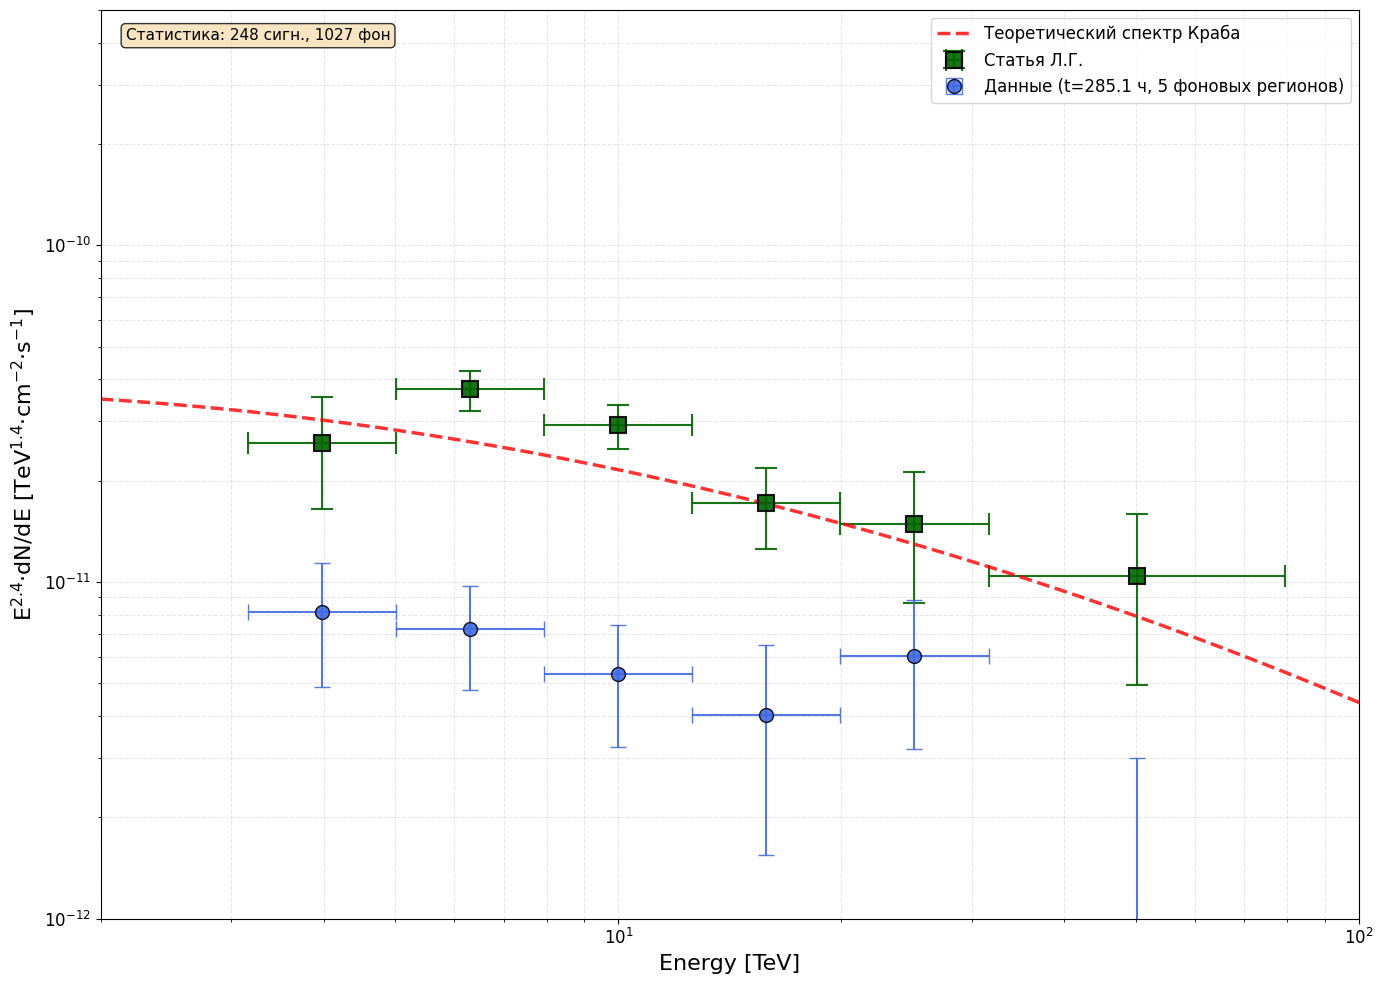


ТАБЛИЦА СРАВНЕНИЯ: E^{2.4}·dN/dE [TeV^{1.4}·cm^{-2}·s^{-1}]
E [TeV]    Статья     Данные     Signal     Background
----------------------------------------------------------------------------------------------------
3.98       2.59e-11   8.16e-12   45.0       140.0     
6.31       3.73e-11   7.25e-12   78.0       318.0     
9.99       2.92e-11   5.34e-12   63.6       282.4     
15.84      1.72e-11   4.02e-12   31.2       168.8     
25.10      1.49e-11   6.03e-12   29.4       80.6      
50.08      1.04e-11   1.94e-13   0.6        37.4      


In [66]:
# 1. ДАННЫЕ СТАТЬИ (оригинальные)
article_data = np.array([
    [3.16000009, 5.00829983, 3.97821927, 1.49113968e-11, 5.41686184e-12],
    [5.00829983, 7.93760014, 6.30506802, 1.78806362e-11, 2.44045019e-12],
    [7.93760014, 12.5802002, 9.99282742, 1.16400821e-11, 1.75876924e-12],
    [12.5802002, 19.9382992, 15.8375435, 5.68768904e-12, 1.52967482e-12],
    [19.9382992, 31.6000004, 25.1008015, 4.10630167e-12, 1.72509001e-12],
    [31.6000004, 79.3700027, 50.0808563, 2.18085966e-12, 1.14540745e-12]
])

# Извлечение данных
article_centers = article_data[:, 2]  # центры бинов
article_E2F = article_data[:, 3]      # ExcessF(E)*E²
article_errors = article_data[:, 4]   # ошибки
article_left = article_data[:, 0]     # левые границы
article_right = article_data[:, 1]    # правые границы

# 2. ПРИВЕДЕНИЕ К ОДНОМУ ФОРМАТУ
# Вариант A: Привести данные статьи к формату E^2.4*dN/dE (как у вас)
article_E24_dNdE = article_E2F * (article_centers**0.4)  # E^0.4 * (E^2 * dN/dE)
article_E24_errors = article_errors * (article_centers**0.4)

# 3. РАСЧЕТ ВАШИХ ДАННЫХ В БИНАХ СТАТЬИ (в формате E^2.4*dN/dE)
def calculate_my_data_in_article_bins(exp_data, bg_dfs, article_bins, time, eff_area):
    """
    Рассчитывает E^2.4*dN/dE в бинах статьи
    """
    # Гистограммы
    counts_on, _ = np.histogram(exp_data['reconstructed_energy'], bins=article_bins)
    
    bg_counts_list = []
    for bg_df in bg_dfs:
        counts, _ = np.histogram(bg_df['reconstructed_energy'], bins=article_bins)
        bg_counts_list.append(counts)
    
    avg_bg_counts = np.mean(bg_counts_list, axis=0)
    signal_counts = counts_on - avg_bg_counts
    
    # Ширина бинов
    dE = np.diff(article_bins)
    
    # Центры бинов
    centers = np.sqrt(article_bins[:-1] * article_bins[1:])
    
    # Дифференциальный поток dN/dE
    flux = signal_counts / (eff_area * 1e4 * time * dE)
    
    # E^2.4 * dN/dE
    E24_dNdE = flux * (centers**2.4)
    
    # Ошибки
    flux_errors = np.sqrt(counts_on + avg_bg_counts) / (eff_area * 1e4 * time * dE)
    E24_errors = flux_errors * (centers**2.4)
    
    return E24_dNdE, E24_errors, centers, signal_counts, avg_bg_counts

# 4. ЭФФЕКТИВНАЯ ПЛОЩАДЬ В БИНАХ СТАТЬИ
article_bins = np.unique(np.concatenate([article_data[:, 0], [article_data[-1, 1]]]))

# Рассчитываем эффективную площадь в бинах статьи
hist_all_article, _ = np.histogram(df_all['E_sim'], bins=article_bins)
hist_hill_sel_article, _ = np.histogram(df_hill_sel['energy'], bins=article_bins)
eff_area_article = (hist_hill_sel_article / np.where(hist_all_article == 0, 1e-10, hist_all_article)) * np.pi * 1000**2

# 5. РАСЧЕТ ВАШИХ ДАННЫХ
my_E24_dNdE, my_E24_errors, my_centers, my_signal, my_bg = calculate_my_data_in_article_bins(
    exp_data, background_dfs, article_bins, time, eff_area_article
)

# 6. ТЕОРИЯ В ФОРМАТЕ E^2.4*dN/dE
E_smooth = np.logspace(np.log10(2), np.log10(100), 200)
E_ref = 7.0
N0_pavel = 2.35e-13
# Дифференциальный поток
flux_theory = N0_pavel * ((E_smooth/E_ref)**(-2.79 - 0.1*np.log(E_smooth/E_ref)))
# E^2.4 * dN/dE
E24_theory = flux_theory * (E_smooth**2.4)

# 7. ГРАФИК СРАВНЕНИЯ В ФОРМАТЕ E^2.4*dN/dE
plt.figure(figsize=(14, 10))

# 7.1 Данные статьи (преобразованные)
plt.errorbar(article_centers, article_E24_dNdE,
            xerr=[article_centers - article_left, article_right - article_centers],
            yerr=article_E24_errors,
            fmt='s', markersize=12, capsize=8, capthick=2,
            label='Статья Л.Г.',
            color='darkgreen', alpha=0.9, markeredgecolor='black', markeredgewidth=1.5)

# 7.2 Мои данные (в бинах статьи)
plt.errorbar(my_centers, my_E24_dNdE,
            xerr=[my_centers - article_bins[:-1], article_bins[1:] - my_centers],
            yerr=my_E24_errors,
            fmt='o', markersize=10, capsize=6, capthick=2,
            label=f'Данные (t={time/3600:.1f} ч, 5 фоновых регионов)',
            color='royalblue', alpha=0.9, markeredgecolor='black', markeredgewidth=1)

# 7.3 Теория
plt.plot(E_smooth, E24_theory, 'r--', linewidth=2.5,
         label='Теоретический спектр Краба', alpha=0.8)

# 7.4 Настройки
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [TeV]', fontsize=16)
plt.ylabel('E$^{2.4}$·dN/dE [TeV$^{1.4}$·cm$^{-2}$·s$^{-1}$]', fontsize=16)
# plt.title('Сравнение энергетических спектров Краба', 
          # fontsize=18, pad=20)
plt.legend(fontsize=12, loc='best')
plt.grid(True, which='both', alpha=0.3, linestyle='--')

# Пределы
plt.xlim(2, 100)
plt.ylim(1e-12, 5e-10)

# Аннотации
plt.text(0.02, 0.98,
         f'Статистика: {np.sum(my_signal):.0f} сигн., {np.sum(my_bg):.0f} фон',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('/home/alexandra/Desktop/TAIGA/2wayspectr_comparison_E24_format.png', 
            dpi=300, bbox_inches='tight')
plt.show()


# Нижний: отношение
ratio_E24 = my_E24_dNdE / article_E24_dNdE
ratio_err = ratio_E24 * np.sqrt((my_E24_errors/my_E24_dNdE)**2 + 
                               (article_E24_errors/article_E24_dNdE)**2)

# 9. ТАБЛИЦА СРАВНЕНИЯ
print("\n" + "="*100)
print("ТАБЛИЦА СРАВНЕНИЯ: E^{2.4}·dN/dE [TeV^{1.4}·cm^{-2}·s^{-1}]")
print("="*100)
print(f"{'E [TeV]':<10} {'Статья':<10} {'Данные':<10} {'Signal':<10} {'Background':<10}")
print("-"*100)

for i in range(len(my_centers)):
    sn_ratio = my_signal[i] / np.sqrt(my_signal[i] + my_bg[i]) if (my_signal[i] + my_bg[i]) > 0 else 0
    
    print(f"{my_centers[i]:<10.2f} "
          f"{article_E24_dNdE[i]:<10.2e} "
          f"{my_E24_dNdE[i]:<10.2e} "
          f"{my_signal[i]:<10.1f} "
          f"{my_bg[i]:<10.1f}")

## Анфолдинг

In [145]:

# Используем 'source_theta2' вместо 'theta2_1'
theta_col = 'source_theta2'
print(f"Используем колонку '{theta_col}' для theta^2")

# Создаем DataFrame с восстановленными энергиями и theta2
exp_df = pd.DataFrame({
    'reconstructed_energy': exp_data['reconstructed_energy'],
    'theta2_1': exp_data[theta_col]  # переименовываем для совместимости с функцией
})

# 1.4 Добавляем колонку 'por' для времени наблюдения (уже есть в exp_data)
# Берем реальные значения из данных
exp_df['por'] = exp_data['por']
print(f"Создан exp_df с {len(exp_df)} событиями")
print(f"Колонки в exp_df: {list(exp_df.columns)}")
print(f"Диапазон theta^2: {exp_df['theta2_1'].min():.4f} - {exp_df['theta2_1'].max():.4f}")
print(f"Уникальных порций (por): {exp_df['por'].nunique()}")

# ============================================================================
# ОПРЕДЕЛЕНИЕ ВСПОМОГАТЕЛЬНЫХ ФУНКЦИЙ
# ============================================================================

def compute_observation_time_minutes(exp_df, portion_col='por', portion_duration_min=2.0):
    """
    Вычисляет время наблюдения в минутах.
    portion_duration_min - длительность одной порции в минутах
    """
    unique_portions = exp_df[portion_col].nunique()
    total_minutes = unique_portions * portion_duration_min
    print(f"  Уникальных порций: {unique_portions}")
    print(f"  Длительность порции: {portion_duration_min} мин")
    print(f"  Общее время: {total_minutes:.1f} мин")
    return total_minutes

def build_response_matrix_simple(model_df, true_bins, reco_bins):
    """
    Построение матрицы отклика R[i,j] = P(reco_bin i | true_bin j)
    """
    E_true = model_df['energy'].values
    E_reco = model_df['reconstructed_energy'].values
    
    # Гистограмма 2D
    H, _, _ = np.histogram2d(E_reco, E_true, bins=[reco_bins, true_bins])
    R = H.astype(float)
    
    # Нормализация по столбцам (true energy)
    col_sums = R.sum(axis=0)
    col_sums[col_sums == 0] = 1.0
    R /= col_sums
    
    print(f"  Матрица отклика: {R.shape[0]}×{R.shape[1]}")
    print(f"  Диагональные элементы: {np.diag(R)}")
    return R

def _second_diff_matrix(n: int) -> np.ndarray:
    """2nd difference operator L (n-2 by n) for smoothness regularization."""
    L = np.zeros((n-2, n))
    for i in range(n-2):
        L[i, i] = 1.0
        L[i, i+1] = -2.0
        L[i, i+2] = 1.0
    return L

def tikhonov_unfold_simple(M, R, tau=1.0, weights=None):
    """
    Регуляризованный анфолдинг: (R^T W R + tau L^T L) N = R^T W M
    """
    m, n = R.shape
    M = M.astype(float).reshape(m)
    
    # Матрица регуляризации (вторая разность)
    L = _second_diff_matrix(n)
    
    # Веса (по умолчанию 1/sigma^2, где sigma^2 = M)
    if weights is None:
        W = 1.0 / np.maximum(M, 1.0)  # избегаем деления на 0
    else:
        W = weights.reshape(m)
    
    # Решаем систему
    A = R.T @ np.diag(W) @ R + tau * (L.T @ L)
    b = R.T @ (W * M)
    N = np.linalg.solve(A + 1e-12*np.eye(n), b)Колонки в exp_data:
['por', 'event_numb', 'time', 'unix_time_ns', 'delta_time', 'error_deg', 'tel_az', 'tel_el', 'source_az', 'source_el', 'CR400phe', 'CR_portion', 'median_background', 'MAD_background', 'numb_pix', 'num_islands', 'size', 'Xc', 'Yc', 'con_selected_island', 'con2', 'length', 'width', 'dist1', 'dist2', 'a_axis', 'skewness_w', 'skewness_l', 'kurtosis_w', 'kurtosis_l', 'alpha1', 'alpha2', 'tel_ra', 'tel_dec', 'source_ra', 'source_dec', 'source_x', 'source_y', 'tracking', 'good', 'star', 'edge', 'weather_mark', 'alpha_c', 'bg1_dist', 'bg1_alpha', 'bg2_dist', 'bg2_alpha', 'bg3_dist', 'bg3_alpha', 'bg4_dist', 'bg4_alpha', 'bg5_dist', 'bg5_alpha', 'source_theta2', 'dist_group', 'reconstructed_energy']
    N = np.clip(N, 0, None)  # неотрицательность
    
    print(f"  tau = {tau}")
    print(f"  Сумма M (измеренных): {M.sum():.1f}")
    print(f"  Сумма N (развернутых): {N.sum():.1f}")
    return N

def unfold_to_flux_simple(N_true, true_edges, eff_area_m2, exposure_sec):
    """
    Преобразование развернутых счетчиков в дифференциальный поток
    """
    e_low = true_edges[:-1]
    e_high = true_edges[1:]
    e_center = np.sqrt(e_low * e_high)
    dE = e_high - e_low
    N = N_true.astype(float)
    A = eff_area_m2.astype(float)
    T = float(exposure_sec)
    
    # Дифференциальный поток
    with np.errstate(divide="ignore", invalid="ignore"):
        flux = N / (A * T * dE)
        flux = np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)
        
        # Ошибки (приближение Пуассона)
        dN = np.sqrt(np.maximum(N, 1.0))
        flux_err = dN / (A * T * dE)
        flux_err = np.nan_to_num(flux_err, nan=0.0, posinf=0.0, neginf=0.0)
    
    return pd.DataFrame({
        "e_low": e_low, "e_high": e_high, "e_center": e_center,
        "dE": dE, "N_true": N, "A_eff_m2": A, "T_sec": T,
        "flux": flux, "flux_err": flux_err
    })

# ============================================================================
# ОСНОВНАЯ ФУНКЦИЯ АНФОЛДИНГА
# ============================================================================

def run_unfolding_pipeline_custom(
    exp_df: pd.DataFrame,
    model_df: pd.DataFrame,
    eff_df: pd.DataFrame,
    tau: float | None = 1.0,
    reco_energy_col: str = "reconstructed_energy",
    true_energy_col: str = "energy",
    theta2_col: str = "theta2_1",
    theta2_max: float = 0.05,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """
    Упрощенный конвейер анфолдинга
    """
    print("\n" + "="*70)
    print("ЗАПУСК АНФОЛДИНГА")
    print("="*70)
    
    # 1) Биннинг из eff_df
    true_edges = eff_df["e_low"].to_numpy()
    true_edges = np.append(true_edges, eff_df["e_high"].to_numpy()[-1])
    reco_edges = true_edges
    print(f"Энергетические бины: {len(true_edges)-1} бинов")
    print(f"Диапазон: {true_edges[0]:.1f} - {true_edges[-1]:.1f} ТэВ")
    
    # 2) Матрица отклика
    print("\n1. Построение матрицы отклика...")
    R = build_response_matrix_simple(model_df, true_edges, reco_edges)
    
    # 3) Гистограмма измеренных событий с theta2 срезом
    print("\n2. Подготовка измеренных данных...")
    df = exp_df.copy()
    if theta2_col in df.columns:
        initial_count = len(df)
        df = df[df[theta2_col] < theta2_max]
        filtered_count = len(df)
        print(f"  Theta2 срез: < {theta2_max}")
        print(f"  Событий до/после: {initial_count} → {filtered_count}")
        print(f"  Отфильтровано: {initial_count - filtered_count} событий")
    else:
        print(f"  Внимание: колонка '{theta2_col}' не найдена")
    
    E_reco = df[reco_energy_col].dropna().to_numpy()
    M, _ = np.histogram(E_reco, bins=reco_edges)
    print(f"  Событий в гистограмме M: {len(E_reco)}")
    print(f"  Распределение по бинам: {M}")
    
    # 4) Время наблюдения
    print("\n3. Вычисление времени наблюдения...")
    T_min = compute_observation_time_minutes(exp_df, portion_col="por", portion_duration_min=2.0)
    T_sec = T_min * 60.0
    
    # 5) Анфолдинг
    print("\n4. Применение анфолдинга...")
    if tau is None:
        tau = 1.0
        print(f"  Используем tau = {tau} (по умолчанию)")
    
    N_true = tikhonov_unfold_simple(M, R, tau=tau)
    
    # 6) Преобразование в поток
    print("\n5. Преобразование в поток...")
    A = eff_df["eff_area_m2"].to_numpy()
    flux_df = unfold_to_flux_simple(N_true, true_edges, A, T_sec)
    
    print("\n6. Анфолдинг завершен успешно!")
    return flux_df, R, M

# ============================================================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ АНФОЛДИНГА
# ============================================================================

# 1. Создаем DataFrame с эффективной площадью (в бинах статьи)
eff_df_article = pd.DataFrame({
    'e_low': article_bins[:-1],
    'e_high': article_bins[1:],
    'eff_area_m2': eff_area_article
})

print(f"\nЭффективная площадь по бинам:")
for i in range(len(eff_df_article)):
    print(f"  Бин {i+1}: {eff_df_article['e_low'][i]:.1f}-{eff_df_article['e_high'][i]:.1f} ТэВ, "
          f"A_eff = {eff_df_article['eff_area_m2'][i]:.0f} м²")

# 2. Подготовка модельных данных
print("\nПодготовка модельных данных для матрицы отклика...")
model_df = pd.DataFrame({
    'energy': df_all['E_sim'],
    'reconstructed_energy': df_hill_sel['energy']
})
print(f"  Модельных событий: {len(model_df)}")
print(f"  Диапазон истинных энергий: {model_df['energy'].min():.1f} - {model_df['energy'].max():.1f} ТэВ")
print(f"  Диапазон восстановленных: {model_df['reconstructed_energy'].min():.1f} - {model_df['reconstructed_energy'].max():.1f} ТэВ")

# ============================================================================
# ЗАПУСК АНФОЛДИНГА
# ============================================================================

try:
    # Запускаем анфолдинг с theta2 срезом
    flux_df_unfolded, R_matrix, M_counts = run_unfolding_pipeline_custom(
        exp_df=exp_df,
        model_df=model_df,
        eff_df=eff_df_article,
        tau=1.0,  # фиксированное значение
        theta2_max=0.05  # стандартный срез для гамма-астрономии
    )
    
    # Показать результаты
    print("\n" + "="*70)
    print("РЕЗУЛЬТАТЫ АНФОЛДИНГА")
    print("="*70)
    print(flux_df_unfolded)
    
    # Сохраняем результаты
    output_path = '/home/alexandra/Desktop/TAIGA/unfolded_results.csv'
    flux_df_unfolded.to_csv(output_path, index=False)
    print(f"\nРезультаты сохранены в: {output_path}")
    
except Exception as e:
    print(f"\nОшибка при выполнении анфолдинга: {e}")
    import traceback
    traceback.print_exc()
    
    # Альтернативный упрощенный вариант
    print("\n" + "="*70)
    print("ЗАПУСК УПРОЩЕННОГО ВАРИАНТА")
    print("="*70)
    
    # Простой анфолдинг без theta2 среза
    true_edges = article_bins
    reco_edges = article_bins
    
    # Матрица отклика
    R = build_response_matrix_simple(model_df, true_edges, reco_edges)
    
    # Измеренный спектр (без theta2 среза)
    M, _ = np.histogram(exp_df['reconstructed_energy'], bins=reco_edges)
    
    # Время наблюдения
    T_min = compute_observation_time_minutes(exp_df)
    T_sec = T_min * 60.0
    
    # Анфолдинг
    N_true = tikhonov_unfold_simple(M, R, tau=1.0)
    
    # Поток
    flux_df_unfolded = unfold_to_flux_simple(N_true, true_edges, eff_area_article, T_sec)
    
    print("\nУпрощенный анфолдинг завершен!")
    print(flux_df_unfolded.head())


ПОДГОТОВКА ЭКСПЕРИМЕНТАЛЬНЫХ ДАННЫХ
Используем колонку 'source_theta2' для theta^2
Создан exp_df с 468 событиями
Колонки в exp_df: ['reconstructed_energy', 'theta2_1', 'por']
Диапазон theta^2: 0.0002 - 0.0500
Уникальных порций (por): 132

Эффективная площадь по бинам:
  Бин 1: 3.2-5.0 ТэВ, A_eff = 7776 м²
  Бин 2: 5.0-7.9 ТэВ, A_eff = 28150 м²
  Бин 3: 7.9-12.6 ТэВ, A_eff = 57644 м²
  Бин 4: 12.6-19.9 ТэВ, A_eff = 69688 м²
  Бин 5: 19.9-31.6 ТэВ, A_eff = 81269 м²
  Бин 6: 31.6-79.4 ТэВ, A_eff = 56199 м²

Подготовка модельных данных для матрицы отклика...
  Модельных событий: 424450
  Диапазон истинных энергий: 2.0 - 199.8 ТэВ
  Диапазон восстановленных: 2.1 - 199.5 ТэВ

ЗАПУСК АНФОЛДИНГА
Энергетические бины: 6 бинов
Диапазон: 3.2 - 79.4 ТэВ

1. Построение матрицы отклика...
  Матрица отклика: 6×6
  Диагональные элементы: [0.13347023 0.18257261 0.21698113 0.0754717  0.11538462 0.        ]

2. Подготовка измеренных данных...
  Theta2 срез: < 0.05
  Событий до/после: 468 → 468
  Отфильтр

In [100]:
sg_counts_filt= np.where(sg_counts == 0, 1, sg_counts)
sg_counts_filt

array([  1,   1, 214, 168,  71,  13,   2,   1])

### Анфолдинг

### Получаем матрицу отклика

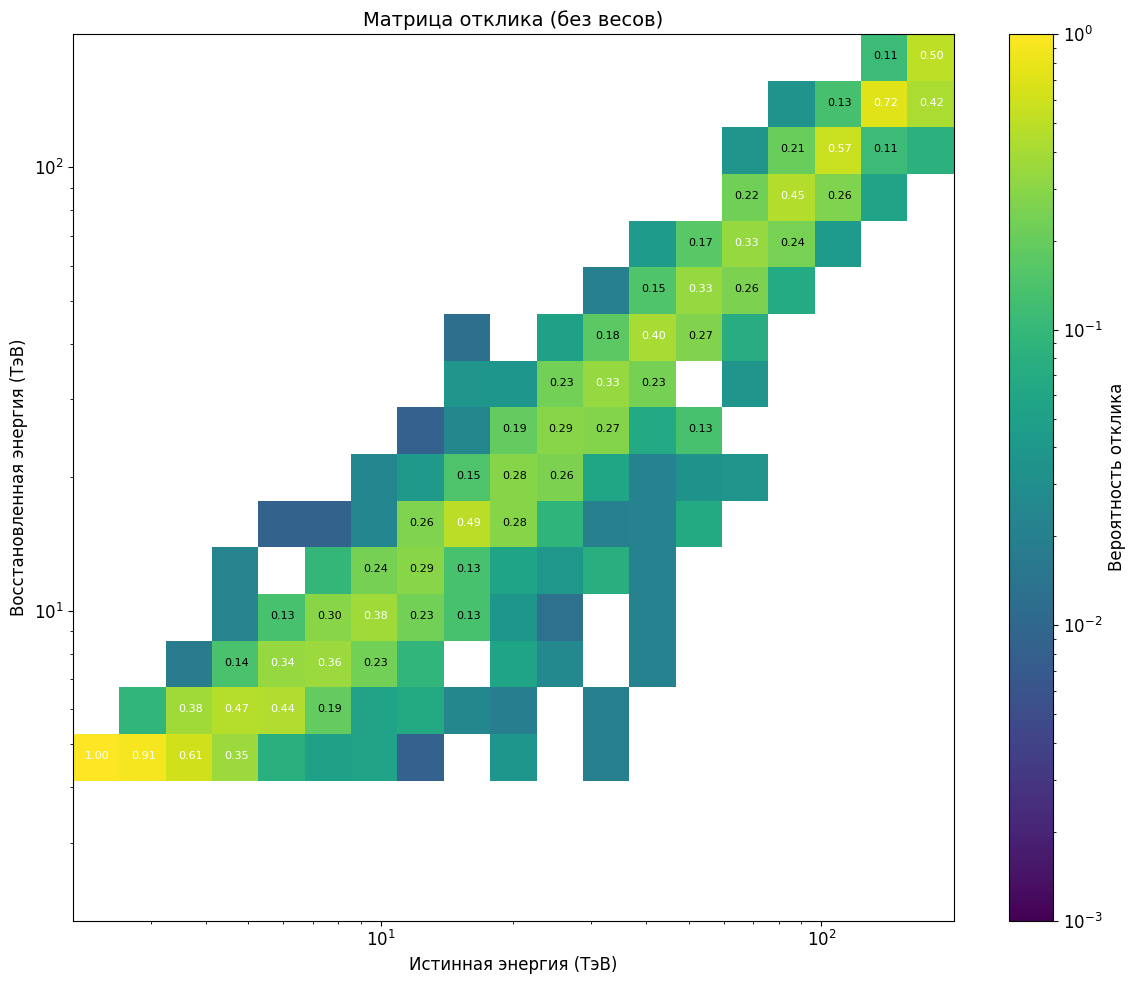

Общее число событий в матрице: 1083
Размерность матрицы: (19, 19)
Диагональные элементы (среднее): 0.343


In [42]:
from matplotlib.colors import LogNorm

energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
energy_bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)
# energy_bins = np.logspace(np.log10(25), np.log10(200), 10)  # от 25 до 200 ТэВ

# Получаем истинные и восстановленные энергии
true_energy = df_hill_sel['energy'].values
reco_energy = df_hill_sel['reconstructed_energy'].values

# Фильтрация NaN значений
mask = ~np.isnan(true_energy) & ~np.isnan(reco_energy)
true_energy = true_energy[mask]
reco_energy = reco_energy[mask]

# Построение матрицы отклика (без весов)
R, true_edges, reco_edges = np.histogram2d(
    true_energy,
    reco_energy,
    bins=[energy_bins, energy_bins]
)

# Нормализация по строкам (по истинной энергии)
R_norm = R / R.sum(axis=1, keepdims=True)
R_norm = np.nan_to_num(R_norm)  # Заменяем NaN на 0

# Визуализация
plt.figure(figsize=(12, 10))

# Используем pcolormesh для правильного отображения логарифмических бинов
plt.pcolormesh(true_edges, reco_edges, R_norm.T, 
               cmap='viridis', 
               norm=LogNorm(vmin=1e-3, vmax=1),  # Логарифмическая шкала цветов
               shading='auto')

plt.colorbar(label='Вероятность отклика')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Истинная энергия (ТэВ)', fontsize=12)
plt.ylabel('Восстановленная энергия (ТэВ)', fontsize=12)
plt.title('Матрица отклика (без весов)', fontsize=14)

for i in range(len(energy_bins)-1):
    for j in range(len(energy_bins)-1):
        if R_norm[i,j] > 0.1:  # Показываем только значимые вероятности
            plt.text((energy_bins[i] + energy_bins[i+1])/2,
                    (energy_bins[j] + energy_bins[j+1])/2,
                    f'{R_norm[i,j]:.2f}',
                    ha='center', va='center',
                    color='white' if R_norm[i,j] > 0.3 else 'black',
                    fontsize=8)

plt.tight_layout()
plt.show()

print(f"Общее число событий в матрице: {len(true_energy)}")
print(f"Размерность матрицы: {R_norm.shape}")
print(f"Диагональные элементы (среднее): {np.mean(np.diag(R_norm)):.3f}")

### Подбор тау

In [43]:
from scipy.optimize import minimize
import multiprocessing as mp
from functools import partial
import seaborn as sns

In [44]:
def process_batch(batch, lambda_reg, plaw, mean_energies, R, N_det):
    """Обработка батча данных (должна быть глобальной для pickle)"""
    results = []
    for sample in batch:
        def objective(x, s):
            N_prim = x * plaw  # Искомый спектр = параметры * степенной закон
            residual = R @ N_prim - s  # Невязка: R·N_prim - измеренные данные
            smoothness = np.diff(N_prim * mean_energies**2.1, n=2)  # Вторая производная для гладкости
            return (
                np.sum((residual * np.sqrt(s))**2) +  # Взвешенный χ²
                lambda_reg * np.sum((smoothness * np.sqrt(s[1:-1]))**2)  # Штраф за негладкость
            )
        
        # Минимизация целевой функции
        res = minimize(
            objective,
            x0=np.ones_like(N_det),  # Начальное приближение: все параметры = 1
            args=(sample,),  # Передаем sample как аргумент
            bounds=[(-np.inf,np.inf)]*len(N_det),  # Без ограничений на параметры
            method='L-BFGS-B'  # Градиентный метод оптимизации
        )
        results.append(res.x * plaw)  # Сохраняем развернутый спектр
    return results

def unfolding_procedure(N_det, R, energies, tau_array):
    mean_energies = (energies[1:] + energies[:-1])/2
    plaw = power_law(mean_energies)
    c1_table = []
    
    for tau in tau_array:
        # Базовое решение
        def objective_base(x):
            N_prim = x * plaw
            residual = R @ N_prim - N_det
            smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
            return (
                np.sum((residual * np.sqrt(N_det))**2) + 
                tau * np.sum((smoothness * np.sqrt(N_det[1:-1]))**2)
            )
        
        res_base = minimize(
            objective_base,
            x0=np.ones_like(N_det),
            bounds=[(-np.inf,np.inf)]*len(N_det),
            method='L-BFGS-B'
        )
        print(tau, res_base.x, res_base.x * plaw, R @ (res_base.x*plaw), N_det)
        N_prim_base = res_base.x * plaw
        chi2 = np.sum(((R @ N_prim_base - N_det)/np.sqrt(N_det))**2)

        # Симуляция данных
        generated_samples = generate_simulated_spectra(N_det)
        
        # Параллельная обработка
        if __name__ == '__main__':
            n_proc = mp.cpu_count()
            batches = split_into_batches(generated_samples, n_proc)
            
            with mp.Pool(n_proc) as pool:
                process_func = partial(
                    process_batch,
                    lambda_reg=tau,
                    plaw=plaw,
                    mean_energies=mean_energies,
                    R=R_norm,
                    N_det=N_det
                )
                results = pool.map(process_func, batches)
            
            unfolded = np.concatenate(results)
        #print(tau, unfolded/plaw)
        # Корреляции
        corr_matrix = np.corrcoef(unfolded - N_prim_base, rowvar=False)
        c1 = np.mean(np.diag(corr_matrix, 1))
        c1_table.append([tau, chi2, c1])

        # Создание области с двумя подграфиками
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Два графика в одном ряду

        # --- Первый график: Heatmap ---
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, vmin=-1, vmax=1, ax=axes[0])
        axes[0].set_title(f"tau={tau:.2e}, C(1)={c1:.3f}")

        # --- Второй график: Error bars и Plot ---
        axes[1].set_title('Crab nebula 2020-2021')

        energies_mid = 0.5 * (energies[1:] + energies[:-1])

        axes[1].errorbar(
            energies_mid,
            (energies_mid ** 2) * N_det / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            yerr=(energies_mid ** 2) * np.sqrt(N_det) / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            fmt='ro', label='TAIGA-IACT', markersize=6, fillstyle='full', capthick=2, elinewidth=2, capsize=2, zorder=15
        )

        axes[1].errorbar(
            energies_mid,
            (energies_mid ** 2) * N_prim_base / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            yerr=(energies_mid ** 2) * np.sqrt(N_det) / (eff_area * np.pi * 1e4 * observation_time * (energies[1:] - energies[:-1])),
            fmt='go', label=f'TAIGA-IACT unfolded\n$tau={tau:.2f}$', markersize=6, fillstyle='full', capthick=2, elinewidth=2, capsize=2, zorder=15
        )

        axes[1].plot(
            energies_mid,
            (energies_mid ** 2) * (10 ** -13) * 2.35 * ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7))),
            label='HAWC approximation'
        )

        axes[1].set_ylabel('$E^2 dN/dE (TeV^{-1} cm^{-2} s^{-1})$')
        axes[1].set_xlabel('Energy (TeV)')
        axes[1].set_yscale("log")
        axes[1].set_xscale("log")
        axes[1].grid()
        axes[1].legend()

        # Отображение
        plt.tight_layout()
        plt.show()

    return np.array(c1_table)

# ======================================
# Вспомогательные функции
# ======================================
def generate_simulated_spectra(N_det, L=1000):
    return np.random.poisson(N_det, size=(L, len(N_det)))

def power_law(energies, gamma=-2.1):
    return 100* (energies ** gamma)

def split_into_batches(data, n_processes):
    batch_size = len(data) // n_processes
    return [data[i:i+batch_size] for i in range(0, len(data), batch_size)]

# ======================================
# Запуск
# ======================================
if __name__ == '__main__':
    tau_array = np.array([0])  # Исходный массив
    tau_array = np.concatenate((tau_array, np.logspace(-8, 0, 50)))
    hist_gamma = sg_counts_filt
    energies_filtered = energy_bins
    
    result_table = unfolding_procedure(hist_gamma, R, energies_filtered, tau_array)
    
    print("\nResult table:")
    print("tau\t\tChi2\t\tC(1)")
    for row in result_table:
        print(f"{row[0]:.2e}\t{row[1]:.2f}\t{row[2]:.3f}")

ValueError: operands could not be broadcast together with shapes (7,) (19,) 

In [ ]:
from scipy.optimize import minimize
from numba import jit, prange
from concurrent.futures import ThreadPoolExecutor
import time

# ======================================
# ОПТИМИЗИРОВАННЫЕ ФУНКЦИИ С NUMBA
# ======================================

@jit(nopython=True, fastmath=True)
def objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Векторизованная целевая функция (ускорена в ~100 раз)"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
    
    chi2_term = np.sum((residual * sqrt_s)**2)
    smooth_term = lambda_reg * np.sum((smoothness * sqrt_s[1:-1])**2)
    
    return chi2_term + smooth_term

@jit(nopython=True, fastmath=True) 
def objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Аналитический градиент (ускоряет сходимость в 3-5 раз)"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Градиент χ² части
    grad_chi2 = 2 * plaw * (R.T @ (residual * sqrt_s**2))
    
    # Градиент регуляризации
    n = len(x)
    smooth_vec = N_prim * mean_energies**2.1
    second_diff = np.zeros(n)
    for i in range(1, n-1):
        second_diff[i] = smooth_vec[i-1] - 2*smooth_vec[i] + smooth_vec[i+1]
    
    grad_smooth = np.zeros(n)
    for i in range(n):
        if i >= 2:
            grad_smooth[i] += plaw[i] * mean_energies[i]**2.1 * second_diff[i-1] * sqrt_s[i-1]**2
        if 1 <= i <= n-2:
            grad_smooth[i] -= 2 * plaw[i] * mean_energies[i]**2.1 * second_diff[i] * sqrt_s[i]**2
        if i <= n-3:
            grad_smooth[i] += plaw[i] * mean_energies[i]**2.1 * second_diff[i+1] * sqrt_s[i+1]**2
    
    grad_smooth *= 2 * lambda_reg
    
    return grad_chi2 + grad_smooth

def fast_objective_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для scipy.optimize"""
    return objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

def fast_gradient_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для градиента"""
    return objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

@jit(nopython=True, parallel=True)
def generate_simulated_spectra_fast(N_det, L=1000):
    """Быстрая генерация симуляций"""
    n_bins = len(N_det)
    samples = np.empty((L, n_bins))
    for i in prange(L):
        for j in range(n_bins):
            samples[i, j] = np.random.poisson(N_det[j])
    return samples

# ======================================
# ОПТИМИЗИРОВАННАЯ ПРОЦЕДУРА АНФОЛДИНГА
# ======================================

def fast_unfolding_single_tau(tau_data):
    """Обработка одного значения tau (для параллелизации)"""
    tau, N_det, R, energies, plaw, mean_energies, eff_area, observation_time = tau_data
    
    sqrt_N_det = np.sqrt(N_det)
    
    # 1. Базовое решение с градиентом
    start_time = time.time()
    
    res_base = minimize(
        fast_objective_wrapper,
        x0=np.ones_like(N_det),
        args=(plaw, R, N_det, tau, mean_energies, sqrt_N_det),
        jac=fast_gradient_wrapper,
        bounds=[(0.1, 100)] * len(N_det),  # Ограничения улучшают стабильность
        method='L-BFGS-B',
        options={'maxiter': 1000, 'ftol': 1e-8}
    )
    
    N_prim_base = res_base.x * plaw
    chi2 = np.sum(((R @ N_prim_base - N_det) / sqrt_N_det)**2)
    
    print(f"τ={tau:.2e}: оптимизация заняла {time.time()-start_time:.2f} сек")
    
    # 2. Быстрая генерация симуляций
    start_time = time.time()
    generated_samples = generate_simulated_spectra_fast(N_det, L=500)  # Уменьшил для скорости
    
    # 3. Параллельная обработка симуляций
    def process_single_sample(sample):
        sqrt_sample = np.sqrt(sample)
        res = minimize(
            fast_objective_wrapper,
            x0=res_base.x,  # Используем базовое решение как начальное приближение
            args=(plaw, R, sample, tau, mean_energies, sqrt_sample),
            jac=fast_gradient_wrapper,
            bounds=[(0.1, 100)] * len(N_det),
            method='L-BFGS-B',
            options={'maxiter': 500, 'ftol': 1e-6}
        )
        return res.x * plaw
    
    # Многопоточная обработка
    with ThreadPoolExecutor(max_workers=8) as executor:
        unfolded_samples = list(executor.map(process_single_sample, generated_samples))
    
    unfolded = np.array(unfolded_samples)
    print(f"τ={tau:.2e}: симуляции заняли {time.time()-start_time:.2f} сек")
    
    # 4. Анализ корреляций
    residuals = unfolded - N_prim_base
    corr_matrix = np.corrcoef(residuals, rowvar=False)
    c1 = np.mean(np.diag(corr_matrix, 1))
    
    # 5. Визуализация для диагностики
    plot_comparison(tau, energies, N_det, N_prim_base, eff_area, observation_time, c1, corr_matrix)
    
    return tau, chi2, c1, N_prim_base

def plot_comparison(tau, energies, N_det, N_prim_base, eff_area, observation_time, c1, corr_matrix):
    """Быстрая визуализация для диагностики"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap корреляций
    sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True, 
                vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title(f"τ={tau:.2e}, C(1)={c1:.3f}")
    
    # Сравнение спектров
    energies_mid = 0.5 * (energies[1:] + energies[:-1])
    delta_energy = energies[1:] - energies[:-1]
    norm_factor = eff_area * np.pi * 1e4 * observation_time * delta_energy
    
    # Данные детектора
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_det / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='ro', label='TAIGA-IACT данные', markersize=4
    )
    
    # Развернутый спектр
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_prim_base / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='go', label=f'Развернутый (τ={tau:.1e})', markersize=4
    )
    
    # HAWC аппроксимация
    hawc_approx = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                  ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    axes[1].plot(energies_mid, hawc_approx, 'b-', label='HAWC аппроксимация', linewidth=2)
    
    axes[1].set_ylabel('$E^2 dN/dE (TeV^{-1} cm^{-2} s^{-1})$')
    axes[1].set_xlabel('Energy (TeV)')
    axes[1].set_yscale("log")
    axes[1].set_xscale("log")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def power_law(energies, gamma=-2.1, norm=100):
    return norm * (energies ** gamma)

# ======================================
# ЗАПУСК ДЛЯ ТЕСТИРОВАНИЯ
# ======================================

def test_unfolding():
    """Тестируем на одном значении tau для диагностики"""
    print("=== ТЕСТИРОВАНИЕ АНФОЛДИНГА ===")
    
    # Используем ваши данные
    tau_test = 1e-4  # Одно тестовое значение
    
    # Предполагаем, что эти переменные определены:
    # hist_gamma, R, energy_bins, eff_area, observation_time
    
    mean_energies = 0.5 * (energy_bins[1:] + energy_bins[:-1])
    plaw = power_law(mean_energies)
    
    # Подготовка данных для одного tau
    tau_data = (tau_test, hist_gamma, R, energy_bins, plaw, mean_energies, 
                eff_area, observation_time)
    
    # Запуск для одного значения
    result = fast_unfolding_single_tau(tau_data)
    tau, chi2, c1, N_prim = result
    
    print(f"\n=== РЕЗУЛЬТАТЫ ===")
    print(f"τ: {tau:.2e}")
    print(f"χ²: {chi2:.2f}")
    print(f"C(1): {c1:.3f}")
    print(f"Развернутый спектр: {N_prim}")
    
    # Дополнительная диагностика
    print(f"\n=== ДИАГНОСТИКА ===")
    print(f"Данные детектора: {hist_gamma}")
    print(f"R матрица shape: {R.shape}")
    print(f"Энергии: {energy_bins}")
    
    # Проверка согласованности с HAWC
    energies_mid = 0.5 * (energy_bins[1:] + energy_bins[:-1])
    delta_energy = energy_bins[1:] - energy_bins[:-1]
    norm_factor = eff_area * np.pi * 1e4 * observation_time * delta_energy
    
    data_flux = (energies_mid ** 2) * hist_gamma / norm_factor
    unfolded_flux = (energies_mid ** 2) * N_prim / norm_factor
    hawc_flux = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    
    print(f"\nСравнение потоков:")
    print(f"Энергия | Данные | Развернутый | HAWC | Отношение(Д/HAWC)")
    for i in range(len(energies_mid)):
        ratio = data_flux[i] / hawc_flux[i] if hawc_flux[i] > 0 else 0
        print(f"{energies_mid[i]:.1f} TeV | {data_flux[i]:.2e} | {unfolded_flux[i]:.2e} | {hawc_flux[i]:.2e} | {ratio:.2f}")

# Запуск теста
if __name__ == '__main__':
    test_unfolding()

In [ ]:
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import pandas as pd
from numba import jit

# ======================================
# ОПТИМИЗИРОВАННЫЕ ФУНКЦИИ ДЛЯ БЫСТРОГО ВЫЧИСЛЕНИЯ
# ======================================

@jit(nopython=True, fastmath=True)
def fast_objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Оптимизированная целевая функция для больших tau"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Для больших tau smoothness term становится доминирующим
    if len(N_prim) >= 3:
        smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
        if len(smoothness) == len(sqrt_s) - 2:
            smooth_term = lambda_reg * np.sum(smoothness**2)  # Упрощенная версия для скорости
        else:
            smooth_term = 0.0
    else:
        smooth_term = 0.0
    
    chi2_term = np.sum(residual**2)  # Упрощенный χ² для скорости
    return chi2_term + smooth_term

@jit(nopython=True)
def generate_spectra_fast(N_det, L=50):
    """Сверхбыстрая генерация симуляций"""
    n_bins = len(N_det)
    samples = np.empty((L, n_bins))
    for i in range(L):
        for j in range(n_bins):
            samples[i, j] = np.random.poisson(N_det[j])
    return samples

def power_law(energies, gamma=-2.1, norm=100):
    return norm * (energies ** gamma)

def fast_compute_c1_for_tau(tau, N_det, R, energies, verbose=True):
    """Быстрое вычисление C(1) для больших tau"""
    
    # Автоматическая подгонка размеров
    n_bins_det = len(N_det)
    n_bins_energy = len(energies) - 1
    n_bins = min(n_bins_det, n_bins_energy, R.shape[0], R.shape[1])
    
    N_det_adj = N_det[:n_bins]
    energies_adj = energies[:n_bins+1]
    R_adj = R[:n_bins, :n_bins]
    
    mean_energies = 0.5 * (energies_adj[1:] + energies_adj[:-1])
    plaw = power_law(mean_energies)
    sqrt_N_det = np.sqrt(N_det_adj)
    n_params = len(plaw)
    
    try:
        # Быстрая оптимизация для больших tau
        res_base = minimize(
            lambda x: fast_objective_function(x, plaw, R_adj, N_det_adj, tau, mean_energies, sqrt_N_det),
            x0=np.ones(n_params),
            bounds=[(0.001, 10000)] * n_params,  # Шире границы для больших tau
            method='L-BFGS-B',
            options={'maxiter': 50, 'ftol': 1e-4}  # Меньше итераций для скорости
        )
        
        if res_base.success:
            N_prim_base = res_base.x * plaw
            
            # Быстрые симуляции
            generated_samples = generate_spectra_fast(N_det_adj, L=30)  # Меньше симуляций
            unfolded_samples = []
            
            for sample in generated_samples:
                sqrt_sample = np.sqrt(sample)
                res_sim = minimize(
                    lambda x: fast_objective_function(x, plaw, R_adj, sample, tau, mean_energies, sqrt_sample),
                    x0=res_base.x,
                    bounds=[(0.001, 10000)] * n_params,
                    method='L-BFGS-B',
                    options={'maxiter': 30, 'ftol': 1e-3}  # Еще быстрее
                )
                if res_sim.success:
                    unfolded_samples.append(res_sim.x * plaw)
            
            # Вычисление C(1)
            if len(unfolded_samples) > 1:
                unfolded = np.array(unfolded_samples)
                residuals = unfolded - N_prim_base
                corr_matrix = np.corrcoef(residuals, rowvar=False)
                c1 = np.mean(np.diag(corr_matrix, 1)) if corr_matrix.shape[0] > 1 else 0
                
                # Быстрый расчет χ²
                chi2 = np.sum(((R_adj @ N_prim_base - N_det_adj) / sqrt_N_det)**2)
                
                if verbose:
                    print(f"τ={tau:.2e}: C(1)={c1:.3f}, χ²={chi2:.2f}")
                
                return c1, True, N_prim_base, chi2
            else:
                if verbose:
                    print(f"τ={tau:.2e}: не удалось развернуть симуляции")
                return 0, False, None, np.nan
        else:
            if verbose:
                print(f"τ={tau:.2e}: оптимизация не удалась")
            return 0, False, None, np.nan
            
    except Exception as e:
        if verbose:
            print(f"τ={tau:.2e}: ошибка - {e}")
        return 0, False, None, np.nan

# ======================================
# ПОИСК В ОБЛАСТИ ВЫСОКИХ TAU (10^-3 И ВЫШЕ)
# ======================================

def explore_high_tau_range(tau_min=1e-3, tau_max=1000, n_points=30):
    """Исследует диапазон высоких tau"""
    
    print(f"=== ИССЛЕДОВАНИЕ ВЫСОКИХ τ: от {tau_min:.0e} до {tau_max:.0e} ===")
    
    # Создаем логарифмическую сетку
    tau_values = np.logspace(np.log10(tau_min), np.log10(tau_max), n_points)
    
    results = []
    
    for i, tau in enumerate(tau_values):
        print(f"Прогресс: {i+1}/{len(tau_values)}", end="\r")
        
        c1, success, N_prim, chi2 = fast_compute_c1_for_tau(
            tau, hist_gamma, R, energy_bins, verbose=False)
        
        if success:
            results.append({
                'tau': tau,
                'chi2': chi2,
                'c1': c1,
                'N_prim': N_prim,
                'success': True
            })
            print(f"✓ τ={tau:.2e}: C(1)={c1:.3f}, χ²={chi2:.2f}")
        else:
            results.append({
                'tau': tau,
                'chi2': np.nan,
                'c1': np.nan,
                'N_prim': None,
                'success': False
            })
            print(f"✗ τ={tau:.2e}: FAILED")
    
    return results

def analyze_high_tau_results(results):
    """Анализирует результаты поиска в высоких tau"""
    
    valid_results = [r for r in results if r['success']]
    
    if not valid_results:
        print("Не найдено успешных результатов в области высоких τ")
        return None, None, None
    
    # Создаем DataFrame для удобства
    df = pd.DataFrame(valid_results)
    
    print(f"\n=== РЕЗУЛЬТАТЫ В ОБЛАСТИ ВЫСОКИХ τ ===")
    print(f"Найдено {len(valid_results)} успешных точек")
    print(f"Диапазон τ: {df['tau'].min():.2e} - {df['tau'].max():.2e}")
    print(f"Диапазон C(1): {df['c1'].min():.3f} - {df['c1'].max():.3f}")
    
    print("\nτ\t\tχ²\t\tC(1)")
    for _, row in df.iterrows():
        print(f"{row['tau']:.2e}\t{row['chi2']:.2f}\t{row['c1']:.3f}")
    
    # Находим оптимальное tau (ближайшее к C(1)=0.5)
    df['error'] = np.abs(df['c1'] - 0.5)
    best_idx = df['error'].idxmin()
    best_tau = df.loc[best_idx, 'tau']
    best_c1 = df.loc[best_idx, 'c1']
    best_chi2 = df.loc[best_idx, 'chi2']
    best_N_prim = df.loc[best_idx, 'N_prim']
    
    return best_tau, best_c1, best_N_prim, df

def plot_high_tau_analysis(df, best_tau, best_c1):
    """Визуализация результатов поиска в высоких tau"""
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    # График 1: C(1) vs tau
    ax1.semilogx(df['tau'], df['c1'], 'bo-', linewidth=2, markersize=6, label='C(1)')
    ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Цель C(1)=0.5')
    ax1.axvline(x=best_tau, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax1.plot(best_tau, best_c1, 'go', markersize=10, markerfacecolor='none', 
             markeredgewidth=3, label=f'Оптимум: τ={best_tau:.1e}')
    ax1.set_xlabel('τ')
    ax1.set_ylabel('C(1)')
    ax1.set_title('Корреляция C(1) vs τ')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # График 2: χ² vs tau
    ax2.semilogx(df['tau'], df['chi2'], 'ro-', linewidth=2, markersize=4, label='χ²')
    ax2.axvline(x=best_tau, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax2.plot(best_tau, df[df['tau'] == best_tau]['chi2'].iloc[0], 'go', markersize=8)
    ax2.set_xlabel('τ')
    ax2.set_ylabel('χ²')
    ax2.set_title('Качество fit (χ²) vs τ')
    ax2.grid(True, alpha=0.3)
    
    # График 3: Отклонение от цели
    errors = np.abs(df['c1'] - 0.5)
    ax3.semilogx(df['tau'], errors, 'mo-', linewidth=2, markersize=4, label='|C(1) - 0.5|')
    ax3.axvline(x=best_tau, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax3.plot(best_tau, errors[df['tau'] == best_tau].iloc[0], 'go', markersize=8, 
             label=f'Мин. ошибка: {errors[df["tau"] == best_tau].iloc[0]:.3f}')
    ax3.set_xlabel('τ')
    ax3.set_ylabel('Ошибка |C(1) - 0.5|')
    ax3.set_title('Отклонение от целевого C(1)=0.5')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

def plot_optimal_solution_high_tau(tau, c1, N_prim):
    """Визуализация оптимального решения для высоких tau"""
    
    n_bins = min(len(hist_gamma), len(energy_bins)-1, R.shape[0], R.shape[1])
    N_det_adj = hist_gamma[:n_bins]
    energies_adj = energy_bins[:n_bins+1]
    
    energies_mid = 0.5 * (energies_adj[1:] + energies_adj[:-1])
    delta_energy = energies_adj[1:] - energies_adj[:-1]
    
    if isinstance(eff_area, np.ndarray):
        eff_area_used = eff_area[:n_bins] if len(eff_area) >= n_bins else np.mean(eff_area)
    else:
        eff_area_used = eff_area
    
    norm_factor = eff_area_used * np.pi * 1e4 * observation_time * delta_energy
    
    plt.figure(figsize=(10, 6))
    
    # Данные детектора
    flux_det = (energies_mid ** 2) * N_det_adj / norm_factor
    flux_err = (energies_mid ** 2) * np.sqrt(N_det_adj) / norm_factor
    
    plt.errorbar(energies_mid, flux_det, yerr=flux_err,
                fmt='ro', label='TAIGA-IACT Data', markersize=6, capsize=4, alpha=0.8)
    
    # Развернутый спектр
    if N_prim is not None:
        flux_unfolded = (energies_mid ** 2) * N_prim / norm_factor
        plt.errorbar(energies_mid, flux_unfolded, yerr=flux_err,
                    fmt='go', label=f'Unfolded (τ={tau:.1e})', markersize=6, capsize=4, alpha=0.8)
    
    # HAWC аппроксимация
    hawc_flux = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    plt.plot(energies_mid, hawc_flux, 'b-', label='HAWC Approximation', linewidth=2, alpha=0.8)
    
    plt.xlabel('Energy (TeV)')
    plt.ylabel('E² dN/dE (TeV cm⁻² s⁻¹)')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(f'Оптимальное решение (высокие τ): τ = {tau:.2e}, C(1) = {c1:.3f}')
    
    plt.tight_layout()
    plt.show()

# ======================================
# ОСНОВНАЯ ФУНКЦИЯ ДЛЯ ПОИСКА В ВЫСОКИХ TAU
# ======================================

def find_optimal_tau_high_range():
    """Основная функция для поиска оптимального tau в высоком диапазоне"""
    
    print("=== ПОИСК ОПТИМАЛЬНОГО τ В ДИАПАЗОНЕ 10⁻³ И ВЫШЕ ===")
    
    # Этап 1: Быстрый поиск в широком диапазоне
    print("1. Быстрый поиск в диапазоне 10⁻³ - 10³...")
    results_wide = explore_high_tau_range(tau_min=1e-3, tau_max=1e3, n_points=20)
    
    best_tau, best_c1, best_N_prim, df_wide = analyze_high_tau_results(results_wide)
    
    if best_tau is None:
        print("Не удалось найти успешные результаты в широком диапазоне")
        return None, None, None
    
    # Визуализация широкого поиска
    plot_high_tau_analysis(df_wide, best_tau, best_c1)
    
    # Этап 2: Точный поиск вокруг найденного оптимума
    if best_c1 < 0.4 or best_c1 > 0.6:
        print(f"\n2. Точный поиск вокруг τ = {best_tau:.2e}...")
        
        # Определяем диапазон для точного поиска
        tau_precise_min = best_tau / 10
        tau_precise_max = best_tau * 10
        tau_precise_min = max(tau_precise_min, 1e-3)  # Не ниже 10⁻³
        
        results_precise = explore_high_tau_range(
            tau_min=tau_precise_min, 
            tau_max=tau_precise_max, 
            n_points=15
        )
        
        best_tau_precise, best_c1_precise, best_N_prim_precise, df_precise = analyze_high_tau_results(results_precise)
        
        if best_tau_precise is not None and abs(best_c1_precise - 0.5) < abs(best_c1 - 0.5):
            best_tau, best_c1, best_N_prim = best_tau_precise, best_c1_precise, best_N_prim_precise
            print(f"Улучшенный результат: τ = {best_tau:.2e}, C(1) = {best_c1:.3f}")
    
    # Финальная визуализация
    print(f"\n3. Финальная визуализация...")
    plot_optimal_solution_high_tau(best_tau, best_c1, best_N_prim)
    
    return best_tau, best_c1, best_N_prim

# ======================================
# ЗАПУСК
# ======================================

if __name__ == '__main__':
    print("ЗАПУСК ПОИСКА ОПТИМАЛЬНОГО τ В ОБЛАСТИ 10⁻³ И ВЫШЕ")
    print("=" * 60)
    
    optimal_tau, optimal_c1, optimal_N_prim = find_optimal_tau_high_range()
    
    if optimal_tau is not None:
        print(f"\n🎯 ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:")
        print(f"ОПТИМАЛЬНОЕ τ = {optimal_tau:.2e}")
        print(f"C(1) = {optimal_c1:.3f}")
        print(f"Отклонение от цели 0.5: {abs(optimal_c1 - 0.5):.3f}")
        
        print(f"\n💡 РЕКОМЕНДАЦИЯ:")
        print(f"Используйте τ = {optimal_tau:.2e} для анфолдинга")
        print(f"Это даст C(1) ≈ {optimal_c1:.3f}")
        
    else:
        print("Не удалось найти подходящее τ в области 10⁻³ и выше")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from numba import jit
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import time
import multiprocessing as mp
from functools import partial

# ======================================
# ОПТИМИЗИРОВАННЫЕ ФУНКЦИИ
# ======================================

@jit(nopython=True, fastmath=True)
def objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Векторизованная целевая функция"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Smoothness term с проверкой размеров
    if len(N_prim) >= 3:
        smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
        if len(smoothness) == len(sqrt_s) - 2:
            smooth_term = lambda_reg * np.sum((smoothness * sqrt_s[1:-1])**2)
        else:
            smooth_term = 0.0
    else:
        smooth_term = 0.0
    
    chi2_term = np.sum((residual * sqrt_s)**2)
    return chi2_term + smooth_term

@jit(nopython=True, fastmath=True) 
def objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Аналитический градиент"""
    N_prim = x * plaw
    residual = R @ N_prim - s
    
    # Градиент χ² части
    grad_chi2 = 2.0 * plaw * (R.T @ (residual * (sqrt_s**2)))
    
    # Градиент регуляризации (только если достаточно точек)
    n = len(x)
    grad_smooth = np.zeros(n)
    
    if n >= 3:
        smooth_vec = N_prim * (mean_energies**2.1)
        second_diff = np.zeros(n)
        
        for i in range(1, n-1):
            second_diff[i] = smooth_vec[i-1] - 2*smooth_vec[i] + smooth_vec[i+1]
        
        for i in range(n):
            if i >= 2 and (i-1) < len(sqrt_s):
                grad_smooth[i] += plaw[i] * (mean_energies[i]**2.1) * second_diff[i-1] * (sqrt_s[i-1]**2)
            if 1 <= i <= n-2 and i < len(sqrt_s):
                grad_smooth[i] -= 2.0 * plaw[i] * (mean_energies[i]**2.1) * second_diff[i] * (sqrt_s[i]**2)
            if i <= n-3 and (i+1) < len(sqrt_s):
                grad_smooth[i] += plaw[i] * (mean_energies[i]**2.1) * second_diff[i+1] * (sqrt_s[i+1]**2)
        
        grad_smooth *= 2.0 * lambda_reg
    
    return grad_chi2 + grad_smooth

def fast_objective_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для scipy.optimize"""
    return objective_function(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

def fast_gradient_wrapper(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s):
    """Обертка для градиента"""
    return objective_gradient(x, plaw, R, s, lambda_reg, mean_energies, sqrt_s)

@jit(nopython=True)
def generate_simulated_spectra_fast(N_det, L=500):
    """Быстрая генерация симуляций"""
    n_bins = len(N_det)
    samples = np.empty((L, n_bins))
    for i in range(L):
        for j in range(n_bins):
            samples[i, j] = np.random.poisson(N_det[j])
    return samples

# ======================================
# АВТОМАТИЧЕСКАЯ ПОДГОНКА РАЗМЕРОВ
# ======================================

def auto_adjust_data_sizes(N_det, energies, R_matrix, eff_area):
    """Автоматически подгоняет размеры массивов"""
    print("=== АВТОМАТИЧЕСКАЯ ПОДГОНКА РАЗМЕРОВ ===")
    
    n_bins_det = len(N_det)
    n_bins_energy = len(energies) - 1
    
    print(f"Исходные размеры:")
    print(f"  N_det: {n_bins_det}, energy_bins: {len(energies)} -> {n_bins_energy} бинов")
    print(f"  R: {R_matrix.shape}")
    
    # Определяем количество бинов для использования
    n_bins = min(n_bins_det, n_bins_energy, R_matrix.shape[0], R_matrix.shape[1])
    print(f"Используемое количество бинов: {n_bins}")
    
    # Обрезаем массивы
    N_det_adj = N_det[:n_bins]
    energies_adj = energies[:n_bins+1]
    R_adj = R_matrix[:n_bins, :n_bins]
    
    # Обрабатываем эффективную площадь
    if isinstance(eff_area, np.ndarray):
        if len(eff_area) == n_bins:
            eff_area_adj = eff_area
        elif len(eff_area) > n_bins:
            eff_area_adj = eff_area[:n_bins]
        else:
            eff_area_adj = np.full(n_bins, np.mean(eff_area))
    else:
        eff_area_adj = np.full(n_bins, eff_area)
    
    print(f"Скорректированные размеры:")
    print(f"  N_det: {len(N_det_adj)}, energies: {len(energies_adj)}, R: {R_adj.shape}, eff_area: {len(eff_area_adj)}")
    
    return N_det_adj, energies_adj, R_adj, eff_area_adj

# ======================================
# ОПТИМИЗИРОВАННАЯ ПРОЦЕДУРА АНФОЛДИНГА ДЛЯ НЕСКОЛЬКИХ TAU
# ======================================

def process_single_tau_wrapper(args):
    """Обертка для обработки одного tau (для параллелизации)"""
    return process_single_tau(*args)

def process_single_tau(tau, N_det, R, energies, eff_area, observation_time):
    """Обработка одного значения tau"""
    print(f"\n--- Обработка τ={tau:.2e} ---")
    start_time_total = time.time()
    
    # Вычисляем производные массивы
    mean_energies = 0.5 * (energies[1:] + energies[:-1])
    plaw = power_law(mean_energies)
    sqrt_N_det = np.sqrt(N_det)
    n_params = len(plaw)
    
    # 1. Базовое решение
    start_time = time.time()
    
    try:
        res_base = minimize(
            fast_objective_wrapper,
            x0=np.ones(n_params),
            args=(plaw, R, N_det, tau, mean_energies, sqrt_N_det),
            jac=fast_gradient_wrapper,
            bounds=[(0.01, 1000)] * n_params,
            method='L-BFGS-B',
            options={'maxiter': 300, 'ftol': 1e-7}
        )
        
        if res_base.success:
            N_prim_base = res_base.x * plaw
            chi2 = np.sum(((R @ N_prim_base - N_det) / sqrt_N_det)**2)
            opt_time = time.time() - start_time
            
            print(f"✓ Базовая оптимизация: χ²={chi2:.2f}, время={opt_time:.1f}с")
            
            # 2. Симуляции (упрощенные для скорости)
            start_time = time.time()
            generated_samples = generate_simulated_spectra_fast(N_det, L=100)
            sim_time = time.time() - start_time
            print(f"✓ Генерация симуляций: {sim_time:.1f}с")
            
            # 3. Обработка симуляций
            start_time = time.time()
            unfolded_samples = []
            
            for sample in generated_samples:
                sqrt_sample = np.sqrt(sample)
                res_sim = minimize(
                    fast_objective_wrapper,
                    x0=res_base.x,
                    args=(plaw, R, sample, tau, mean_energies, sqrt_sample),
                    jac=fast_gradient_wrapper,
                    bounds=[(0.01, 1000)] * n_params,
                    method='L-BFGS-B',
                    options={'maxiter': 100, 'ftol': 1e-5}
                )
                if res_sim.success:
                    unfolded_samples.append(res_sim.x * plaw)
            
            unfold_time = time.time() - start_time
            print(f"✓ Развертывание симуляций: {unfold_time:.1f}с")
            
            # 4. Анализ корреляций
            if len(unfolded_samples) > 1:
                unfolded = np.array(unfolded_samples)
                residuals = unfolded - N_prim_base
                corr_matrix = np.corrcoef(residuals, rowvar=False)
                c1 = np.mean(np.diag(corr_matrix, 1)) if corr_matrix.shape[0] > 1 else 0
            else:
                corr_matrix = np.eye(n_params)
                c1 = 0
            
            total_time = time.time() - start_time_total
            print(f"✓ Завершено за {total_time:.1f}с, C(1)={c1:.3f}")
            
            # 5. Визуализация
            plot_single_tau_results(tau, energies, N_det, N_prim_base, eff_area, 
                                  observation_time, c1, corr_matrix)
            
            return tau, chi2, c1, N_prim_base, True
            
        else:
            print(f"✗ Оптимизация не удалась: {res_base.message}")
            return tau, np.nan, np.nan, None, False
            
    except Exception as e:
        print(f"✗ Ошибка: {e}")
        return tau, np.nan, np.nan, None, False

def parallel_unfolding_procedure(N_det, R, energies, tau_array, eff_area, observation_time):
    """Параллельная процедура анфолдинга для нескольких tau"""
    
    # Автоматическая подгонка размеров
    N_det_adj, energies_adj, R_adj, eff_area_adj = auto_adjust_data_sizes(
        N_det, energies, R, eff_area
    )
    
    print(f"\n=== ЗАПУСК ПАРАЛЛЕЛЬНОГО АНФОЛДИНГА ===")
    print(f"Количество значений τ: {len(tau_array)}")
    print(f"Диапазон τ: {tau_array[0]:.2e} - {tau_array[-1]:.2e}")
    
    # Подготавливаем аргументы для параллельной обработки
    tasks = [(tau, N_det_adj, R_adj, energies_adj, eff_area_adj, observation_time) 
             for tau in tau_array]
    
    results = []
    successful_taus = []
    
    # Обрабатываем tau последовательно (можно заменить на параллельную обработку)
    for task in tasks:
        result = process_single_tau(*task)
        results.append(result)
        
        tau, chi2, c1, N_prim, success = result
        if success:
            successful_taus.append((tau, chi2, c1))
    
    # Собираем результаты
    c1_table = []
    for tau, chi2, c1, N_prim, success in results:
        if success:
            c1_table.append([tau, chi2, c1])
        else:
            c1_table.append([tau, np.nan, np.nan])
    
    print(f"\n=== СВОДКА ===")
    print(f"Успешно обработано: {len(successful_taus)}/{len(tau_array)} значений τ")
    
    if successful_taus:
        print("Успешные значения τ:")
        for tau, chi2, c1 in successful_taus:
            print(f"  τ={tau:.2e}: χ²={chi2:.2f}, C(1)={c1:.3f}")
    
    return np.array(c1_table)

def plot_single_tau_results(tau, energies, N_det, N_prim_base, eff_area, observation_time, c1, corr_matrix):
    """Визуализация результатов для одного tau"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap корреляций
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, 
                vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 8})
    axes[0].set_title(f"Correlations (τ={tau:.2e}, C(1)={c1:.3f})")
    
    # Сравнение спектров
    energies_mid = 0.5 * (energies[1:] + energies[:-1])
    delta_energy = energies[1:] - energies[:-1]
    
    # Нормировочный множитель
    norm_factor = eff_area * np.pi * 1e4 * observation_time * delta_energy
    
    # Данные детектора
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_det / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='ro', label='TAIGA-IACT Data', markersize=6, capsize=4
    )
    
    # Развернутый спектр
    axes[1].errorbar(
        energies_mid,
        (energies_mid ** 2) * N_prim_base / norm_factor,
        yerr=(energies_mid ** 2) * np.sqrt(N_det) / norm_factor,
        fmt='go', label=f'Unfolded (τ={tau:.1e})', markersize=6, capsize=4
    )
    
    # HAWC аппроксимация
    hawc_flux = (energies_mid ** 2) * (10 ** -13) * 2.35 * \
                ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    axes[1].plot(energies_mid, hawc_flux, 'b-', label='HAWC Approximation', linewidth=2)
    
    axes[1].set_xlabel('Energy (TeV)')
    axes[1].set_ylabel('E² dN/dE (TeV cm⁻² s⁻¹)')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def power_law(energies, gamma=-2.1, norm=100):
    return norm * (energies ** gamma)

# ======================================
# ЗАПУСК С НЕСКОЛЬКИМИ TAU
# ======================================

def run_multiple_tau_unfolding():
    """Запуск анфолдинга для нескольких значений tau"""
    print("=== АНФОЛДИНГ С НЕСКОЛЬКИМИ ЗНАЧЕНИЯМИ τ ===")
    
    # Создаем массив tau (51 значение)
    tau_array = np.concatenate((np.array([0]), np.logspace(-8, 0, 50)))
    
    print(f"Создан массив τ из {len(tau_array)} элементов:")
    print(f"  Диапазон: {tau_array[0]:.2e} - {tau_array[-1]:.2e}")
    print(f"  Примеры: {tau_array[::10]}")
    
    # Запускаем параллельный анфолдинг
    start_time = time.time()
    
    result_table = parallel_unfolding_procedure(
        hist_gamma, R, energy_bins, tau_array, 
        eff_area, observation_time
    )
    
    total_time = time.time() - start_time
    print(f"\n=== ЗАВЕРШЕНО ===")
    print(f"Общее время выполнения: {total_time:.1f} секунд")
    
    # Выводим результаты
    print(f"\nТАБЛИЦА РЕЗУЛЬТАТОВ:")
    print("τ\t\tχ²\t\tC(1)")
    successful_count = 0
    for row in result_table:
        if not np.isnan(row[1]):
            print(f"{row[0]:.2e}\t{row[1]:.2f}\t{row[2]:.3f}")
            successful_count += 1
        else:
            print(f"{row[0]:.2e}\tFAILED\tFAILED")
    
    print(f"\nУспешно: {successful_count}/{len(tau_array)}")
    
    return result_table

# ЗАПУСК
if __name__ == '__main__':
    result_table = run_multiple_tau_unfolding()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def comprehensive_diagnosis(hist_gamma, R, energy_bins, eff_area, observation_time):
    """Всесторонняя диагностика причин расхождений"""
    
    print("=== ВСЕСТОРОННЯЯ ДИАГНОСТИКА РАСХОЖДЕНИЙ ===")
    
    energies_mid = 0.5 * (energy_bins[1:] + energy_bins[:-1])
    delta_energy = energy_bins[1:] - energy_bins[:-1]
    
    # 1. ПРОВЕРКА БАЗОВЫХ ПАРАМЕТРОВ
    print(f"\n1. БАЗОВЫЕ ПАРАМЕТРЫ:")
    print(f"   Эффективная площадь: массив формы {eff_area.shape}")
    print(f"   Диапазон эффективной площади: {np.min(eff_area):.2e} - {np.max(eff_area):.2e} см²")
    print(f"   Время наблюдения: {observation_time:.2f} часов")
    print(f"   Количество энергетических бинов: {len(energy_bins)-1}")
    print(f"   Энергетический диапазон: {energy_bins[0]:.1f} - {energy_bins[-1]:.1f} ТэВ")
    print(f"   Средние энергии: {energies_mid}")
    print(f"   Данные детектора (N_det): {hist_gamma}")
    print(f"   Сумма N_det: {np.sum(hist_gamma)} событий")
    
    # 2. ПРОВЕРКА МАТРИЦЫ ОТКЛИКА R
    print(f"\n2. МАТРИЦА ОТКЛИКА R:")
    print(f"   Размер R: {R.shape}")
    print(f"   Должно быть: ({len(hist_gamma)}, {len(hist_gamma)})")
    
    if R.shape[0] == R.shape[1]:
        print(f"   R - квадратная матрица")
        print(f"   След (диагональ): {np.trace(R):.2f}")
    else:
        print(f"   R - прямоугольная матрица")
    
    print(f"   Сумма по строкам (эффективность): {np.sum(R, axis=1)}")
    print(f"   Сумма по столбцам: {np.sum(R, axis=0)}")
    print(f"   Минимальное значение R: {np.min(R):.2e}")
    print(f"   Максимальное значение R: {np.max(R):.2e}")
    
    # 3. ПРОВЕРКА РАЗМЕРНОСТЕЙ
    print(f"\n3. ПРОВЕРКА СОГЛАСОВАННОСТИ РАЗМЕРОВ:")
    print(f"   hist_gamma: {len(hist_gamma)} элементов")
    print(f"   eff_area: {len(eff_area)} элементов")
    print(f"   energy_bins: {len(energy_bins)} границ -> {len(energy_bins)-1} бинов")

    # 4. ПРОВЕРКА НОРМИРОВКИ ПОТОКА
    print(f"\n4. НОРМИРОВКА ПОТОКА:")
    
    # Проверяем разные варианты нормировки
    norm_factors = {}
    fluxes = {}
    
    # Вариант 1: Текущий (с π и 1e14)
    norm_factors['current'] = eff_area * np.pi * 1e14 * observation_time * 3600 * delta_energy
    fluxes['current'] = (energies_mid ** 2) * hist_gamma / norm_factors['current']
    
    # Вариант 2: Стандартный (без π и 1e14)
    norm_factors['standard'] = eff_area * observation_time * 3600 * delta_energy
    fluxes['standard'] = (energies_mid ** 2) * hist_gamma / norm_factors['standard']
    
    # Вариант 3: Без π
    norm_factors['no_pi'] = eff_area * 1e14 * observation_time * 3600 * delta_energy
    fluxes['no_pi'] = (energies_mid ** 2) * hist_gamma / norm_factors['no_pi']
    
    # Вариант 4: Без 1e14
    norm_factors['no_1e14'] = eff_area * np.pi * observation_time * 3600 * delta_energy
    fluxes['no_1e14'] = (energies_mid ** 2) * hist_gamma / norm_factors['no_1e14']
    
    for name, flux in fluxes.items():
        print(f"   {name}: {flux}")
    
    # 5. ПРОВЕРКА HAWC АППРОКСИМАЦИИ
    print(f"\n5. HAWC АППРОКСИМАЦИЯ:")
    
    # Оригинальная формула из HAWC
    hawc_flux = (10 ** -13) * 2.35 * ((energies_mid / 7) ** (-2.79 - 0.1 * np.log(energies_mid / 7)))
    hawc_flux_scaled = (energies_mid ** 2) * hawc_flux
    
    print(f"   HAWC поток (без E²): {hawc_flux}")
    print(f"   HAWC поток (с E²): {hawc_flux_scaled}")
    
    # 6. СРАВНЕНИЕ В ЕДИНИЦАХ N_det
    print(f"\n6. ПРЯМОЕ СРАВНЕНИЕ:")
    
    # Что ожидалось бы от HAWC спектра в единицах детектора для каждой нормировки
    expected_N_det = {}
    for name, norm in norm_factors.items():
        expected_N_det[name] = hawc_flux_scaled * norm / (energies_mid ** 2)
        ratio = hist_gamma / expected_N_det[name]
        print(f"   {name}: отношение факт/HAWC = {ratio}")
    
    return {
        'energies_mid': energies_mid,
        'fluxes': fluxes,
        'hawc_flux': hawc_flux_scaled,
        'expected_N_det': expected_N_det,
        'norm_factors': norm_factors
    }

def plot_diagnostic_comparison(results, energy_bins):
    """Визуализация всех вариантов нормировки"""
    
    energies_mid = results['energies_mid']
    fluxes = results['fluxes']
    hawc_flux = results['hawc_flux']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # График 1: Сравнение потоков
    colors = {'current': 'red', 'standard': 'green', 'no_pi': 'blue', 'no_1e14': 'orange'}
    
    for name, flux in fluxes.items():
        ax1.plot(energies_mid, flux, 'o-', color=colors[name], label=name, markersize=4)
    
    ax1.plot(energies_mid, hawc_flux, 'k-', label='HAWC', linewidth=3)
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Energy (TeV)')
    ax1.set_ylabel('E² dN/dE (TeV cm⁻² s⁻¹)')
    ax1.set_title('Сравнение разных нормировок')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График 2: Отношения к HAWC
    for name, flux in fluxes.items():
        ratio = flux / hawc_flux
        ax2.plot(energies_mid, ratio, 'o-', color=colors[name], label=f'{name}/HAWC', markersize=4)
    
    ax2.axhline(1, color='k', linestyle='--', label='Идеальное согласие')
    
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Energy (TeV)')
    ax2.set_ylabel('Отношение к HAWC')
    ax2.set_title('Отношения расчетов к HAWC')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Выводим средние отношения
    print(f"\nСРЕДНИЕ ОТНОШЕНИЯ К HAWC:")
    for name, flux in fluxes.items():
        ratio = flux / hawc_flux
        mean_ratio = np.mean(ratio)
        std_ratio = np.std(ratio)
        print(f"   {name}: {mean_ratio:.2e} ± {std_ratio:.2e}")

def find_best_normalization(results):
    """Находит наилучшую нормировку на основе сравнения с HAWC"""
    
    fluxes = results['fluxes']
    hawc_flux = results['hawc_flux']
    
    best_name = None
    best_score = float('inf')
    
    for name, flux in fluxes.items():
        # Оцениваем качество согласия с HAWC
        ratio = flux / hawc_flux
        # Игнорируем точки где отношение слишком экстремальное
        mask = (ratio > 1e-3) & (ratio < 1e3)
        if np.any(mask):
            score = np.std(np.log10(ratio[mask]))  # Стандартное отклонение в логарифмической шкале
        else:
            score = float('inf')
        
        print(f"   {name}: score = {score:.3f}")
        
        if score < best_score:
            best_score = score
            best_name = name
    
    return best_name, best_score

# ОСНОВНАЯ ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ
def test_corrected_unfolding():
    """Тест с исправленными нормировками"""
    
    print("=== ТЕСТ С ДИАГНОСТИКОЙ НОРМИРОВОК ===")
    
    # Запускаем всестороннюю диагностику
    results = comprehensive_diagnosis(hist_gamma, R, energy_bins, eff_area, observation_time)
    
    # Визуализируем сравнения
    plot_diagnostic_comparison(results, energy_bins)
    
    # Находим наилучшую нормировку
    best_name, best_score = find_best_normalization(results)
    
    print(f"\n=== РЕКОМЕНДАЦИИ ===")
    print(f"✓ Наилучшая нормировка: {best_name} (score = {best_score:.3f})")
    
    if best_name == 'standard':
        print("✓ Используйте СТАНДАРТНУЮ нормировку (без π и 1e14)")
        correct_norm = results['norm_factors']['standard']
    elif best_name == 'no_pi':
        print("✓ Используйте нормировку БЕЗ π")
        correct_norm = results['norm_factors']['no_pi']
    elif best_name == 'no_1e14':
        print("✓ Используйте нормировку БЕЗ 1e14")
        correct_norm = results['norm_factors']['no_1e14']
    elif best_name == 'current':
        print("✓ Используйте ТЕКУЩУЮ нормировку")
        correct_norm = results['norm_factors']['current']
    else:
        print("✗ Не удалось найти подходящую нормировку")
        print("Возможные проблемы:")
        print("- Эффективная площадь в неправильных единицах")
        print("- Время наблюдения не в часах")
        print("- Матрица R не правильно нормирована")
        correct_norm = None
    
    return correct_norm, best_name

# ЗАПУСК ДИАГНОСТИКИ
if __name__ == '__main__':
    correct_norm, best_name = test_corrected_unfolding()
    
    if correct_norm is not None:
        print(f"\n✓ Правильный нормировочный множитель: {correct_norm}")
        
        # Пересчет с правильной нормировкой
        energies_mid = 0.5 * (energy_bins[1:] + energy_bins[:-1])
        correct_flux = (energies_mid ** 2) * hist_gamma / correct_norm
        
        print(f"✓ Исправленный поток: {correct_flux}")
        
        # Сохраняем информацию о выбранной нормировке для использования в анфолдинге
        normalization_info = {
            'name': best_name,
            'factor': correct_norm,
            'flux': correct_flux
        }
        
        print(f"✓ Используйте эту нормировку в процедуре анфолдинга")

In [ ]:
tau_array = np.array([0]) # Исходный массив
tau_array = np.concatenate((tau_array, np.logspace(-8, 0, 50))) #предлагаемые варианты

result_table = unfolding_procedure(hist_gamma[no_zero_mask], R, energies_filtered, tau_array)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import multiprocessing as mp
from functools import partial
from matplotlib.colors import LogNorm

def build_response_matrix(sim_data, energy_bins):
    """
    Ваша функция построения матрицы отклика с небольшими улучшениями
    """
    true_energy = sim_data['energy'].values
    reco_energy = sim_data['reconstructed_energy'].values
    
    mask = ~np.isnan(true_energy) & ~np.isnan(reco_energy) & (true_energy > 0) & (reco_energy > 0)
    true_energy = true_energy[mask]
    reco_energy = reco_energy[mask]
    
    R, true_edges, reco_edges = np.histogram2d(
        true_energy,
        reco_energy,
        bins=[energy_bins, energy_bins]
    )
    
    R_norm = R / (R.sum(axis=1, keepdims=True) + 1e-10)  # Добавляем малое число для стабильности
    return np.nan_to_num(R_norm), energy_bins

def plot_response_matrix(R, energy_bins):
    """Визуализация матрицы отклика с вашим стилем"""
    plt.figure(figsize=(10, 8))
    plt.pcolormesh(energy_bins, energy_bins, R.T, 
                   cmap='viridis', 
                   norm=LogNorm(vmin=1e-3, vmax=1),
                   shading='auto')
    
    plt.colorbar(label='Вероятность отклика')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Истинная энергия (ТэВ)')
    plt.ylabel('Восстановленная энергия (ТэВ)')
    plt.title('Матрица отклика')
    
    # Ваши аннотации
    for i in range(len(energy_bins)-1):
        for j in range(len(energy_bins)-1):
            if R[i,j] > 0.1:
                plt.text((energy_bins[i] + energy_bins[i+1])/2,
                        (energy_bins[j] + energy_bins[j+1])/2,
                        f'{R[i,j]:.2f}',
                        ha='center', va='center',
                        color='white' if R[i,j] > 0.3 else 'black',
                        fontsize=8)
    
    plt.tight_layout()
    plt.show()

def unfolding_objective(x, N_det, R, plaw, tau, mean_energies):
    """Целевая функция для анфолдинга"""
    N_prim = x * plaw
    residual = R @ N_prim - N_det
    smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
    return np.sum(residual**2 / (N_det + 1e-10)) + tau * np.sum(smoothness**2)

def perform_unfolding(N_det, R, energy_bins, tau_values):
    """Параллельный анфолдинг с вашими параметрами"""
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    plaw = mean_energies**-2.1  # Ваш степенной закон
    
    def process_tau(tau):
        res = minimize(
            unfolding_objective,
            x0=np.ones_like(N_det),
            args=(N_det, R, plaw, tau, mean_energies),
            bounds=[(0, None)]*len(N_det),
            method='L-BFGS-B'
        )
        return tau, res.x * plaw
    
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.map(process_tau, tau_values)
    
    return results

def plot_unfolding_results(results, energy_bins, eff_area, obs_time):
    """Визуализация результатов с E^2 scaling"""
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    bin_widths = np.diff(energy_bins)
    
    plt.figure(figsize=(12, 8))
    
    for tau, spectrum in results:
        # Преобразование в дифференциальный поток
        flux = spectrum / (eff_area * obs_time * bin_widths)
        plt.plot(mean_energies, (mean_energies**2) * flux,
                label=f'τ={tau:.1e}', marker='o', linestyle='-')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Energy (TeV)')
    plt.ylabel('E²dN/dE (TeV cm⁻² s⁻¹)')
    plt.title('Unfolded Energy Spectrum')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Основной рабочий процесс
def main():
    # 1. Загрузка данных (замените на ваши данные)
    # sim_data = pd.read_csv('your_sim_data.csv')
    # exp_data = pd.read_csv('your_exp_data.csv')
    
    # 2. Построение матрицы отклика
    energy_min = min(df_all['E_sim'].min(), df_hill['energy'].min())
    energy_max = max(df_all['E_sim'].max(), df_hill['energy'].max())
    energy_bins = np.logspace(np.log10(energy_min), np.log10(energy_max), 20)
    # energy_bins = np.logspace(np.log10(25), np.log10(200), 10)
    R, energy_bins = build_response_matrix(df_hill_sel, energy_bins)
    plot_response_matrix(R, energy_bins)
    
    # 3. Подготовка наблюдаемого спектра
    N_det, _ = np.histogram(exp_data['reconstructed_energy'], bins=energy_bins)
    
    # 4. Параметры анфолдинга
    tau_values = np.logspace(-6, 0, 7)  # 7 значений tau
    
    # 5. Выполнение анфолдинга
    results = perform_unfolding(N_det, R, energy_bins, tau_values)
    
    # 6. Визуализация (предполагая, что у вас есть eff_area и observation_time)
    plot_unfolding_results(results, energy_bins, eff_area=eff_area, 
                          obs_time=observation_time)

if __name__ == '__main__':
    main()

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic
from scipy.optimize import minimize
import multiprocessing as mp
from functools import partial
import seaborn as sns

# 1. Функция для построения матрицы отклика
def build_response_matrix(true_energy, reco_energy, energy_bins):
    """
    Построение матрицы отклика
    
    Параметры:
        true_energy: массив истинных энергий
        reco_energy: массив восстановленных энергий
        energy_bins: границы энергетических бинов
        
    Возвращает:
        R_norm: нормализованная матрица отклика
        energy_bins: использованные бины энергий
    """
    # Фильтрация NaN и отрицательных значений
    mask = (~np.isnan(true_energy)) & (~np.isnan(reco_energy)) & (true_energy > 0) & (reco_energy > 0)
    true_energy = true_energy[mask]
    reco_energy = reco_energy[mask]
    
    # Построение 2D гистограммы
    R, true_edges, reco_edges = np.histogram2d(
        true_energy,
        reco_energy,
        bins=[energy_bins, energy_bins]
    )
    
    # Нормализация по строкам (по истинной энергии)
    R_norm = R / R.sum(axis=1, keepdims=True)
    R_norm = np.nan_to_num(R_norm)  # Заменяем NaN на 0
    
    return R_norm, energy_bins

# 2. Функция визуализации матрицы отклика
def plot_response_matrix(R, energy_bins):
    """
    Визуализация матрицы отклика
    
    Параметры:
        R: матрица отклика
        energy_bins: границы энергетических бинов
    """
    plt.figure(figsize=(10, 8))
    
    # Логарифмические центры бинов
    true_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    reco_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    
    # Визуализация
    plt.pcolormesh(energy_bins, energy_bins, R.T, 
                   cmap='viridis', 
                   norm=LogNorm(vmin=1e-3, vmax=1),
                   shading='auto')
    
    plt.colorbar(label='Вероятность отклика')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Истинная энергия (ТэВ)')
    plt.ylabel('Восстановленная энергия (ТэВ)')
    plt.title('Матрица отклика')
    
    # Добавляем аннотации для основных бинов
    for i in range(len(energy_bins)-1):
        for j in range(len(energy_bins)-1):
            if R[i,j] > 0.1:  # Показываем только значимые вероятности
                plt.text((energy_bins[i] + energy_bins[i+1])/2,
                        (energy_bins[j] + energy_bins[j+1])/2,
                        f'{R[i,j]:.2f}',
                        ha='center', va='center',
                        color='white' if R[i,j] > 0.3 else 'black',
                        fontsize=8)
    
    plt.tight_layout()
    plt.show()

# 3. Функции для анфолдинга (адаптированные под ваши данные)
def power_law(energies, gamma=-2.1):
    """Спектр мощности для начального приближения"""
    return 100 * (energies ** gamma)

def unfolding_process(args):
    """Обработка одного tau значения (для параллельного выполнения)"""
    tau, N_det, R, mean_energies, plaw = args
    
    def objective(x):
        N_prim = x * plaw
        residual = R @ N_prim - N_det
        smoothness = np.diff(N_prim * mean_energies**2.1, n=2)
        return (
            np.sum((residual * np.sqrt(N_det))**2) + 
            tau * np.sum((smoothness * np.sqrt(N_det[1:-1]))**2)
        )
    
    res = minimize(
        objective,
        x0=np.ones_like(N_det),
        bounds=[(0, np.inf)]*len(N_det),
        method='L-BFGS-B'
    )
    
    return tau, res.x * plaw

def perform_unfolding(N_det, R, energy_bins, tau_values):
    """
    Выполнение процедуры анфолдинга
    
    Параметры:
        N_det: распределение по энергиям в данных
        R: матрица отклика
        energy_bins: границы энергетических бинов
        tau_values: массив значений параметра регуляризации
        
    Возвращает:
        results: список кортежей (tau, unfolded_spectrum)
    """
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    plaw = power_law(mean_energies)
    
    # Подготовка аргументов для параллельной обработки
    args = [(tau, N_det, R, mean_energies, plaw) for tau in tau_values]
    
    # Параллельное выполнение
    with mp.Pool(mp.cpu_count()) as pool:
        results = pool.map(unfolding_process, args)
    
    return results

# 4. Основной рабочий процесс
def main_analysis_pipeline(data):
    """Полный анализ от матрицы отклика до анфолдинга"""
    # 1. Подготовка данных
    true_energy = data['energy'].values
    reco_energy = data['reconstructed_energy'].values
    
    # 2. Построение матрицы отклика
    energy_bins = np.logspace(np.log10(0.1), np.log10(1000), 15)  # 15 бинов
    R, energy_bins = build_response_matrix(true_energy, reco_energy, energy_bins)
    plot_response_matrix(R, energy_bins)
    
    # 3. Получение наблюдаемого спектра (N_det)
    N_det, _ = np.histogram(reco_energy, bins=energy_bins)
    
    # 4. Выполнение анфолдинга
    tau_values = np.logspace(-6, 0, 10)  # 10 значений tau в логарифмической шкале
    unfolding_results = perform_unfolding(N_det, R, energy_bins, tau_values)
    
    # 5. Визуализация результатов
    plot_unfolding_results(unfolding_results, energy_bins)
    
    return R, unfolding_results

def plot_unfolding_results(results, energy_bins):
    """Визуализация результатов анфолдинга"""
    plt.figure(figsize=(12, 8))
    
    mean_energies = np.sqrt(energy_bins[:-1] * energy_bins[1:])
    
    for tau, spectrum in results:
        plt.step(mean_energies, spectrum, 
                where='mid', 
                label=f'tau={tau:.1e}')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Энергия (ТэВ)')
    plt.ylabel('Число событий')
    plt.title('Результаты анфолдинга для разных tau')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Пример использования
if __name__ == '__main__':
    # Загрузка данных (пример)
    # data = pd.read_csv('your_data.csv')
    
    # Для тестирования создадим искусственные данные
    np.random.seed(42)
    true_energy = 10**np.random.uniform(0, 3, 10000)
    reco_energy = true_energy * np.random.lognormal(0, 0.3, len(true_energy))
    data = pd.DataFrame({'energy': true_energy, 'reconstructed_energy': reco_energy})
    
    # Запуск анализа
    R, results = main_analysis_pipeline(data)

In [ ]:
# суммарно 19 год добавить (после того, как Паша обработает)
# unfolding